# <span style='color:blue'>Projet N° 5 : Segmentation des clients d'un site e-commerce</span>

🧭 Étape 1 — Compréhension du Contexte

🎯 Objectif du clustering

    Segmenter les clients d’Olist afin d’identifier des profils distincts à des fins de ciblage marketing.

📌 Données disponibles

    Historique des commandes

    Produits achetés

    Commentaires de satisfaction

    Localisation des clients
    (Données partiellement anonymisées depuis janvier 2017)

⚠️ Contrainte
Seulement 3 % des clients ont effectué plusieurs commandes. L’enjeu est donc d'exploiter efficacement un dataset peu dense, mais suffisant selon Olist.

In [ ]:
%pip install matplotlib seaborn numpy pandas statsmodels scipy scikit-learn plotly

In [ ]:
pip install sweetviz


In [ ]:
from google.colab import drive
drive.mount('/content/drive/')

Drive already mounted at /content/drive/; to attempt to forcibly remount, call drive.mount("/content/drive/", force_remount=True).


In [ ]:
#Import des librairies :
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import pandas as pd
import statsmodels.stats.multicomp as multi
import statsmodels.api as sm
from statsmodels.formula.api import ols
from scipy import stats
from sklearn.preprocessing import StandardScaler
from sklearn.manifold import TSNE
from sklearn.cluster import KMeans
import plotly.offline as pyoff
import plotly.graph_objs as go
import datetime as dt
import sweetviz as sv
import pandas as pd
import os
import webbrowser

pd.options.display.max_columns = None

# Chargement des datasets
cust = pd.read_csv("/content/drive/MyDrive/Colab Notebooks/P5_V2_andrea_nebot/olist_customers_dataset.csv")
geo = pd.read_csv("/content/drive/MyDrive/Colab Notebooks/P5_V2_andrea_nebot/olist_geolocation_dataset.csv")
order_items = pd.read_csv("/content/drive/MyDrive/Colab Notebooks/P5_V2_andrea_nebot/olist_order_items_dataset.csv")
order_payments = pd.read_csv("/content/drive/MyDrive/Colab Notebooks/P5_V2_andrea_nebot/olist_order_payments_dataset.csv")
order_reviews = pd.read_csv("/content/drive/MyDrive/Colab Notebooks/P5_V2_andrea_nebot/olist_order_reviews_dataset.csv")
order = pd.read_csv("/content/drive/MyDrive/Colab Notebooks/P5_V2_andrea_nebot/olist_orders_dataset.csv")
prod = pd.read_csv("/content/drive/MyDrive/Colab Notebooks/P5_V2_andrea_nebot/olist_products_dataset.csv")
sel = pd.read_csv("/content/drive/MyDrive/Colab Notebooks/P5_V2_andrea_nebot/olist_sellers_dataset.csv")
cat = pd.read_csv("/content/drive/MyDrive/Colab Notebooks/P5_V2_andrea_nebot/product_category_name_translation.csv")


## <span style='color:blue'> I - Inspection des données et nettoyage </span>

🧹 Étape 2 — Nettoyage des Données

📦 Objectifs :

    Supprimer les doublons éventuels

    Gérer les valeurs manquantes (imputation, suppression, ou création de catégorie "inconnu")

    Corriger les types de variables (dates, entiers, chaînes, booléens…)

### <span style='color:purple'> 1-"CLIENT"  </span>

In [ ]:
print(f"Nombre de lignes: {cust.shape[0]}")
print(f"Nombre de colonnes: {cust.shape[1]}")
print("10 premières observations")
display(cust.head(5))

Nombre de lignes: 99441
Nombre de colonnes: 5
10 premières observations


,customer_id,customer_unique_id,customer_zip_code_prefix,customer_city,customer_state
0,06b8999e2fba1a1fbc88172c00ba8bc7,861eff4711a542e4b93843c6dd7febb0,14409,franca,SP
1,18955e83d337fd6b2def6b18a428ac77,290c77bc529b7ac935b93aa66c333dc3,9790,sao bernardo do campo,SP
2,4e7b3e00288586ebd08712fdd0374a03,060e732b5b29e8181a18229c7b0b2b5e,1151,sao paulo,SP
3,b2b6027bc5c5109e529d4dc6358b12c3,259dac757896d24d7702b9acbbff3f3c,8775,mogi das cruzes,SP
4,4f2d8ab171c80ec8364f7c12e35b23ad,345ecd01c38d18a9036ed96c73b8d066,13056,campinas,SP


In [ ]:
cust.describe(include='all')

,customer_id,customer_unique_id,customer_zip_code_prefix,customer_city,customer_state
count,99441,99441,99441.000000,99441,99441
unique,99441,96096,NaN,4119,27
top,274fa6071e5e17fe303b9748641082c8,8d50f5eadf50201ccdcedfb9e2ac8455,NaN,sao paulo,SP
freq,1,17,NaN,15540,41746
mean,NaN,NaN,35137.474583,NaN,NaN
std,NaN,NaN,29797.938996,NaN,NaN
min,NaN,NaN,1003.000000,NaN,NaN
25%,NaN,NaN,11347.000000,NaN,NaN
50%,NaN,NaN,24416.000000,NaN,NaN
75%,NaN,NaN,58900.000000,NaN,NaN


In [ ]:
cust.dtypes

,0
customer_id,object
customer_unique_id,object
customer_zip_code_prefix,int64
customer_city,object
customer_state,object


In [ ]:
cust["customer_zip_code_prefix"] = cust["customer_zip_code_prefix"].astype(object)

In [ ]:
top_10_clients_count = cust.groupby('customer_unique_id').size().sort_values(ascending=False).head(20)

print(top_10_clients_count)

customer_unique_id
8d50f5eadf50201ccdcedfb9e2ac8455    17
3e43e6105506432c953e165fb2acf44c     9
6469f99c1f9dfae7733b25662e7f1782     7
1b6c7548a2a1f9037c1fd3ddfed95f33     7
ca77025e7201e3b30c44b472ff346268     7
dc813062e0fc23409cd255f7f53c7074     6
f0e310a6839dce9de1638e0fe5ab282a     6
63cfc61cee11cbe306bff5857d00bfe4     6
de34b16117594161a6a89c50b289d35a     6
12f5d6e1cbf93dafd9dcc19095df0b3d     6
47c1a3033b8b77b3ab6e109eb4d5fdf3     6
35ecdf6858edc6427223b64804cf028e     5
5e8f38a9a1c023f3db718edcf926a2db     5
4e65032f1f574189fb793bac5a867bbc     5
56c8638e7c058b98aae6d74d2dd6ea23     5
b4e4f24de1e8725b74e4a1f4975116ed     5
394ac4de8f3acb14253c177f0e15bc58     5
fe81bb32c243a86b2f86fbf053fe6140     5
74cb1ad7e6d5674325c1f99b5ea30d82     5
b8b3c435a58aebd788a477bed8342910     4
dtype: int64


In [ ]:
# Compte le nombre d'achats par client
achats_par_client = cust.groupby('customer_unique_id').size()

# Nombre de clients ayant effectué plus de 2 achats
clients_plus_2_achats = achats_par_client[achats_par_client > 2].count()

# Nombre de clients ayant effectué exactement 1 achat
clients_1_achat = achats_par_client[achats_par_client == 1].count()

print(f"Nombre de clients ayant réalisé plus de 2 achats : {clients_plus_2_achats}")
print(f"Nombre de clients ayant réalisé 1 achat : {clients_1_achat}")

Nombre de clients ayant réalisé plus de 2 achats : 252
Nombre de clients ayant réalisé 1 achat : 93099


In [ ]:
cust['customer_state'].value_counts()

,count
customer_state,
SP,41746
RJ,12852
MG,11635
RS,5466
PR,5045
SC,3637
BA,3380
DF,2140
ES,2033


In [ ]:
# Dictionnaire des abréviations des états et de leurs noms complets
states_dict = {
    'SP': 'São Paulo',
    'RJ': 'Rio de Janeiro',
    'MG': 'Minas Gerais',
    'RS': 'Rio Grande do Sul',
    'PR': 'Paraná',
    'SC': 'Santa Catarina',
    'BA': 'Bahia',
    'DF': 'Distrito Federal',
    'ES': 'Espírito Santo',
    'GO': 'Goiás',
    'PE': 'Pernambuco',
    'CE': 'Ceará',
    'PA': 'Pará',
    'MT': 'Mato Grosso',
    'MA': 'Maranhão',
    'MS': 'Mato Grosso do Sul',
    'PB': 'Paraíba',
    'PI': 'Piauí',
    'RN': 'Rio Grande do Norte',
    'AL': 'Alagoas',
    'SE': 'Sergipe',
    'TO': 'Tocantins',
    'RO': 'Rondônia',
    'AM': 'Amazonas',
    'AC': 'Acre',
    'AP': 'Amapá',
    'RR': 'Roraima'
}

# Remplacer les abréviations par les noms complets dans la colonne 'customer_state'
cust['customer_state'] = cust['customer_state'].replace(states_dict)

# Afficher un aperçu du DataFrame modifié
print(cust.head())


                        customer_id                customer_unique_id  \
0  06b8999e2fba1a1fbc88172c00ba8bc7  861eff4711a542e4b93843c6dd7febb0   
1  18955e83d337fd6b2def6b18a428ac77  290c77bc529b7ac935b93aa66c333dc3   
2  4e7b3e00288586ebd08712fdd0374a03  060e732b5b29e8181a18229c7b0b2b5e   
3  b2b6027bc5c5109e529d4dc6358b12c3  259dac757896d24d7702b9acbbff3f3c   
4  4f2d8ab171c80ec8364f7c12e35b23ad  345ecd01c38d18a9036ed96c73b8d066   

  customer_zip_code_prefix          customer_city customer_state  
0                    14409                 franca      São Paulo  
1                     9790  sao bernardo do campo      São Paulo  
2                     1151              sao paulo      São Paulo  
3                     8775        mogi das cruzes      São Paulo  
4                    13056               campinas      São Paulo  


In [ ]:
cust = cust.rename(columns={'customer_zip_code_prefix': 'zip_code','customer_city':'city', 'customer_state':'state'})

### 2-"GEO"




In [ ]:
print(f"Nombre de lignes: {geo.shape[0]}")
print(f"Nombre de colonnes: {geo.shape[1]}")
print("10 premières observations")
display(geo.head(5))

Nombre de lignes: 1000163
Nombre de colonnes: 5
10 premières observations


,geolocation_zip_code_prefix,geolocation_lat,geolocation_lng,geolocation_city,geolocation_state
0,1037,-23.545621,-46.639292,sao paulo,SP
1,1046,-23.546081,-46.644820,sao paulo,SP
2,1046,-23.546129,-46.642951,sao paulo,SP
3,1041,-23.544392,-46.639499,sao paulo,SP
4,1035,-23.541578,-46.641607,sao paulo,SP


In [ ]:
geo["geolocation_zip_code_prefix"] = geo["geolocation_zip_code_prefix"].astype(object)

In [ ]:
geo.describe(include='all')

,geolocation_zip_code_prefix,geolocation_lat,geolocation_lng,geolocation_city,geolocation_state
count,1000163.0,1.000163e+06,1.000163e+06,1000163,1000163
unique,19015.0,NaN,NaN,8011,27
top,24220.0,NaN,NaN,sao paulo,SP
freq,1146.0,NaN,NaN,135800,404268
mean,NaN,-2.117615e+01,-4.639054e+01,NaN,NaN
std,NaN,5.715866e+00,4.269748e+00,NaN,NaN
min,NaN,-3.660537e+01,-1.014668e+02,NaN,NaN
25%,NaN,-2.360355e+01,-4.857317e+01,NaN,NaN
50%,NaN,-2.291938e+01,-4.663788e+01,NaN,NaN
75%,NaN,-1.997962e+01,-4.376771e+01,NaN,NaN


In [ ]:
geo.isnull().sum()

,0
geolocation_zip_code_prefix,0
geolocation_lat,0
geolocation_lng,0
geolocation_city,0
geolocation_state,0


In [ ]:
geo = geo.rename(columns={'geolocation_zip_code_prefix': 'zip_code', 'geolocation_city': 'city', 'geolocation_state':'state'})

### <span style='color:purple'> 3-"ORDER_ITEMS" </span>

In [ ]:
print(f"Nombre de lignes: {order_items.shape[0]}")
print(f"Nombre de colonnes: {order_items.shape[1]}")
print("5 premières observations")
display(order_items.head(5))

Nombre de lignes: 112650
Nombre de colonnes: 7
5 premières observations


,order_id,order_item_id,product_id,seller_id,shipping_limit_date,price,freight_value
0,00010242fe8c5a6d1ba2dd792cb16214,1,4244733e06e7ecb4970a6e2683c13e61,48436dade18ac8b2bce089ec2a041202,2017-09-19 09:45:35,58.90,13.29
1,00018f77f2f0320c557190d7a144bdd3,1,e5f2d52b802189ee658865ca93d83a8f,dd7ddc04e1b6c2c614352b383efe2d36,2017-05-03 11:05:13,239.90,19.93
2,000229ec398224ef6ca0657da4fc703e,1,c777355d18b72b67abbeef9df44fd0fd,5b51032eddd242adc84c38acab88f23d,2018-01-18 14:48:30,199.00,17.87
3,00024acbcdf0a6daa1e931b038114c75,1,7634da152a4610f1595efa32f14722fc,9d7a1d34a5052409006425275ba1c2b4,2018-08-15 10:10:18,12.99,12.79
4,00042b26cf59d7ce69dfabb4e55b4fd9,1,ac6c3623068f30de03045865e4e10089,df560393f3a51e74553ab94004ba5c87,2017-02-13 13:57:51,199.90,18.14


In [ ]:
order_items.describe(include='all')

,order_id,order_item_id,product_id,seller_id,shipping_limit_date,price,freight_value
count,112650,112650.000000,112650,112650,112650,112650.000000,112650.000000
unique,98666,NaN,32951,3095,93318,NaN,NaN
top,8272b63d03f5f79c56e9e4120aec44ef,NaN,aca2eb7d00ea1a7b8ebd4e68314663af,6560211a19b47992c3666cc44a7e94c0,2017-07-21 18:25:23,NaN,NaN
freq,21,NaN,527,2033,21,NaN,NaN
mean,NaN,1.197834,NaN,NaN,NaN,120.653739,19.990320
std,NaN,0.705124,NaN,NaN,NaN,183.633928,15.806405
min,NaN,1.000000,NaN,NaN,NaN,0.850000,0.000000
25%,NaN,1.000000,NaN,NaN,NaN,39.900000,13.080000
50%,NaN,1.000000,NaN,NaN,NaN,74.990000,16.260000
75%,NaN,1.000000,NaN,NaN,NaN,134.900000,21.150000


In [ ]:
order_items.isnull().sum()

,0
order_id,0
order_item_id,0
product_id,0
seller_id,0
shipping_limit_date,0
price,0
freight_value,0


<Axes: xlabel='price'>

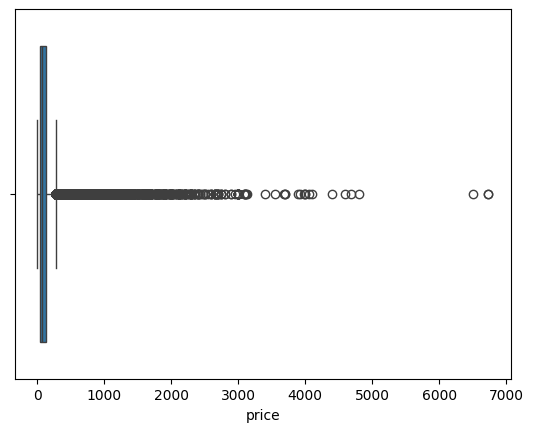

In [ ]:
sns.boxplot(x=order_items['price'])

In [ ]:
order_items[order_items['price']<0]

,order_id,order_item_id,product_id,seller_id,shipping_limit_date,price,freight_value


In [ ]:
order_items[order_items['price']==0]

,order_id,order_item_id,product_id,seller_id,shipping_limit_date,price,freight_value


In [ ]:
#Suppression des colonnes inutiles
order_items = order_items.drop(['shipping_limit_date'],axis=1)
order_items

,order_id,order_item_id,product_id,seller_id,price,freight_value
0,00010242fe8c5a6d1ba2dd792cb16214,1,4244733e06e7ecb4970a6e2683c13e61,48436dade18ac8b2bce089ec2a041202,58.90,13.29
1,00018f77f2f0320c557190d7a144bdd3,1,e5f2d52b802189ee658865ca93d83a8f,dd7ddc04e1b6c2c614352b383efe2d36,239.90,19.93
2,000229ec398224ef6ca0657da4fc703e,1,c777355d18b72b67abbeef9df44fd0fd,5b51032eddd242adc84c38acab88f23d,199.00,17.87
3,00024acbcdf0a6daa1e931b038114c75,1,7634da152a4610f1595efa32f14722fc,9d7a1d34a5052409006425275ba1c2b4,12.99,12.79
4,00042b26cf59d7ce69dfabb4e55b4fd9,1,ac6c3623068f30de03045865e4e10089,df560393f3a51e74553ab94004ba5c87,199.90,18.14
...,...,...,...,...,...,...
112645,fffc94f6ce00a00581880bf54a75a037,1,4aa6014eceb682077f9dc4bffebc05b0,b8bc237ba3788b23da09c0f1f3a3288c,299.99,43.41
112646,fffcd46ef2263f404302a634eb57f7eb,1,32e07fd915822b0765e448c4dd74c828,f3c38ab652836d21de61fb8314b69182,350.00,36.53
112647,fffce4705a9662cd70adb13d4a31832d,1,72a30483855e2eafc67aee5dc2560482,c3cfdc648177fdbbbb35635a37472c53,99.90,16.95
112648,fffe18544ffabc95dfada21779c9644f,1,9c422a519119dcad7575db5af1ba540e,2b3e4a2a3ea8e01938cabda2a3e5cc79,55.99,8.72


### <span style='color:purple'> 4-"ORDER_PAYMENTS"</span>

In [ ]:
print(f"Nombre de lignes: {order_payments.shape[0]}")
print(f"Nombre de colonnes: {order_payments.shape[1]}")
print("5 premières observations")
display(order_payments.head(5))

Nombre de lignes: 103886
Nombre de colonnes: 5
5 premières observations


,order_id,payment_sequential,payment_type,payment_installments,payment_value
0,b81ef226f3fe1789b1e8b2acac839d17,1,credit_card,8,99.33
1,a9810da82917af2d9aefd1278f1dcfa0,1,credit_card,1,24.39
2,25e8ea4e93396b6fa0d3dd708e76c1bd,1,credit_card,1,65.71
3,ba78997921bbcdc1373bb41e913ab953,1,credit_card,8,107.78
4,42fdf880ba16b47b59251dd489d4441a,1,credit_card,2,128.45


In [ ]:
order_payments.describe(include='all')

,order_id,payment_sequential,payment_type,payment_installments,payment_value
count,103886,103886.000000,103886,103886.000000,103886.000000
unique,99440,NaN,5,NaN,NaN
top,fa65dad1b0e818e3ccc5cb0e39231352,NaN,credit_card,NaN,NaN
freq,29,NaN,76795,NaN,NaN
mean,NaN,1.092679,NaN,2.853349,154.100380
std,NaN,0.706584,NaN,2.687051,217.494064
min,NaN,1.000000,NaN,0.000000,0.000000
25%,NaN,1.000000,NaN,1.000000,56.790000
50%,NaN,1.000000,NaN,1.000000,100.000000
75%,NaN,1.000000,NaN,4.000000,171.837500


In [ ]:
order_payments['payment_type'].value_counts()

,count
payment_type,
credit_card,76795
boleto,19784
voucher,5775
debit_card,1529
not_defined,3


In [ ]:
order_payments.isnull().sum()

,0
order_id,0
payment_sequential,0
payment_type,0
payment_installments,0
payment_value,0


In [ ]:
order_payments_not_defined=order_payments[order_payments['payment_type']=='not_defined']
order_payments_not_defined

,order_id,payment_sequential,payment_type,payment_installments,payment_value
51280,4637ca194b6387e2d538dc89b124b0ee,1,not_defined,1,0.0
57411,00b1cb0320190ca0daa2c88b35206009,1,not_defined,1,0.0
94427,c8c528189310eaa44a745b8d9d26908b,1,not_defined,1,0.0


In [ ]:
order_payments[order_payments['payment_value']<0]

,order_id,payment_sequential,payment_type,payment_installments,payment_value


In [ ]:
order_payments[order_payments['payment_value']==0]

,order_id,payment_sequential,payment_type,payment_installments,payment_value
19922,8bcbe01d44d147f901cd3192671144db,4,voucher,1,0.0
36822,fa65dad1b0e818e3ccc5cb0e39231352,14,voucher,1,0.0
43744,6ccb433e00daae1283ccc956189c82ae,4,voucher,1,0.0
51280,4637ca194b6387e2d538dc89b124b0ee,1,not_defined,1,0.0
57411,00b1cb0320190ca0daa2c88b35206009,1,not_defined,1,0.0
62674,45ed6e85398a87c253db47c2d9f48216,3,voucher,1,0.0
77885,fa65dad1b0e818e3ccc5cb0e39231352,13,voucher,1,0.0
94427,c8c528189310eaa44a745b8d9d26908b,1,not_defined,1,0.0
100766,b23878b3e8eb4d25a158f57d96331b18,4,voucher,1,0.0


In [ ]:
order_payments.drop(order_payments[(order_payments['payment_value'] == 0) | (order_payments['payment_type'] == 'not_defined')].index, inplace=True)
order_payments

,order_id,payment_sequential,payment_type,payment_installments,payment_value
0,b81ef226f3fe1789b1e8b2acac839d17,1,credit_card,8,99.33
1,a9810da82917af2d9aefd1278f1dcfa0,1,credit_card,1,24.39
2,25e8ea4e93396b6fa0d3dd708e76c1bd,1,credit_card,1,65.71
3,ba78997921bbcdc1373bb41e913ab953,1,credit_card,8,107.78
4,42fdf880ba16b47b59251dd489d4441a,1,credit_card,2,128.45
...,...,...,...,...,...
103881,0406037ad97740d563a178ecc7a2075c,1,boleto,1,363.31
103882,7b905861d7c825891d6347454ea7863f,1,credit_card,2,96.80
103883,32609bbb3dd69b3c066a6860554a77bf,1,credit_card,1,47.77
103884,b8b61059626efa996a60be9bb9320e10,1,credit_card,5,369.54


### <span style='color:purple'> 5- "ORDER_REVIEWS"  </span>

In [ ]:
print(f"Nombre de lignes: {order_reviews.shape[0]}")
print(f"Nombre de colonnes: {order_reviews.shape[1]}")
print("5 premières observations")
display(order_reviews.head(5))

Nombre de lignes: 99224
Nombre de colonnes: 7
5 premières observations


,review_id,order_id,review_score,review_comment_title,review_comment_message,review_creation_date,review_answer_timestamp
0,7bc2406110b926393aa56f80a40eba40,73fc7af87114b39712e6da79b0a377eb,4,NaN,NaN,2018-01-18 00:00:00,2018-01-18 21:46:59
1,80e641a11e56f04c1ad469d5645fdfde,a548910a1c6147796b98fdf73dbeba33,5,NaN,NaN,2018-03-10 00:00:00,2018-03-11 03:05:13
2,228ce5500dc1d8e020d8d1322874b6f0,f9e4b658b201a9f2ecdecbb34bed034b,5,NaN,NaN,2018-02-17 00:00:00,2018-02-18 14:36:24
3,e64fb393e7b32834bb789ff8bb30750e,658677c97b385a9be170737859d3511b,5,NaN,Recebi bem antes do prazo estipulado.,2017-04-21 00:00:00,2017-04-21 22:02:06
4,f7c4243c7fe1938f181bec41a392bdeb,8e6bfb81e283fa7e4f11123a3fb894f1,5,NaN,Parabéns lojas lannister adorei comprar pela I...,2018-03-01 00:00:00,2018-03-02 10:26:53


In [ ]:
order_reviews.describe(include='all')

,review_id,order_id,review_score,review_comment_title,review_comment_message,review_creation_date,review_answer_timestamp
count,99224,99224,99224.000000,11568,40977,99224,99224
unique,98410,98673,NaN,4527,36159,636,98248
top,4548534449b1f572e357211b90724f1b,03c939fd7fd3b38f8485a0f95798f1f6,NaN,Recomendo,Muito bom,2017-12-19 00:00:00,2017-06-15 23:21:05
freq,3,3,NaN,423,230,463,4
mean,NaN,NaN,4.086421,NaN,NaN,NaN,NaN
std,NaN,NaN,1.347579,NaN,NaN,NaN,NaN
min,NaN,NaN,1.000000,NaN,NaN,NaN,NaN
25%,NaN,NaN,4.000000,NaN,NaN,NaN,NaN
50%,NaN,NaN,5.000000,NaN,NaN,NaN,NaN
75%,NaN,NaN,5.000000,NaN,NaN,NaN,NaN


In [ ]:
order_reviews.isnull().sum()

,0
review_id,0
order_id,0
review_score,0
review_comment_title,87656
review_comment_message,58247
review_creation_date,0
review_answer_timestamp,0


In [ ]:
order_reviews['review_score'].value_counts()

,count
review_score,
5,57328
4,19142
1,11424
3,8179
2,3151


In [ ]:
#Suppression des colonnes inutiles
order_reviews = order_reviews.drop(['review_answer_timestamp', 'review_creation_date','review_comment_message', 'review_comment_title'],axis=1)
order_reviews

,review_id,order_id,review_score
0,7bc2406110b926393aa56f80a40eba40,73fc7af87114b39712e6da79b0a377eb,4
1,80e641a11e56f04c1ad469d5645fdfde,a548910a1c6147796b98fdf73dbeba33,5
2,228ce5500dc1d8e020d8d1322874b6f0,f9e4b658b201a9f2ecdecbb34bed034b,5
3,e64fb393e7b32834bb789ff8bb30750e,658677c97b385a9be170737859d3511b,5
4,f7c4243c7fe1938f181bec41a392bdeb,8e6bfb81e283fa7e4f11123a3fb894f1,5
...,...,...,...
99219,574ed12dd733e5fa530cfd4bbf39d7c9,2a8c23fee101d4d5662fa670396eb8da,5
99220,f3897127253a9592a73be9bdfdf4ed7a,22ec9f0669f784db00fa86d035cf8602,5
99221,b3de70c89b1510c4cd3d0649fd302472,55d4004744368f5571d1f590031933e4,5
99222,1adeb9d84d72fe4e337617733eb85149,7725825d039fc1f0ceb7635e3f7d9206,4


In [ ]:
print(order_reviews[order_reviews['review_score']>5])
print(order_reviews[order_reviews['review_score']<0])

Empty DataFrame
Columns: [review_id, order_id, review_score]
Index: []
Empty DataFrame
Columns: [review_id, order_id, review_score]
Index: []


### <span style='color:purple'> 6-"ORDER"</span>

In [ ]:
print(f"Nombre de lignes: {order.shape[0]}")
print(f"Nombre de colonnes: {order.shape[1]}")
print("5 premières observations")
display(order.head(5))

Nombre de lignes: 99441
Nombre de colonnes: 8
5 premières observations


,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18 00:00:00
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13 00:00:00
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04 00:00:00
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,delivered,2017-11-18 19:28:06,2017-11-18 19:45:59,2017-11-22 13:39:59,2017-12-02 00:28:42,2017-12-15 00:00:00
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,delivered,2018-02-13 21:18:39,2018-02-13 22:20:29,2018-02-14 19:46:34,2018-02-16 18:17:02,2018-02-26 00:00:00


In [ ]:
order.describe(include='all')

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date
count,99441,99441,99441,99441,99281,97658,96476,99441
unique,99441,99441,8,98875,90733,81018,95664,459
top,66dea50a8b16d9b4dee7af250b4be1a5,edb027a75a1449115f6b43211ae02a24,delivered,2018-08-02 12:06:07,2018-02-27 04:31:10,2018-05-09 15:48:00,2018-05-14 20:02:44,2017-12-20 00:00:00
freq,1,1,96478,3,9,47,3,522


In [ ]:
order.isnull().sum()

,0
order_id,0
customer_id,0
order_status,0
order_purchase_timestamp,0
order_approved_at,160
order_delivered_carrier_date,1783
order_delivered_customer_date,2965
order_estimated_delivery_date,0


In [ ]:
#Suppression des colonnes inutiles
order = order.drop(['order_approved_at','order_delivered_carrier_date','order_delivered_customer_date','order_estimated_delivery_date'],axis=1)
order

,order_id,customer_id,order_status,order_purchase_timestamp
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,delivered,2017-11-18 19:28:06
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,delivered,2018-02-13 21:18:39
...,...,...,...,...
99436,9c5dedf39a927c1b2549525ed64a053c,39bd1228ee8140590ac3aca26f2dfe00,delivered,2017-03-09 09:54:05
99437,63943bddc261676b46f01ca7ac2f7bd8,1fca14ff2861355f6e5f14306ff977a7,delivered,2018-02-06 12:58:58
99438,83c1379a015df1e13d02aae0204711ab,1aa71eb042121263aafbe80c1b562c9c,delivered,2017-08-27 14:46:43
99439,11c177c8e97725db2631073c19f07b62,b331b74b18dc79bcdf6532d51e1637c1,delivered,2018-01-08 21:28:27


In [ ]:
order['order_date'] = pd.to_datetime(order['order_purchase_timestamp']).dt.date

In [ ]:
order['time'] = pd.to_datetime(order['order_purchase_timestamp']).dt.time
order['years'] = pd.to_datetime(order['order_purchase_timestamp']).dt.year
order['month'] = pd.to_datetime(order['order_purchase_timestamp']).dt.month
order['month_year']=pd.to_datetime(order['order_purchase_timestamp']).dt.strftime("%m-%Y")
order['day']=pd.to_datetime(order['order_purchase_timestamp']).dt.day

In [ ]:
order['order_status'].value_counts()

,count
order_status,
delivered,96478
shipped,1107
canceled,625
unavailable,609
invoiced,314
processing,301
created,5
approved,2


### <span style='color:purple'> 7-"PROD" </span>

In [ ]:
print(f"Nombre de lignes: {prod.shape[0]}")
print(f"Nombre de colonnes: {prod.shape[1]}")
print("5 premières observations")
display(prod.head(5))

Nombre de lignes: 32951
Nombre de colonnes: 9
5 premières observations


,product_id,product_category_name,product_name_lenght,product_description_lenght,product_photos_qty,product_weight_g,product_length_cm,product_height_cm,product_width_cm
0,1e9e8ef04dbcff4541ed26657ea517e5,perfumaria,40.0,287.0,1.0,225.0,16.0,10.0,14.0
1,3aa071139cb16b67ca9e5dea641aaa2f,artes,44.0,276.0,1.0,1000.0,30.0,18.0,20.0
2,96bd76ec8810374ed1b65e291975717f,esporte_lazer,46.0,250.0,1.0,154.0,18.0,9.0,15.0
3,cef67bcfe19066a932b7673e239eb23d,bebes,27.0,261.0,1.0,371.0,26.0,4.0,26.0
4,9dc1a7de274444849c219cff195d0b71,utilidades_domesticas,37.0,402.0,4.0,625.0,20.0,17.0,13.0


In [ ]:
prod.describe(include='all')

,product_id,product_category_name,product_name_lenght,product_description_lenght,product_photos_qty,product_weight_g,product_length_cm,product_height_cm,product_width_cm
count,32951,32341,32341.000000,32341.000000,32341.000000,32949.000000,32949.000000,32949.000000,32949.000000
unique,32951,73,NaN,NaN,NaN,NaN,NaN,NaN,NaN
top,106392145fca363410d287a815be6de4,cama_mesa_banho,NaN,NaN,NaN,NaN,NaN,NaN,NaN
freq,1,3029,NaN,NaN,NaN,NaN,NaN,NaN,NaN
mean,NaN,NaN,48.476949,771.495285,2.188986,2276.472488,30.815078,16.937661,23.196728
std,NaN,NaN,10.245741,635.115225,1.736766,4282.038731,16.914458,13.637554,12.079047
min,NaN,NaN,5.000000,4.000000,1.000000,0.000000,7.000000,2.000000,6.000000
25%,NaN,NaN,42.000000,339.000000,1.000000,300.000000,18.000000,8.000000,15.000000
50%,NaN,NaN,51.000000,595.000000,1.000000,700.000000,25.000000,13.000000,20.000000
75%,NaN,NaN,57.000000,972.000000,3.000000,1900.000000,38.000000,21.000000,30.000000


In [ ]:
prod['product_category_name'].tolist()

['perfumaria',
 'artes',
 'esporte_lazer',
 'bebes',
 'utilidades_domesticas',
 'instrumentos_musicais',
 'cool_stuff',
 'moveis_decoracao',
 'eletrodomesticos',
 'brinquedos',
 'cama_mesa_banho',
 'bebes',
 'instrumentos_musicais',
 'moveis_decoracao',
 'construcao_ferramentas_seguranca',
 'esporte_lazer',
 'perfumaria',
 'informatica_acessorios',
 'moveis_decoracao',
 'cama_mesa_banho',
 'moveis_decoracao',
 'cama_mesa_banho',
 'beleza_saude',
 'bebes',
 'moveis_decoracao',
 'utilidades_domesticas',
 'malas_acessorios',
 'informatica_acessorios',
 'informatica_acessorios',
 'esporte_lazer',
 'cama_mesa_banho',
 'ferramentas_jardim',
 'moveis_decoracao',
 'moveis_escritorio',
 'esporte_lazer',
 'bebes',
 'automotivo',
 'eletronicos',
 'utilidades_domesticas',
 'moveis_decoracao',
 'moveis_decoracao',
 'brinquedos',
 'cama_mesa_banho',
 'bebes',
 'cool_stuff',
 'brinquedos',
 'cool_stuff',
 'moveis_decoracao',
 'moveis_decoracao',
 'beleza_saude',
 'esporte_lazer',
 'cool_stuff',
 'aut

In [ ]:
prod.isnull().sum()

,0
product_id,0
product_category_name,610
product_name_lenght,610
product_description_lenght,610
product_photos_qty,610
product_weight_g,2
product_length_cm,2
product_height_cm,2
product_width_cm,2


In [ ]:
#Suppression des colonnes inutiles
prod = prod.drop(['product_name_lenght',
'product_description_lenght',
'product_photos_qty',
'product_weight_g',
'product_length_cm',
'product_height_cm',
'product_width_cm' ],axis=1)
prod

,product_id,product_category_name
0,1e9e8ef04dbcff4541ed26657ea517e5,perfumaria
1,3aa071139cb16b67ca9e5dea641aaa2f,artes
2,96bd76ec8810374ed1b65e291975717f,esporte_lazer
3,cef67bcfe19066a932b7673e239eb23d,bebes
4,9dc1a7de274444849c219cff195d0b71,utilidades_domesticas
...,...,...
32946,a0b7d5a992ccda646f2d34e418fff5a0,moveis_decoracao
32947,bf4538d88321d0fd4412a93c974510e6,construcao_ferramentas_iluminacao
32948,9a7c6041fa9592d9d9ef6cfe62a71f8c,cama_mesa_banho
32949,83808703fc0706a22e264b9d75f04a2e,informatica_acessorios


In [ ]:
prod.isnull().sum()

,0
product_id,0
product_category_name,610


In [ ]:
prod = prod.copy()
prod['product_category_name'] = prod['product_category_name'].fillna('not_defined')

In [ ]:
print(f"Nombre de lignes: {prod.shape[0]}")
print(f"Nombre de colonnes: {prod.shape[1]}")

Nombre de lignes: 32951
Nombre de colonnes: 2


In [ ]:
product_counts = prod['product_category_name'].value_counts()
product_list = prod['product_category_name'].unique().tolist()

In [ ]:
product_list

['perfumaria',
 'artes',
 'esporte_lazer',
 'bebes',
 'utilidades_domesticas',
 'instrumentos_musicais',
 'cool_stuff',
 'moveis_decoracao',
 'eletrodomesticos',
 'brinquedos',
 'cama_mesa_banho',
 'construcao_ferramentas_seguranca',
 'informatica_acessorios',
 'beleza_saude',
 'malas_acessorios',
 'ferramentas_jardim',
 'moveis_escritorio',
 'automotivo',
 'eletronicos',
 'fashion_calcados',
 'telefonia',
 'papelaria',
 'fashion_bolsas_e_acessorios',
 'pcs',
 'casa_construcao',
 'relogios_presentes',
 'construcao_ferramentas_construcao',
 'pet_shop',
 'eletroportateis',
 'agro_industria_e_comercio',
 'not_defined',
 'moveis_sala',
 'sinalizacao_e_seguranca',
 'climatizacao',
 'consoles_games',
 'livros_interesse_geral',
 'construcao_ferramentas_ferramentas',
 'fashion_underwear_e_moda_praia',
 'fashion_roupa_masculina',
 'moveis_cozinha_area_de_servico_jantar_e_jardim',
 'industria_comercio_e_negocios',
 'telefonia_fixa',
 'construcao_ferramentas_iluminacao',
 'livros_tecnicos',
 'ele

In [ ]:
traduction_categories = {
    'moveis_escritorio': 'Maison',
    'utilidades_domesticas': 'Maison',
    'casa_conforto': 'Maison',
    'casa_conforto_2': 'Maison',
    'esporte_lazer': 'Sport & Loisirs',
    'informatica_acessorios': 'Informatique & Électronique',
    'not_defined': 'Autres',
    'brinquedos': 'Jouets',
    'moveis_decoracao': 'Maison',
    'automotivo': 'Auto & Moto',
    'climatizacao': 'Maison',
    'telefonia': 'Téléphonie',
    'beleza_saude': 'Beauté & Santé',
    'ferramentas_jardim': 'Bricolage & Jardin',
    'pet_shop': 'Animaux',
    'bebes': 'Bébés',
    'cama_mesa_banho': 'Maison',
    'relogios_presentes': 'Cadeaux & Montres',
    'moveis_cozinha_area_de_servico_jantar_e_jardim': 'Maison',
    'perfumaria': 'Beauté & Santé',
    'artes': 'Maison',
    'artes_e_artesanato': 'Maison',
    'papelaria': 'Papeterie',
    'fashion_roupa_feminina': 'Mode',
    'consoles_games': 'Multimédias',
    'construcao_ferramentas_iluminacao': 'Bricolage & Jardin',
    'alimentos_bebidas': 'Alimentation & Boissons',
    'bebidas': 'Alimentation & Boissons',
    'cool_stuff': 'Gadgets',
    'fashion_bolsas_e_acessorios': 'Mode',
    'casa_construcao': 'Bricolage & Jardin',
    'malas_acessorios': 'Mode',
    'eletronicos': 'Informatique & Électronique',
    'eletrodomesticos_2': 'Maison',
    'fashion_roupa_masculina': 'Mode',
    'eletroportateis': 'Maison',
    'portateis_casa_forno_e_cafe': 'Maison',
    'livros_interesse_geral': 'Multimédias',
    'livros_importados': 'Multimédias',
    'livros_tecnicos': 'Multimédias',
    'eletrodomesticos': 'Maison',
    'construcao_ferramentas_ferramentas': 'Bricolage & Jardin',
    'sinalizacao_e_seguranca': 'Bricolage & Jardin',
    'instrumentos_musicais': 'Multimédias',
    'construcao_ferramentas_construcao': 'Bricolage & Jardin',
    'musica': 'Multimédias',
    'fashion_calcados': 'Mode',
    'industria_comercio_e_negocios': 'Professionnel',
    'fashion_underwear_e_moda_praia': 'Mode',
    'dvds_blu_ray': 'Multimédias',
    'construcao_ferramentas_seguranca': 'Bricolage & Jardin',
    'alimentos': 'Alimentation & Boissons',
    'telefonia_fixa': 'Téléphonie',
    'moveis_sala': 'Maison',
    'moveis_quarto': 'Maison',
    'moveis_colchao_e_estofado': 'Maison',
    'tablets_impressao_imagem': 'Informatique & Électronique',
    'market_place': 'Autres',
    'artigos_de_natal': 'Maison',
    'agro_industria_e_comercio': 'Professionnel',
    'construcao_ferramentas_jardim': 'Bricolage & Jardin',
    'pcs': 'Informatique & Électronique',
    'audio': 'Informatique & Électronique',
    'artigos_de_festas': 'Fêtes & Événements',
    'portateis_cozinha_e_preparadores_de_alimentos': 'Maison',
    'pc_gamer': 'Informatique & Électronique',
    'la_cuisine': 'Maison',
    'flores': 'Maison',
    'fraldas_higiene': 'Bébés',
    'cine_foto': 'Multimédias',
    'cds_dvds_musicais': 'Multimédias',
    'fashion_esporte': 'Mode',
    'fashion_roupa_infanto_juvenil': 'Mode',
    'seguros_e_servicos': 'Services',
    'nan': 'Autres'
}

In [ ]:
prod['product_category_name'] = prod['product_category_name'].map(traduction_categories).fillna('Autres')


In [ ]:
print(prod['product_category_name'].value_counts())


product_category_name
Maison                         9770
Beauté & Santé                 3312
Sport & Loisirs                2867
Informatique & Électronique    2256
Auto & Moto                    1900
Bricolage & Jardin             1767
Mode                           1570
Jouets                         1411
Cadeaux & Montres              1329
Téléphonie                     1250
Multimédias                    1080
Bébés                           931
Papeterie                       849
Gadgets                         789
Animaux                         719
Autres                          714
Alimentation & Boissons         267
Professionnel                   142
Fêtes & Événements               26
Services                          2
Name: count, dtype: int64


In [ ]:
categories_non_traduites = set(prod['product_category_name']) - set(traduction_categories.keys())
print(categories_non_traduites)


{'Papeterie', 'Professionnel', 'Maison', 'Beauté & Santé', 'Alimentation & Boissons', 'Bébés', 'Mode', 'Multimédias', 'Gadgets', 'Cadeaux & Montres', 'Autres', 'Bricolage & Jardin', 'Sport & Loisirs', 'Services', 'Informatique & Électronique', 'Fêtes & Événements', 'Jouets', 'Animaux', 'Téléphonie', 'Auto & Moto'}


In [ ]:
prod

,product_id,product_category_name
0,1e9e8ef04dbcff4541ed26657ea517e5,Beauté & Santé
1,3aa071139cb16b67ca9e5dea641aaa2f,Maison
2,96bd76ec8810374ed1b65e291975717f,Sport & Loisirs
3,cef67bcfe19066a932b7673e239eb23d,Bébés
4,9dc1a7de274444849c219cff195d0b71,Maison
...,...,...
32946,a0b7d5a992ccda646f2d34e418fff5a0,Maison
32947,bf4538d88321d0fd4412a93c974510e6,Bricolage & Jardin
32948,9a7c6041fa9592d9d9ef6cfe62a71f8c,Maison
32949,83808703fc0706a22e264b9d75f04a2e,Informatique & Électronique


### <span style='color:red'> 8-"SEL" </span>

In [ ]:
print(f"Nombre de lignes: {sel.shape[0]}")
print(f"Nombre de colonnes: {sel.shape[1]}")
print("5 premières observations")
display(sel.head(5))

Nombre de lignes: 3095
Nombre de colonnes: 4
5 premières observations


,seller_id,seller_zip_code_prefix,seller_city,seller_state
0,3442f8959a84dea7ee197c632cb2df15,13023,campinas,SP
1,d1b65fc7debc3361ea86b5f14c68d2e2,13844,mogi guacu,SP
2,ce3ad9de960102d0677a81f5d0bb7b2d,20031,rio de janeiro,RJ
3,c0f3eea2e14555b6faeea3dd58c1b1c3,4195,sao paulo,SP
4,51a04a8a6bdcb23deccc82b0b80742cf,12914,braganca paulista,SP


In [ ]:
sel["seller_zip_code_prefix"] = sel["seller_zip_code_prefix"].astype(object)

In [ ]:
sel.describe(include='all')

,seller_id,seller_zip_code_prefix,seller_city,seller_state
count,3095,3095,3095,3095
unique,3095,2246,611,23
top,9e25199f6ef7e7c347120ff175652c3b,14940,sao paulo,SP
freq,1,49,694,1849


### <span style='color:purple'> 9-"CAT" </span>

In [ ]:
# The issue with the provided code is the incorrect placement of the `except FileNotFoundError:` condition.
# It appears that the intent was to catch an exception, but this code does not contain a valid try-except block.

# Fixed Code
try:
    print(f"Nombre de lignes: {cat.shape[0]}")
    print(f"Nombre de colonnes: {cat.shape[1]}")
    print("5 premières observations")
    display(cat.head(5))
except FileNotFoundError:
    print(f"Error: The file {file_path} was not found. Please make sure the file is in the directory.")

Nombre de lignes: 71
Nombre de colonnes: 2
5 premières observations


,product_category_name,product_category_name_english
0,beleza_saude,health_beauty
1,informatica_acessorios,computers_accessories
2,automotivo,auto
3,cama_mesa_banho,bed_bath_table
4,moveis_decoracao,furniture_decor


In [ ]:
product_category_counts = cat['product_category_name'].value_counts()
product_category_list = cat['product_category_name'].unique().tolist()
product_category_list

['beleza_saude',
 'informatica_acessorios',
 'automotivo',
 'cama_mesa_banho',
 'moveis_decoracao',
 'esporte_lazer',
 'perfumaria',
 'utilidades_domesticas',
 'telefonia',
 'relogios_presentes',
 'alimentos_bebidas',
 'bebes',
 'papelaria',
 'tablets_impressao_imagem',
 'brinquedos',
 'telefonia_fixa',
 'ferramentas_jardim',
 'fashion_bolsas_e_acessorios',
 'eletroportateis',
 'consoles_games',
 'audio',
 'fashion_calcados',
 'cool_stuff',
 'malas_acessorios',
 'climatizacao',
 'construcao_ferramentas_construcao',
 'moveis_cozinha_area_de_servico_jantar_e_jardim',
 'construcao_ferramentas_jardim',
 'fashion_roupa_masculina',
 'pet_shop',
 'moveis_escritorio',
 'market_place',
 'eletronicos',
 'eletrodomesticos',
 'artigos_de_festas',
 'casa_conforto',
 'construcao_ferramentas_ferramentas',
 'agro_industria_e_comercio',
 'moveis_colchao_e_estofado',
 'livros_tecnicos',
 'casa_construcao',
 'instrumentos_musicais',
 'moveis_sala',
 'construcao_ferramentas_iluminacao',
 'industria_comerc

## II- CONSTITUTION DU DATASET

Le df "sel" ne sera pas gardé dans cette étape. Les fichiers seront mergés comme suit :


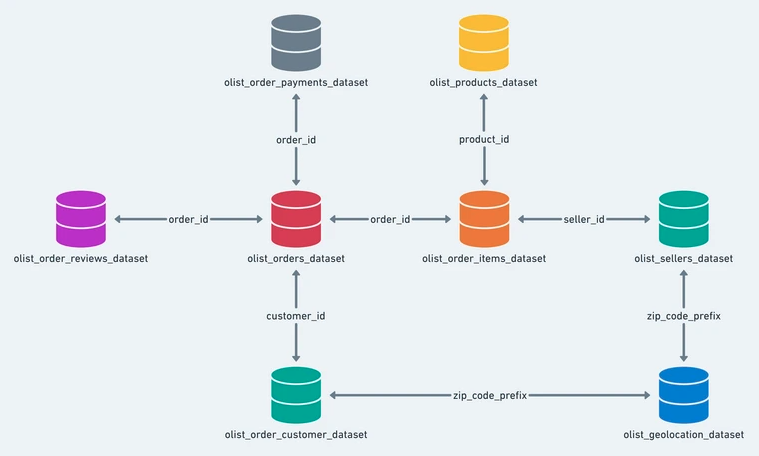

In [ ]:
from IPython.display import Image
# Update the path as per the file available in the file system
Image(filename='/content/drive/MyDrive/Colab Notebooks/P5_V2_andrea_nebot/merge.png', width=700, height=400)

### PROD + CAT

In [ ]:
# The error indicates that the column 'product_category_name' is missing in one or both DataFrames 'prod' and 'cat'.
# Let's verify the column names in both DataFrames.

print("Columns in prod:", prod.columns)
print("Columns in cat:", cat.columns)

Columns in prod: Index(['product_id', 'product_category_name'], dtype='object')
Columns in cat: Index(['product_category_name', 'product_category_name_english'], dtype='object')


In [ ]:
prod_cat= pd.merge(prod, cat, on='product_category_name', how='left', indicator=True)
prod_cat

,product_id,product_category_name,product_category_name_english,_merge
0,1e9e8ef04dbcff4541ed26657ea517e5,Beauté & Santé,NaN,left_only
1,3aa071139cb16b67ca9e5dea641aaa2f,Maison,NaN,left_only
2,96bd76ec8810374ed1b65e291975717f,Sport & Loisirs,NaN,left_only
3,cef67bcfe19066a932b7673e239eb23d,Bébés,NaN,left_only
4,9dc1a7de274444849c219cff195d0b71,Maison,NaN,left_only
...,...,...,...,...
32946,a0b7d5a992ccda646f2d34e418fff5a0,Maison,NaN,left_only
32947,bf4538d88321d0fd4412a93c974510e6,Bricolage & Jardin,NaN,left_only
32948,9a7c6041fa9592d9d9ef6cfe62a71f8c,Maison,NaN,left_only
32949,83808703fc0706a22e264b9d75f04a2e,Informatique & Électronique,NaN,left_only


In [ ]:
prod_cat['_merge'].unique()

['left_only']
Categories (3, object): ['left_only', 'right_only', 'both']

In [ ]:
pc=prod_cat.loc[prod_cat['_merge']=='left_only']
pc

,product_id,product_category_name,product_category_name_english,_merge
0,1e9e8ef04dbcff4541ed26657ea517e5,Beauté & Santé,NaN,left_only
1,3aa071139cb16b67ca9e5dea641aaa2f,Maison,NaN,left_only
2,96bd76ec8810374ed1b65e291975717f,Sport & Loisirs,NaN,left_only
3,cef67bcfe19066a932b7673e239eb23d,Bébés,NaN,left_only
4,9dc1a7de274444849c219cff195d0b71,Maison,NaN,left_only
...,...,...,...,...
32946,a0b7d5a992ccda646f2d34e418fff5a0,Maison,NaN,left_only
32947,bf4538d88321d0fd4412a93c974510e6,Bricolage & Jardin,NaN,left_only
32948,9a7c6041fa9592d9d9ef6cfe62a71f8c,Maison,NaN,left_only
32949,83808703fc0706a22e264b9d75f04a2e,Informatique & Électronique,NaN,left_only


In [ ]:
pc2=prod_cat.loc[prod_cat['_merge']=='right_only']
pc2

,product_id,product_category_name,product_category_name_english,_merge


In [ ]:
#prod_cat=prod_cat.loc[prod_cat['_merge']=='both']
prod_cat

,product_id,product_category_name,product_category_name_english,_merge
0,1e9e8ef04dbcff4541ed26657ea517e5,Beauté & Santé,NaN,left_only
1,3aa071139cb16b67ca9e5dea641aaa2f,Maison,NaN,left_only
2,96bd76ec8810374ed1b65e291975717f,Sport & Loisirs,NaN,left_only
3,cef67bcfe19066a932b7673e239eb23d,Bébés,NaN,left_only
4,9dc1a7de274444849c219cff195d0b71,Maison,NaN,left_only
...,...,...,...,...
32946,a0b7d5a992ccda646f2d34e418fff5a0,Maison,NaN,left_only
32947,bf4538d88321d0fd4412a93c974510e6,Bricolage & Jardin,NaN,left_only
32948,9a7c6041fa9592d9d9ef6cfe62a71f8c,Maison,NaN,left_only
32949,83808703fc0706a22e264b9d75f04a2e,Informatique & Électronique,NaN,left_only


In [ ]:
prod_cat.describe(include='all')

,product_id,product_category_name,product_category_name_english,_merge
count,32951,32951,0,32951
unique,32951,20,0,1
top,106392145fca363410d287a815be6de4,Maison,NaN,left_only
freq,1,9770,NaN,32951


In [ ]:
prod_cat.isnull().sum()

,0
product_id,0
product_category_name,0
product_category_name_english,32951
_merge,0


In [ ]:
prod_cat.drop(columns=['_merge','product_category_name_english'], inplace=True)
prod_cat.head()

,product_id,product_category_name
0,1e9e8ef04dbcff4541ed26657ea517e5,Beauté & Santé
1,3aa071139cb16b67ca9e5dea641aaa2f,Maison
2,96bd76ec8810374ed1b65e291975717f,Sport & Loisirs
3,cef67bcfe19066a932b7673e239eb23d,Bébés
4,9dc1a7de274444849c219cff195d0b71,Maison


### CLIENT + ORDER

In [ ]:
client_order= pd.merge(cust, order, on='customer_id', how='left', indicator=True)
client_order

,customer_id,customer_unique_id,zip_code,city,state,order_id,order_status,order_purchase_timestamp,order_date,time,years,month,month_year,day,_merge
0,06b8999e2fba1a1fbc88172c00ba8bc7,861eff4711a542e4b93843c6dd7febb0,14409,franca,São Paulo,00e7ee1b050b8499577073aeb2a297a1,delivered,2017-05-16 15:05:35,2017-05-16,15:05:35,2017,5,05-2017,16,both
1,18955e83d337fd6b2def6b18a428ac77,290c77bc529b7ac935b93aa66c333dc3,9790,sao bernardo do campo,São Paulo,29150127e6685892b6eab3eec79f59c7,delivered,2018-01-12 20:48:24,2018-01-12,20:48:24,2018,1,01-2018,12,both
2,4e7b3e00288586ebd08712fdd0374a03,060e732b5b29e8181a18229c7b0b2b5e,1151,sao paulo,São Paulo,b2059ed67ce144a36e2aa97d2c9e9ad2,delivered,2018-05-19 16:07:45,2018-05-19,16:07:45,2018,5,05-2018,19,both
3,b2b6027bc5c5109e529d4dc6358b12c3,259dac757896d24d7702b9acbbff3f3c,8775,mogi das cruzes,São Paulo,951670f92359f4fe4a63112aa7306eba,delivered,2018-03-13 16:06:38,2018-03-13,16:06:38,2018,3,03-2018,13,both
4,4f2d8ab171c80ec8364f7c12e35b23ad,345ecd01c38d18a9036ed96c73b8d066,13056,campinas,São Paulo,6b7d50bd145f6fc7f33cebabd7e49d0f,delivered,2018-07-29 09:51:30,2018-07-29,09:51:30,2018,7,07-2018,29,both
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
99436,17ddf5dd5d51696bb3d7c6291687be6f,1a29b476fee25c95fbafc67c5ac95cf8,3937,sao paulo,São Paulo,6760e20addcf0121e9d58f2f1ff14298,delivered,2018-04-07 15:48:17,2018-04-07,15:48:17,2018,4,04-2018,7,both
99437,e7b71a9017aa05c9a7fd292d714858e8,d52a67c98be1cf6a5c84435bd38d095d,6764,taboao da serra,São Paulo,9ec0c8947d973db4f4e8dcf1fbfa8f1b,delivered,2018-04-04 08:20:22,2018-04-04,08:20:22,2018,4,04-2018,4,both
99438,5e28dfe12db7fb50a4b2f691faecea5e,e9f50caf99f032f0bf3c55141f019d99,60115,fortaleza,Ceará,fed4434add09a6f332ea398efd656a5c,delivered,2018-04-08 20:11:50,2018-04-08,20:11:50,2018,4,04-2018,8,both
99439,56b18e2166679b8a959d72dd06da27f9,73c2643a0a458b49f58cea58833b192e,92120,canoas,Rio Grande do Sul,e31ec91cea1ecf97797787471f98a8c2,delivered,2017-11-03 21:08:33,2017-11-03,21:08:33,2017,11,11-2017,3,both


In [ ]:
client_order['_merge'].unique()

['both']
Categories (3, object): ['left_only', 'right_only', 'both']

In [ ]:
co=client_order.loc[client_order['_merge']=='left_only']
co

,customer_id,customer_unique_id,zip_code,city,state,order_id,order_status,order_purchase_timestamp,order_date,time,years,month,month_year,day,_merge


In [ ]:
co.isnull().sum(), co.shape

(customer_id                 0
 customer_unique_id          0
 zip_code                    0
 city                        0
 state                       0
 order_id                    0
 order_status                0
 order_purchase_timestamp    0
 order_date                  0
 time                        0
 years                       0
 month                       0
 month_year                  0
 day                         0
 _merge                      0
 dtype: int64,
 (0, 15))

In [ ]:
client_order=client_order.loc[client_order['_merge']=='both']
client_order

,customer_id,customer_unique_id,zip_code,city,state,order_id,order_status,order_purchase_timestamp,order_date,time,years,month,month_year,day,_merge
0,06b8999e2fba1a1fbc88172c00ba8bc7,861eff4711a542e4b93843c6dd7febb0,14409,franca,São Paulo,00e7ee1b050b8499577073aeb2a297a1,delivered,2017-05-16 15:05:35,2017-05-16,15:05:35,2017,5,05-2017,16,both
1,18955e83d337fd6b2def6b18a428ac77,290c77bc529b7ac935b93aa66c333dc3,9790,sao bernardo do campo,São Paulo,29150127e6685892b6eab3eec79f59c7,delivered,2018-01-12 20:48:24,2018-01-12,20:48:24,2018,1,01-2018,12,both
2,4e7b3e00288586ebd08712fdd0374a03,060e732b5b29e8181a18229c7b0b2b5e,1151,sao paulo,São Paulo,b2059ed67ce144a36e2aa97d2c9e9ad2,delivered,2018-05-19 16:07:45,2018-05-19,16:07:45,2018,5,05-2018,19,both
3,b2b6027bc5c5109e529d4dc6358b12c3,259dac757896d24d7702b9acbbff3f3c,8775,mogi das cruzes,São Paulo,951670f92359f4fe4a63112aa7306eba,delivered,2018-03-13 16:06:38,2018-03-13,16:06:38,2018,3,03-2018,13,both
4,4f2d8ab171c80ec8364f7c12e35b23ad,345ecd01c38d18a9036ed96c73b8d066,13056,campinas,São Paulo,6b7d50bd145f6fc7f33cebabd7e49d0f,delivered,2018-07-29 09:51:30,2018-07-29,09:51:30,2018,7,07-2018,29,both
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
99436,17ddf5dd5d51696bb3d7c6291687be6f,1a29b476fee25c95fbafc67c5ac95cf8,3937,sao paulo,São Paulo,6760e20addcf0121e9d58f2f1ff14298,delivered,2018-04-07 15:48:17,2018-04-07,15:48:17,2018,4,04-2018,7,both
99437,e7b71a9017aa05c9a7fd292d714858e8,d52a67c98be1cf6a5c84435bd38d095d,6764,taboao da serra,São Paulo,9ec0c8947d973db4f4e8dcf1fbfa8f1b,delivered,2018-04-04 08:20:22,2018-04-04,08:20:22,2018,4,04-2018,4,both
99438,5e28dfe12db7fb50a4b2f691faecea5e,e9f50caf99f032f0bf3c55141f019d99,60115,fortaleza,Ceará,fed4434add09a6f332ea398efd656a5c,delivered,2018-04-08 20:11:50,2018-04-08,20:11:50,2018,4,04-2018,8,both
99439,56b18e2166679b8a959d72dd06da27f9,73c2643a0a458b49f58cea58833b192e,92120,canoas,Rio Grande do Sul,e31ec91cea1ecf97797787471f98a8c2,delivered,2017-11-03 21:08:33,2017-11-03,21:08:33,2017,11,11-2017,3,both


In [ ]:
client_order.isnull().sum(), co.shape

(customer_id                 0
 customer_unique_id          0
 zip_code                    0
 city                        0
 state                       0
 order_id                    0
 order_status                0
 order_purchase_timestamp    0
 order_date                  0
 time                        0
 years                       0
 month                       0
 month_year                  0
 day                         0
 _merge                      0
 dtype: int64,
 (0, 15))

In [ ]:
client_order

,customer_id,customer_unique_id,zip_code,city,state,order_id,order_status,order_purchase_timestamp,order_date,time,years,month,month_year,day,_merge
0,06b8999e2fba1a1fbc88172c00ba8bc7,861eff4711a542e4b93843c6dd7febb0,14409,franca,São Paulo,00e7ee1b050b8499577073aeb2a297a1,delivered,2017-05-16 15:05:35,2017-05-16,15:05:35,2017,5,05-2017,16,both
1,18955e83d337fd6b2def6b18a428ac77,290c77bc529b7ac935b93aa66c333dc3,9790,sao bernardo do campo,São Paulo,29150127e6685892b6eab3eec79f59c7,delivered,2018-01-12 20:48:24,2018-01-12,20:48:24,2018,1,01-2018,12,both
2,4e7b3e00288586ebd08712fdd0374a03,060e732b5b29e8181a18229c7b0b2b5e,1151,sao paulo,São Paulo,b2059ed67ce144a36e2aa97d2c9e9ad2,delivered,2018-05-19 16:07:45,2018-05-19,16:07:45,2018,5,05-2018,19,both
3,b2b6027bc5c5109e529d4dc6358b12c3,259dac757896d24d7702b9acbbff3f3c,8775,mogi das cruzes,São Paulo,951670f92359f4fe4a63112aa7306eba,delivered,2018-03-13 16:06:38,2018-03-13,16:06:38,2018,3,03-2018,13,both
4,4f2d8ab171c80ec8364f7c12e35b23ad,345ecd01c38d18a9036ed96c73b8d066,13056,campinas,São Paulo,6b7d50bd145f6fc7f33cebabd7e49d0f,delivered,2018-07-29 09:51:30,2018-07-29,09:51:30,2018,7,07-2018,29,both
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
99436,17ddf5dd5d51696bb3d7c6291687be6f,1a29b476fee25c95fbafc67c5ac95cf8,3937,sao paulo,São Paulo,6760e20addcf0121e9d58f2f1ff14298,delivered,2018-04-07 15:48:17,2018-04-07,15:48:17,2018,4,04-2018,7,both
99437,e7b71a9017aa05c9a7fd292d714858e8,d52a67c98be1cf6a5c84435bd38d095d,6764,taboao da serra,São Paulo,9ec0c8947d973db4f4e8dcf1fbfa8f1b,delivered,2018-04-04 08:20:22,2018-04-04,08:20:22,2018,4,04-2018,4,both
99438,5e28dfe12db7fb50a4b2f691faecea5e,e9f50caf99f032f0bf3c55141f019d99,60115,fortaleza,Ceará,fed4434add09a6f332ea398efd656a5c,delivered,2018-04-08 20:11:50,2018-04-08,20:11:50,2018,4,04-2018,8,both
99439,56b18e2166679b8a959d72dd06da27f9,73c2643a0a458b49f58cea58833b192e,92120,canoas,Rio Grande do Sul,e31ec91cea1ecf97797787471f98a8c2,delivered,2017-11-03 21:08:33,2017-11-03,21:08:33,2017,11,11-2017,3,both


In [ ]:
client_order.describe(include='all')

,customer_id,customer_unique_id,zip_code,city,state,order_id,order_status,order_purchase_timestamp,order_date,time,years,month,month_year,day,_merge
count,99441,99441,99441.0,99441,99441,99441,99441,99441,99441,99441,99441.000000,99441.000000,99441,99441.000000,99441
unique,99441,96096,14994.0,4119,27,99441,8,98875,634,50818,NaN,NaN,25,NaN,1
top,274fa6071e5e17fe303b9748641082c8,8d50f5eadf50201ccdcedfb9e2ac8455,22790.0,sao paulo,São Paulo,28db69209a75e59f20ccbb5c36a20b90,delivered,2018-06-01 13:39:44,2017-11-24,15:59:34,NaN,NaN,11-2017,NaN,both
freq,1,17,142.0,15540,41746,1,96478,3,1176,10,NaN,NaN,7544,NaN,99441
mean,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2017.539838,6.032220,NaN,15.505948,NaN
std,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.505007,3.232999,NaN,8.667298,NaN
min,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2016.000000,1.000000,NaN,1.000000,NaN
25%,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2017.000000,3.000000,NaN,8.000000,NaN
50%,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2018.000000,6.000000,NaN,15.000000,NaN
75%,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2018.000000,8.000000,NaN,23.000000,NaN


In [ ]:
client_order.drop(columns=['_merge'], inplace=True)
client_order.head()

,customer_id,customer_unique_id,zip_code,city,state,order_id,order_status,order_purchase_timestamp,order_date,time,years,month,month_year,day
0,06b8999e2fba1a1fbc88172c00ba8bc7,861eff4711a542e4b93843c6dd7febb0,14409,franca,São Paulo,00e7ee1b050b8499577073aeb2a297a1,delivered,2017-05-16 15:05:35,2017-05-16,15:05:35,2017,5,05-2017,16
1,18955e83d337fd6b2def6b18a428ac77,290c77bc529b7ac935b93aa66c333dc3,9790,sao bernardo do campo,São Paulo,29150127e6685892b6eab3eec79f59c7,delivered,2018-01-12 20:48:24,2018-01-12,20:48:24,2018,1,01-2018,12
2,4e7b3e00288586ebd08712fdd0374a03,060e732b5b29e8181a18229c7b0b2b5e,1151,sao paulo,São Paulo,b2059ed67ce144a36e2aa97d2c9e9ad2,delivered,2018-05-19 16:07:45,2018-05-19,16:07:45,2018,5,05-2018,19
3,b2b6027bc5c5109e529d4dc6358b12c3,259dac757896d24d7702b9acbbff3f3c,8775,mogi das cruzes,São Paulo,951670f92359f4fe4a63112aa7306eba,delivered,2018-03-13 16:06:38,2018-03-13,16:06:38,2018,3,03-2018,13
4,4f2d8ab171c80ec8364f7c12e35b23ad,345ecd01c38d18a9036ed96c73b8d066,13056,campinas,São Paulo,6b7d50bd145f6fc7f33cebabd7e49d0f,delivered,2018-07-29 09:51:30,2018-07-29,09:51:30,2018,7,07-2018,29


###CLIENTS + ORDER + PAYMENTS

In [ ]:
client_order_payments = pd.merge(client_order, order_payments, on='order_id', how='left', indicator=True)
client_order_payments

,customer_id,customer_unique_id,zip_code,city,state,order_id,order_status,order_purchase_timestamp,order_date,time,years,month,month_year,day,payment_sequential,payment_type,payment_installments,payment_value,_merge
0,06b8999e2fba1a1fbc88172c00ba8bc7,861eff4711a542e4b93843c6dd7febb0,14409,franca,São Paulo,00e7ee1b050b8499577073aeb2a297a1,delivered,2017-05-16 15:05:35,2017-05-16,15:05:35,2017,5,05-2017,16,1.0,credit_card,2.0,146.87,both
1,18955e83d337fd6b2def6b18a428ac77,290c77bc529b7ac935b93aa66c333dc3,9790,sao bernardo do campo,São Paulo,29150127e6685892b6eab3eec79f59c7,delivered,2018-01-12 20:48:24,2018-01-12,20:48:24,2018,1,01-2018,12,1.0,credit_card,8.0,335.48,both
2,4e7b3e00288586ebd08712fdd0374a03,060e732b5b29e8181a18229c7b0b2b5e,1151,sao paulo,São Paulo,b2059ed67ce144a36e2aa97d2c9e9ad2,delivered,2018-05-19 16:07:45,2018-05-19,16:07:45,2018,5,05-2018,19,1.0,credit_card,7.0,157.73,both
3,b2b6027bc5c5109e529d4dc6358b12c3,259dac757896d24d7702b9acbbff3f3c,8775,mogi das cruzes,São Paulo,951670f92359f4fe4a63112aa7306eba,delivered,2018-03-13 16:06:38,2018-03-13,16:06:38,2018,3,03-2018,13,1.0,credit_card,1.0,173.30,both
4,4f2d8ab171c80ec8364f7c12e35b23ad,345ecd01c38d18a9036ed96c73b8d066,13056,campinas,São Paulo,6b7d50bd145f6fc7f33cebabd7e49d0f,delivered,2018-07-29 09:51:30,2018-07-29,09:51:30,2018,7,07-2018,29,1.0,credit_card,8.0,252.25,both
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
103876,17ddf5dd5d51696bb3d7c6291687be6f,1a29b476fee25c95fbafc67c5ac95cf8,3937,sao paulo,São Paulo,6760e20addcf0121e9d58f2f1ff14298,delivered,2018-04-07 15:48:17,2018-04-07,15:48:17,2018,4,04-2018,7,1.0,credit_card,6.0,88.78,both
103877,e7b71a9017aa05c9a7fd292d714858e8,d52a67c98be1cf6a5c84435bd38d095d,6764,taboao da serra,São Paulo,9ec0c8947d973db4f4e8dcf1fbfa8f1b,delivered,2018-04-04 08:20:22,2018-04-04,08:20:22,2018,4,04-2018,4,1.0,credit_card,3.0,129.06,both
103878,5e28dfe12db7fb50a4b2f691faecea5e,e9f50caf99f032f0bf3c55141f019d99,60115,fortaleza,Ceará,fed4434add09a6f332ea398efd656a5c,delivered,2018-04-08 20:11:50,2018-04-08,20:11:50,2018,4,04-2018,8,1.0,credit_card,5.0,56.04,both
103879,56b18e2166679b8a959d72dd06da27f9,73c2643a0a458b49f58cea58833b192e,92120,canoas,Rio Grande do Sul,e31ec91cea1ecf97797787471f98a8c2,delivered,2017-11-03 21:08:33,2017-11-03,21:08:33,2017,11,11-2017,3,1.0,credit_card,2.0,711.07,both


In [ ]:
client_order_payments['_merge'].unique()

['both', 'left_only']
Categories (3, object): ['left_only', 'right_only', 'both']

In [ ]:
cop=client_order_payments.loc[client_order_payments['_merge']=='left_only']
cop

,customer_id,customer_unique_id,zip_code,city,state,order_id,order_status,order_purchase_timestamp,order_date,time,years,month,month_year,day,payment_sequential,payment_type,payment_installments,payment_value,_merge
3920,a73c1f73f5772cf801434bf984b0b1a7,968fac81e2c44fb6c1e3ac2a45e6a102,4685,sao paulo,São Paulo,4637ca194b6387e2d538dc89b124b0ee,canceled,2018-09-03 14:14:25,2018-09-03,14:14:25,2018,9,09-2018,3,NaN,NaN,NaN,NaN,left_only
22060,86dc2ffce2dfff336de2f386a786e574,830d5b7aaa3b6f1e9ad63703bec97d23,14600,sao joaquim da barra,São Paulo,bfbd0f9bdef84302105ad712db648a6c,delivered,2016-09-15 12:16:38,2016-09-15,12:16:38,2016,9,09-2016,15,NaN,NaN,NaN,NaN,left_only
50914,3532ba38a3fd242259a514ac2b6ae6b6,4fa4365000c7090fcb8cad5713c6d3db,1151,sao paulo,São Paulo,00b1cb0320190ca0daa2c88b35206009,canceled,2018-08-28 15:26:39,2018-08-28,15:26:39,2018,8,08-2018,28,NaN,NaN,NaN,NaN,left_only
65839,197a2a6a77da93f678ea0d379f21da0a,6ba987d564bad1f9da8e14b9d3b71c8f,8042,sao paulo,São Paulo,c8c528189310eaa44a745b8d9d26908b,canceled,2018-08-28 20:05:14,2018-08-28,20:05:14,2018,8,08-2018,28,NaN,NaN,NaN,NaN,left_only


In [ ]:
client_order_payments=client_order_payments.loc[client_order_payments['_merge']=='both']
client_order_payments

,customer_id,customer_unique_id,zip_code,city,state,order_id,order_status,order_purchase_timestamp,order_date,time,years,month,month_year,day,payment_sequential,payment_type,payment_installments,payment_value,_merge
0,06b8999e2fba1a1fbc88172c00ba8bc7,861eff4711a542e4b93843c6dd7febb0,14409,franca,São Paulo,00e7ee1b050b8499577073aeb2a297a1,delivered,2017-05-16 15:05:35,2017-05-16,15:05:35,2017,5,05-2017,16,1.0,credit_card,2.0,146.87,both
1,18955e83d337fd6b2def6b18a428ac77,290c77bc529b7ac935b93aa66c333dc3,9790,sao bernardo do campo,São Paulo,29150127e6685892b6eab3eec79f59c7,delivered,2018-01-12 20:48:24,2018-01-12,20:48:24,2018,1,01-2018,12,1.0,credit_card,8.0,335.48,both
2,4e7b3e00288586ebd08712fdd0374a03,060e732b5b29e8181a18229c7b0b2b5e,1151,sao paulo,São Paulo,b2059ed67ce144a36e2aa97d2c9e9ad2,delivered,2018-05-19 16:07:45,2018-05-19,16:07:45,2018,5,05-2018,19,1.0,credit_card,7.0,157.73,both
3,b2b6027bc5c5109e529d4dc6358b12c3,259dac757896d24d7702b9acbbff3f3c,8775,mogi das cruzes,São Paulo,951670f92359f4fe4a63112aa7306eba,delivered,2018-03-13 16:06:38,2018-03-13,16:06:38,2018,3,03-2018,13,1.0,credit_card,1.0,173.30,both
4,4f2d8ab171c80ec8364f7c12e35b23ad,345ecd01c38d18a9036ed96c73b8d066,13056,campinas,São Paulo,6b7d50bd145f6fc7f33cebabd7e49d0f,delivered,2018-07-29 09:51:30,2018-07-29,09:51:30,2018,7,07-2018,29,1.0,credit_card,8.0,252.25,both
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
103876,17ddf5dd5d51696bb3d7c6291687be6f,1a29b476fee25c95fbafc67c5ac95cf8,3937,sao paulo,São Paulo,6760e20addcf0121e9d58f2f1ff14298,delivered,2018-04-07 15:48:17,2018-04-07,15:48:17,2018,4,04-2018,7,1.0,credit_card,6.0,88.78,both
103877,e7b71a9017aa05c9a7fd292d714858e8,d52a67c98be1cf6a5c84435bd38d095d,6764,taboao da serra,São Paulo,9ec0c8947d973db4f4e8dcf1fbfa8f1b,delivered,2018-04-04 08:20:22,2018-04-04,08:20:22,2018,4,04-2018,4,1.0,credit_card,3.0,129.06,both
103878,5e28dfe12db7fb50a4b2f691faecea5e,e9f50caf99f032f0bf3c55141f019d99,60115,fortaleza,Ceará,fed4434add09a6f332ea398efd656a5c,delivered,2018-04-08 20:11:50,2018-04-08,20:11:50,2018,4,04-2018,8,1.0,credit_card,5.0,56.04,both
103879,56b18e2166679b8a959d72dd06da27f9,73c2643a0a458b49f58cea58833b192e,92120,canoas,Rio Grande do Sul,e31ec91cea1ecf97797787471f98a8c2,delivered,2017-11-03 21:08:33,2017-11-03,21:08:33,2017,11,11-2017,3,1.0,credit_card,2.0,711.07,both


In [ ]:
client_order_payments.describe(include='all')

,customer_id,customer_unique_id,zip_code,city,state,order_id,order_status,order_purchase_timestamp,order_date,time,years,month,month_year,day,payment_sequential,payment_type,payment_installments,payment_value,_merge
count,103877,103877,103877.0,103877,103877,103877,103877,103877,103877,103877,103877.000000,103877.000000,103877,103877.000000,103877.000000,103877,103877.000000,103877.000000,103877
unique,99437,96093,14994.0,4119,27,99437,8,98871,633,50818,NaN,NaN,25,NaN,NaN,4,NaN,NaN,1
top,9af2372a1e49340278e7c1ef8d749f34,9a736b248f67d166d2fbb006bcb877c3,22790.0,sao paulo,São Paulo,fa65dad1b0e818e3ccc5cb0e39231352,delivered,2017-04-20 12:45:34,2017-11-24,12:05:10,NaN,NaN,11-2017,NaN,NaN,credit_card,NaN,NaN,both
freq,27,33,143.0,16218,43619,27,100752,27,1214,27,NaN,NaN,7863,NaN,NaN,76795,NaN,NaN,103877
mean,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2017.535874,6.032115,NaN,15.504837,1.092340,NaN,2.853509,154.113732,NaN
std,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.505349,3.229894,NaN,8.670684,0.704312,NaN,2.687112,217.498755,NaN
min,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2016.000000,1.000000,NaN,1.000000,1.000000,NaN,0.000000,0.010000,NaN
25%,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2017.000000,3.000000,NaN,8.000000,1.000000,NaN,1.000000,56.820000,NaN
50%,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2018.000000,6.000000,NaN,15.000000,1.000000,NaN,1.000000,100.000000,NaN
75%,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2018.000000,8.000000,NaN,23.000000,1.000000,NaN,4.000000,171.840000,NaN


In [ ]:
client_order_payments.drop(columns=['_merge'], inplace=True)
client_order_payments.head()

/tmp/ipython-input-91-685735333.py:1: SettingWithCopyWarning:


A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy



,customer_id,customer_unique_id,zip_code,city,state,order_id,order_status,order_purchase_timestamp,order_date,time,years,month,month_year,day,payment_sequential,payment_type,payment_installments,payment_value
0,06b8999e2fba1a1fbc88172c00ba8bc7,861eff4711a542e4b93843c6dd7febb0,14409,franca,São Paulo,00e7ee1b050b8499577073aeb2a297a1,delivered,2017-05-16 15:05:35,2017-05-16,15:05:35,2017,5,05-2017,16,1.0,credit_card,2.0,146.87
1,18955e83d337fd6b2def6b18a428ac77,290c77bc529b7ac935b93aa66c333dc3,9790,sao bernardo do campo,São Paulo,29150127e6685892b6eab3eec79f59c7,delivered,2018-01-12 20:48:24,2018-01-12,20:48:24,2018,1,01-2018,12,1.0,credit_card,8.0,335.48
2,4e7b3e00288586ebd08712fdd0374a03,060e732b5b29e8181a18229c7b0b2b5e,1151,sao paulo,São Paulo,b2059ed67ce144a36e2aa97d2c9e9ad2,delivered,2018-05-19 16:07:45,2018-05-19,16:07:45,2018,5,05-2018,19,1.0,credit_card,7.0,157.73
3,b2b6027bc5c5109e529d4dc6358b12c3,259dac757896d24d7702b9acbbff3f3c,8775,mogi das cruzes,São Paulo,951670f92359f4fe4a63112aa7306eba,delivered,2018-03-13 16:06:38,2018-03-13,16:06:38,2018,3,03-2018,13,1.0,credit_card,1.0,173.30
4,4f2d8ab171c80ec8364f7c12e35b23ad,345ecd01c38d18a9036ed96c73b8d066,13056,campinas,São Paulo,6b7d50bd145f6fc7f33cebabd7e49d0f,delivered,2018-07-29 09:51:30,2018-07-29,09:51:30,2018,7,07-2018,29,1.0,credit_card,8.0,252.25


In [ ]:
client_order_payments.isnull().sum()

,0
customer_id,0
customer_unique_id,0
zip_code,0
city,0
state,0
order_id,0
order_status,0
order_purchase_timestamp,0
order_date,0
time,0


### CLIENT + ORDER + PAYMENTS + ORDER + REVIEWS

In [ ]:
client_order_payments_reviews = pd.merge(client_order_payments, order_reviews, on='order_id', how='left', indicator=True)
client_order_payments_reviews

,customer_id,customer_unique_id,zip_code,city,state,order_id,order_status,order_purchase_timestamp,order_date,time,years,month,month_year,day,payment_sequential,payment_type,payment_installments,payment_value,review_id,review_score,_merge
0,06b8999e2fba1a1fbc88172c00ba8bc7,861eff4711a542e4b93843c6dd7febb0,14409,franca,São Paulo,00e7ee1b050b8499577073aeb2a297a1,delivered,2017-05-16 15:05:35,2017-05-16,15:05:35,2017,5,05-2017,16,1.0,credit_card,2.0,146.87,88b8b52d46df026a9d1ad2136a59b30b,4.0,both
1,18955e83d337fd6b2def6b18a428ac77,290c77bc529b7ac935b93aa66c333dc3,9790,sao bernardo do campo,São Paulo,29150127e6685892b6eab3eec79f59c7,delivered,2018-01-12 20:48:24,2018-01-12,20:48:24,2018,1,01-2018,12,1.0,credit_card,8.0,335.48,02fc48a9efa3e3d0f1a8ea26507eeec3,5.0,both
2,4e7b3e00288586ebd08712fdd0374a03,060e732b5b29e8181a18229c7b0b2b5e,1151,sao paulo,São Paulo,b2059ed67ce144a36e2aa97d2c9e9ad2,delivered,2018-05-19 16:07:45,2018-05-19,16:07:45,2018,5,05-2018,19,1.0,credit_card,7.0,157.73,5ad6695d76ee186dc473c42706984d87,5.0,both
3,b2b6027bc5c5109e529d4dc6358b12c3,259dac757896d24d7702b9acbbff3f3c,8775,mogi das cruzes,São Paulo,951670f92359f4fe4a63112aa7306eba,delivered,2018-03-13 16:06:38,2018-03-13,16:06:38,2018,3,03-2018,13,1.0,credit_card,1.0,173.30,059a801bb31f6aab2266e672cab87bc5,5.0,both
4,4f2d8ab171c80ec8364f7c12e35b23ad,345ecd01c38d18a9036ed96c73b8d066,13056,campinas,São Paulo,6b7d50bd145f6fc7f33cebabd7e49d0f,delivered,2018-07-29 09:51:30,2018-07-29,09:51:30,2018,7,07-2018,29,1.0,credit_card,8.0,252.25,8490879d58d6c5d7773f2739a03f089a,5.0,both
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
104463,17ddf5dd5d51696bb3d7c6291687be6f,1a29b476fee25c95fbafc67c5ac95cf8,3937,sao paulo,São Paulo,6760e20addcf0121e9d58f2f1ff14298,delivered,2018-04-07 15:48:17,2018-04-07,15:48:17,2018,4,04-2018,7,1.0,credit_card,6.0,88.78,36e2cdbaa9f639b57c53b37ac798fee8,4.0,both
104464,e7b71a9017aa05c9a7fd292d714858e8,d52a67c98be1cf6a5c84435bd38d095d,6764,taboao da serra,São Paulo,9ec0c8947d973db4f4e8dcf1fbfa8f1b,delivered,2018-04-04 08:20:22,2018-04-04,08:20:22,2018,4,04-2018,4,1.0,credit_card,3.0,129.06,b273b431c3aedb4eed18643309652940,5.0,both
104465,5e28dfe12db7fb50a4b2f691faecea5e,e9f50caf99f032f0bf3c55141f019d99,60115,fortaleza,Ceará,fed4434add09a6f332ea398efd656a5c,delivered,2018-04-08 20:11:50,2018-04-08,20:11:50,2018,4,04-2018,8,1.0,credit_card,5.0,56.04,fa4f16891e6b2edd1354668d07f5648b,1.0,both
104466,56b18e2166679b8a959d72dd06da27f9,73c2643a0a458b49f58cea58833b192e,92120,canoas,Rio Grande do Sul,e31ec91cea1ecf97797787471f98a8c2,delivered,2017-11-03 21:08:33,2017-11-03,21:08:33,2017,11,11-2017,3,1.0,credit_card,2.0,711.07,0bcdc9e450ea500811a8d39ee993cd47,5.0,both


In [ ]:
client_order_payments_reviews['_merge'].unique()

['both', 'left_only']
Categories (3, object): ['left_only', 'right_only', 'both']

In [ ]:
cope=client_order_payments_reviews.loc[client_order_payments_reviews['_merge']=='left_only']
cope

,customer_id,customer_unique_id,zip_code,city,state,order_id,order_status,order_purchase_timestamp,order_date,time,years,month,month_year,day,payment_sequential,payment_type,payment_installments,payment_value,review_id,review_score,_merge
18,9b8ce803689b3562defaad4613ef426f,7f3a72e8f988c6e735ba118d54f47458,5416,sao paulo,São Paulo,17825f24877a9289214c301ae0c9424b,delivered,2017-05-11 13:48:47,2017-05-11,13:48:47,2017,5,05-2017,11,2.0,voucher,1.0,34.05,NaN,NaN,left_only
19,9b8ce803689b3562defaad4613ef426f,7f3a72e8f988c6e735ba118d54f47458,5416,sao paulo,São Paulo,17825f24877a9289214c301ae0c9424b,delivered,2017-05-11 13:48:47,2017-05-11,13:48:47,2017,5,05-2017,11,1.0,credit_card,1.0,67.98,NaN,NaN,left_only
233,265655cf1f2dfd4fc630004d1fe5f3cb,fc0a9229ea43fea6c9f9d79c06761a1e,13185,hortolandia,São Paulo,44918cef2a112fc3f8e4a9b676e5ab23,shipped,2018-02-06 22:08:09,2018-02-06,22:08:09,2018,2,02-2018,6,1.0,credit_card,6.0,125.43,NaN,NaN,left_only
236,d6b41b191f1f643ff583898156e049cf,3a62a4803c77457a96c996a9db36a662,28375,varre-sai,Rio de Janeiro,1237d70df58d4f9a8bd929b9943f9b8a,delivered,2017-10-09 09:58:11,2017-10-09,09:58:11,2017,10,10-2017,9,1.0,boleto,1.0,75.66,NaN,NaN,left_only
521,befe184e4eb181470e6063a1a368a093,6ac6902b78ed854e42f75c8e25234e8c,4704,sao paulo,São Paulo,e91a3bc14b8d125d82f0334371c39926,delivered,2018-08-27 17:01:43,2018-08-27,17:01:43,2018,8,08-2018,27,1.0,credit_card,1.0,53.48,NaN,NaN,left_only
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
103800,5dc6f4b9453584208557163c26079be1,e4326d8c6d585d237b12bced2443c73a,80240,curitiba,Paraná,e723fd90e2d095c2762e5e800d759bfa,shipped,2017-11-25 17:14:25,2017-11-25,17:14:25,2017,11,11-2017,25,1.0,credit_card,2.0,20.10,NaN,NaN,left_only
104052,315f814caff07be0d7cf52346a07adf1,a3a53af62bbe94c89dd9f99b63283e6b,30730,belo horizonte,Minas Gerais,dacce96767ea2ce331e38a5ebcac5f25,delivered,2018-01-13 18:32:59,2018-01-13,18:32:59,2018,1,01-2018,13,1.0,credit_card,1.0,103.83,NaN,NaN,left_only
104165,917c477d3c63db7af7578b82bb101559,871ca3b66113e2831103e55c820e3472,5069,sao paulo,São Paulo,cdbb4d02acee4e30dcd2797d3ed1b510,delivered,2017-12-06 11:07:43,2017-12-06,11:07:43,2017,12,12-2017,6,1.0,credit_card,1.0,93.78,NaN,NaN,left_only
104320,c9eb9435ff687d924d0ea1741bd1a5a6,0d5cc93aefe2e66255f969fdd179c8b5,34000,nova lima,Minas Gerais,80ef3cee33c2462dc72f8938e980a03e,delivered,2018-06-23 21:46:52,2018-06-23,21:46:52,2018,6,06-2018,23,1.0,credit_card,1.0,36.28,NaN,NaN,left_only


In [ ]:
cope2=client_order_payments_reviews.loc[client_order_payments_reviews['_merge']=='right_only']
cope2

,customer_id,customer_unique_id,zip_code,city,state,order_id,order_status,order_purchase_timestamp,order_date,time,years,month,month_year,day,payment_sequential,payment_type,payment_installments,payment_value,review_id,review_score,_merge


In [ ]:
client_order_payments_reviews=client_order_payments_reviews.loc[client_order_payments_reviews['_merge']=='both']
client_order_payments_reviews

,customer_id,customer_unique_id,zip_code,city,state,order_id,order_status,order_purchase_timestamp,order_date,time,years,month,month_year,day,payment_sequential,payment_type,payment_installments,payment_value,review_id,review_score,_merge
0,06b8999e2fba1a1fbc88172c00ba8bc7,861eff4711a542e4b93843c6dd7febb0,14409,franca,São Paulo,00e7ee1b050b8499577073aeb2a297a1,delivered,2017-05-16 15:05:35,2017-05-16,15:05:35,2017,5,05-2017,16,1.0,credit_card,2.0,146.87,88b8b52d46df026a9d1ad2136a59b30b,4.0,both
1,18955e83d337fd6b2def6b18a428ac77,290c77bc529b7ac935b93aa66c333dc3,9790,sao bernardo do campo,São Paulo,29150127e6685892b6eab3eec79f59c7,delivered,2018-01-12 20:48:24,2018-01-12,20:48:24,2018,1,01-2018,12,1.0,credit_card,8.0,335.48,02fc48a9efa3e3d0f1a8ea26507eeec3,5.0,both
2,4e7b3e00288586ebd08712fdd0374a03,060e732b5b29e8181a18229c7b0b2b5e,1151,sao paulo,São Paulo,b2059ed67ce144a36e2aa97d2c9e9ad2,delivered,2018-05-19 16:07:45,2018-05-19,16:07:45,2018,5,05-2018,19,1.0,credit_card,7.0,157.73,5ad6695d76ee186dc473c42706984d87,5.0,both
3,b2b6027bc5c5109e529d4dc6358b12c3,259dac757896d24d7702b9acbbff3f3c,8775,mogi das cruzes,São Paulo,951670f92359f4fe4a63112aa7306eba,delivered,2018-03-13 16:06:38,2018-03-13,16:06:38,2018,3,03-2018,13,1.0,credit_card,1.0,173.30,059a801bb31f6aab2266e672cab87bc5,5.0,both
4,4f2d8ab171c80ec8364f7c12e35b23ad,345ecd01c38d18a9036ed96c73b8d066,13056,campinas,São Paulo,6b7d50bd145f6fc7f33cebabd7e49d0f,delivered,2018-07-29 09:51:30,2018-07-29,09:51:30,2018,7,07-2018,29,1.0,credit_card,8.0,252.25,8490879d58d6c5d7773f2739a03f089a,5.0,both
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
104463,17ddf5dd5d51696bb3d7c6291687be6f,1a29b476fee25c95fbafc67c5ac95cf8,3937,sao paulo,São Paulo,6760e20addcf0121e9d58f2f1ff14298,delivered,2018-04-07 15:48:17,2018-04-07,15:48:17,2018,4,04-2018,7,1.0,credit_card,6.0,88.78,36e2cdbaa9f639b57c53b37ac798fee8,4.0,both
104464,e7b71a9017aa05c9a7fd292d714858e8,d52a67c98be1cf6a5c84435bd38d095d,6764,taboao da serra,São Paulo,9ec0c8947d973db4f4e8dcf1fbfa8f1b,delivered,2018-04-04 08:20:22,2018-04-04,08:20:22,2018,4,04-2018,4,1.0,credit_card,3.0,129.06,b273b431c3aedb4eed18643309652940,5.0,both
104465,5e28dfe12db7fb50a4b2f691faecea5e,e9f50caf99f032f0bf3c55141f019d99,60115,fortaleza,Ceará,fed4434add09a6f332ea398efd656a5c,delivered,2018-04-08 20:11:50,2018-04-08,20:11:50,2018,4,04-2018,8,1.0,credit_card,5.0,56.04,fa4f16891e6b2edd1354668d07f5648b,1.0,both
104466,56b18e2166679b8a959d72dd06da27f9,73c2643a0a458b49f58cea58833b192e,92120,canoas,Rio Grande do Sul,e31ec91cea1ecf97797787471f98a8c2,delivered,2017-11-03 21:08:33,2017-11-03,21:08:33,2017,11,11-2017,3,1.0,credit_card,2.0,711.07,0bcdc9e450ea500811a8d39ee993cd47,5.0,both


In [ ]:
client_order_payments_reviews.describe(include='all')

,customer_id,customer_unique_id,zip_code,city,state,order_id,order_status,order_purchase_timestamp,order_date,time,years,month,month_year,day,payment_sequential,payment_type,payment_installments,payment_value,review_id,review_score,_merge
count,103668,103668,103668.0,103668,103668,103668,103668,103668,103668,103668,103668.000000,103668.000000,103668,103668.000000,103668.000000,103668,103668.000000,103668.000000,103668,103668.000000,103668
unique,98669,95377,14973.0,4117,27,98669,8,98111,633,50642,NaN,NaN,25,NaN,NaN,4,NaN,NaN,98407,NaN,1
top,9af2372a1e49340278e7c1ef8d749f34,9a736b248f67d166d2fbb006bcb877c3,22790.0,sao paulo,São Paulo,fa65dad1b0e818e3ccc5cb0e39231352,delivered,2017-04-20 12:45:34,2017-11-24,13:54:39,NaN,NaN,11-2017,NaN,NaN,credit_card,NaN,NaN,f28281373ab8815bafafe371218f02ce,NaN,both
freq,27,33,140.0,16206,43575,27,100645,27,1214,29,NaN,NaN,7869,NaN,NaN,76600,NaN,NaN,27,NaN,103668
mean,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2017.535334,6.031977,NaN,15.507196,1.093346,NaN,2.854246,153.679577,NaN,4.084038,NaN
std,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.505343,3.229952,NaN,8.668690,0.709287,NaN,2.687925,215.894486,NaN,1.349066,NaN
min,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2016.000000,1.000000,NaN,1.000000,1.000000,NaN,0.000000,0.010000,NaN,1.000000,NaN
25%,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2017.000000,3.000000,NaN,8.000000,1.000000,NaN,1.000000,56.780000,NaN,4.000000,NaN
50%,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2018.000000,6.000000,NaN,15.000000,1.000000,NaN,1.000000,99.955000,NaN,5.000000,NaN
75%,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2018.000000,8.000000,NaN,23.000000,1.000000,NaN,4.000000,171.490000,NaN,5.000000,NaN


In [ ]:
client_order_payments_reviews.drop(columns=['_merge'], inplace=True)
client_order_payments_reviews.head()

/tmp/ipython-input-99-2302069726.py:1: SettingWithCopyWarning:


A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy



,customer_id,customer_unique_id,zip_code,city,state,order_id,order_status,order_purchase_timestamp,order_date,time,years,month,month_year,day,payment_sequential,payment_type,payment_installments,payment_value,review_id,review_score
0,06b8999e2fba1a1fbc88172c00ba8bc7,861eff4711a542e4b93843c6dd7febb0,14409,franca,São Paulo,00e7ee1b050b8499577073aeb2a297a1,delivered,2017-05-16 15:05:35,2017-05-16,15:05:35,2017,5,05-2017,16,1.0,credit_card,2.0,146.87,88b8b52d46df026a9d1ad2136a59b30b,4.0
1,18955e83d337fd6b2def6b18a428ac77,290c77bc529b7ac935b93aa66c333dc3,9790,sao bernardo do campo,São Paulo,29150127e6685892b6eab3eec79f59c7,delivered,2018-01-12 20:48:24,2018-01-12,20:48:24,2018,1,01-2018,12,1.0,credit_card,8.0,335.48,02fc48a9efa3e3d0f1a8ea26507eeec3,5.0
2,4e7b3e00288586ebd08712fdd0374a03,060e732b5b29e8181a18229c7b0b2b5e,1151,sao paulo,São Paulo,b2059ed67ce144a36e2aa97d2c9e9ad2,delivered,2018-05-19 16:07:45,2018-05-19,16:07:45,2018,5,05-2018,19,1.0,credit_card,7.0,157.73,5ad6695d76ee186dc473c42706984d87,5.0
3,b2b6027bc5c5109e529d4dc6358b12c3,259dac757896d24d7702b9acbbff3f3c,8775,mogi das cruzes,São Paulo,951670f92359f4fe4a63112aa7306eba,delivered,2018-03-13 16:06:38,2018-03-13,16:06:38,2018,3,03-2018,13,1.0,credit_card,1.0,173.30,059a801bb31f6aab2266e672cab87bc5,5.0
4,4f2d8ab171c80ec8364f7c12e35b23ad,345ecd01c38d18a9036ed96c73b8d066,13056,campinas,São Paulo,6b7d50bd145f6fc7f33cebabd7e49d0f,delivered,2018-07-29 09:51:30,2018-07-29,09:51:30,2018,7,07-2018,29,1.0,credit_card,8.0,252.25,8490879d58d6c5d7773f2739a03f089a,5.0


In [ ]:
client_order_payments_reviews.isnull().sum()

,0
customer_id,0
customer_unique_id,0
zip_code,0
city,0
state,0
order_id,0
order_status,0
order_purchase_timestamp,0
order_date,0
time,0


### CLIENT + ORDER + PAYMENTS + REVIEWS + ITEMS




In [ ]:
client_order_payments_reviews_items =  pd.merge(client_order_payments_reviews, order_items, on='order_id', how='left', indicator=True)
client_order_payments_reviews_items

,customer_id,customer_unique_id,zip_code,city,state,order_id,order_status,order_purchase_timestamp,order_date,time,years,month,month_year,day,payment_sequential,payment_type,payment_installments,payment_value,review_id,review_score,order_item_id,product_id,seller_id,price,freight_value,_merge
0,06b8999e2fba1a1fbc88172c00ba8bc7,861eff4711a542e4b93843c6dd7febb0,14409,franca,São Paulo,00e7ee1b050b8499577073aeb2a297a1,delivered,2017-05-16 15:05:35,2017-05-16,15:05:35,2017,5,05-2017,16,1.0,credit_card,2.0,146.87,88b8b52d46df026a9d1ad2136a59b30b,4.0,1.0,a9516a079e37a9c9c36b9b78b10169e8,7c67e1448b00f6e969d365cea6b010ab,124.99,21.88,both
1,18955e83d337fd6b2def6b18a428ac77,290c77bc529b7ac935b93aa66c333dc3,9790,sao bernardo do campo,São Paulo,29150127e6685892b6eab3eec79f59c7,delivered,2018-01-12 20:48:24,2018-01-12,20:48:24,2018,1,01-2018,12,1.0,credit_card,8.0,335.48,02fc48a9efa3e3d0f1a8ea26507eeec3,5.0,1.0,4aa6014eceb682077f9dc4bffebc05b0,b8bc237ba3788b23da09c0f1f3a3288c,289.00,46.48,both
2,4e7b3e00288586ebd08712fdd0374a03,060e732b5b29e8181a18229c7b0b2b5e,1151,sao paulo,São Paulo,b2059ed67ce144a36e2aa97d2c9e9ad2,delivered,2018-05-19 16:07:45,2018-05-19,16:07:45,2018,5,05-2018,19,1.0,credit_card,7.0,157.73,5ad6695d76ee186dc473c42706984d87,5.0,1.0,bd07b66896d6f1494f5b86251848ced7,7c67e1448b00f6e969d365cea6b010ab,139.94,17.79,both
3,b2b6027bc5c5109e529d4dc6358b12c3,259dac757896d24d7702b9acbbff3f3c,8775,mogi das cruzes,São Paulo,951670f92359f4fe4a63112aa7306eba,delivered,2018-03-13 16:06:38,2018-03-13,16:06:38,2018,3,03-2018,13,1.0,credit_card,1.0,173.30,059a801bb31f6aab2266e672cab87bc5,5.0,1.0,a5647c44af977b148e0a3a4751a09e2e,7c67e1448b00f6e969d365cea6b010ab,149.94,23.36,both
4,4f2d8ab171c80ec8364f7c12e35b23ad,345ecd01c38d18a9036ed96c73b8d066,13056,campinas,São Paulo,6b7d50bd145f6fc7f33cebabd7e49d0f,delivered,2018-07-29 09:51:30,2018-07-29,09:51:30,2018,7,07-2018,29,1.0,credit_card,8.0,252.25,8490879d58d6c5d7773f2739a03f089a,5.0,1.0,9391a573abe00141c56e38d84d7d5b3b,4a3ca9315b744ce9f8e9374361493884,230.00,22.25,both
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
118129,17ddf5dd5d51696bb3d7c6291687be6f,1a29b476fee25c95fbafc67c5ac95cf8,3937,sao paulo,São Paulo,6760e20addcf0121e9d58f2f1ff14298,delivered,2018-04-07 15:48:17,2018-04-07,15:48:17,2018,4,04-2018,7,1.0,credit_card,6.0,88.78,36e2cdbaa9f639b57c53b37ac798fee8,4.0,1.0,ccb4503d9d43d245d3b295d0544f988b,527801b552d0077ffd170872eb49683b,74.90,13.88,both
118130,e7b71a9017aa05c9a7fd292d714858e8,d52a67c98be1cf6a5c84435bd38d095d,6764,taboao da serra,São Paulo,9ec0c8947d973db4f4e8dcf1fbfa8f1b,delivered,2018-04-04 08:20:22,2018-04-04,08:20:22,2018,4,04-2018,4,1.0,credit_card,3.0,129.06,b273b431c3aedb4eed18643309652940,5.0,1.0,9ede6b0570a75a4b9de4f383329f99ee,3fd1e727ba94cfe122d165e176ce7967,114.90,14.16,both
118131,5e28dfe12db7fb50a4b2f691faecea5e,e9f50caf99f032f0bf3c55141f019d99,60115,fortaleza,Ceará,fed4434add09a6f332ea398efd656a5c,delivered,2018-04-08 20:11:50,2018-04-08,20:11:50,2018,4,04-2018,8,1.0,credit_card,5.0,56.04,fa4f16891e6b2edd1354668d07f5648b,1.0,1.0,7a5d2e1e131a860ae7d18f6fffa9d689,d9e7e7778b32987280a6f2cb9a39c57d,37.00,19.04,both
118132,56b18e2166679b8a959d72dd06da27f9,73c2643a0a458b49f58cea58833b192e,92120,canoas,Rio Grande do Sul,e31ec91cea1ecf97797787471f98a8c2,delivered,2017-11-03 21:08:33,2017-11-03,21:08:33,2017,11,11-2017,3,1.0,credit_card,2.0,711.07,0bcdc9e450ea500811a8d39ee993cd47,5.0,1.0,f819f0c84a64f02d3a5606ca95edd272,4869f7a5dfa277a7dca6462dcf3b52b2,689.00,22.07,both


In [ ]:
client_order_payments_reviews_items.describe(include='all')

,customer_id,customer_unique_id,zip_code,city,state,order_id,order_status,order_purchase_timestamp,order_date,time,years,month,month_year,day,payment_sequential,payment_type,payment_installments,payment_value,review_id,review_score,order_item_id,product_id,seller_id,price,freight_value,_merge
count,118134,118134,118134.0,118134,118134,118134,118134,118134,118134,118134,118134.000000,118134.000000,118134,118134.000000,118134.000000,118134,118134.000000,118134.000000,118134,118134.000000,117323.000000,117323,117323,117323.000000,117323.000000,118134
unique,98669,95377,14973.0,4117,27,98669,8,98111,633,50642,NaN,NaN,25,NaN,NaN,4,NaN,NaN,98407,NaN,NaN,32789,3090,NaN,NaN,2
top,270c23a11d024a44c896d1894b261a83,9a736b248f67d166d2fbb006bcb877c3,24220.0,sao paulo,São Paulo,895ab968e7bb0d5659d16cd74cd1650c,delivered,2017-08-08 20:26:31,2017-11-24,20:26:31,NaN,NaN,11-2017,NaN,NaN,credit_card,NaN,NaN,eef5dbca8d37dfce6db7d7b16dd0525e,NaN,NaN,aca2eb7d00ea1a7b8ebd4e68314663af,4a3ca9315b744ce9f8e9374361493884,NaN,NaN,both
freq,63,75,161.0,18726,49916,63,114855,63,1421,64,NaN,NaN,9106,NaN,NaN,87026,NaN,NaN,63,NaN,NaN,533,2128,NaN,NaN,117323
mean,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2017.535798,6.032514,NaN,15.551789,1.094841,NaN,2.938197,172.217158,NaN,4.015787,1.194131,NaN,NaN,120.520878,20.026625,NaN
std,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.505463,3.231942,NaN,8.666336,0.730859,NaN,2.775427,266.022056,NaN,1.400281,0.684241,NaN,NaN,182.945870,15.827268,NaN
min,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2016.000000,1.000000,NaN,1.000000,1.000000,NaN,0.000000,0.010000,NaN,1.000000,1.000000,NaN,NaN,0.850000,0.000000,NaN
25%,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2017.000000,3.000000,NaN,8.000000,1.000000,NaN,1.000000,60.740000,NaN,4.000000,1.000000,NaN,NaN,39.900000,13.080000,NaN
50%,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2018.000000,6.000000,NaN,16.000000,1.000000,NaN,2.000000,108.000000,NaN,5.000000,1.000000,NaN,NaN,74.900000,16.280000,NaN
75%,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2018.000000,8.000000,NaN,23.000000,1.000000,NaN,4.000000,189.010000,NaN,5.000000,1.000000,NaN,NaN,134.895000,21.180000,NaN


In [ ]:
client_order_payments_reviews_items.isnull().sum()

,0
customer_id,0
customer_unique_id,0
zip_code,0
city,0
state,0
order_id,0
order_status,0
order_purchase_timestamp,0
order_date,0
time,0


In [ ]:
client_order_payments_reviews_items.drop(columns=['_merge'], inplace=True)
client_order_payments_reviews_items.head()

,customer_id,customer_unique_id,zip_code,city,state,order_id,order_status,order_purchase_timestamp,order_date,time,years,month,month_year,day,payment_sequential,payment_type,payment_installments,payment_value,review_id,review_score,order_item_id,product_id,seller_id,price,freight_value
0,06b8999e2fba1a1fbc88172c00ba8bc7,861eff4711a542e4b93843c6dd7febb0,14409,franca,São Paulo,00e7ee1b050b8499577073aeb2a297a1,delivered,2017-05-16 15:05:35,2017-05-16,15:05:35,2017,5,05-2017,16,1.0,credit_card,2.0,146.87,88b8b52d46df026a9d1ad2136a59b30b,4.0,1.0,a9516a079e37a9c9c36b9b78b10169e8,7c67e1448b00f6e969d365cea6b010ab,124.99,21.88
1,18955e83d337fd6b2def6b18a428ac77,290c77bc529b7ac935b93aa66c333dc3,9790,sao bernardo do campo,São Paulo,29150127e6685892b6eab3eec79f59c7,delivered,2018-01-12 20:48:24,2018-01-12,20:48:24,2018,1,01-2018,12,1.0,credit_card,8.0,335.48,02fc48a9efa3e3d0f1a8ea26507eeec3,5.0,1.0,4aa6014eceb682077f9dc4bffebc05b0,b8bc237ba3788b23da09c0f1f3a3288c,289.00,46.48
2,4e7b3e00288586ebd08712fdd0374a03,060e732b5b29e8181a18229c7b0b2b5e,1151,sao paulo,São Paulo,b2059ed67ce144a36e2aa97d2c9e9ad2,delivered,2018-05-19 16:07:45,2018-05-19,16:07:45,2018,5,05-2018,19,1.0,credit_card,7.0,157.73,5ad6695d76ee186dc473c42706984d87,5.0,1.0,bd07b66896d6f1494f5b86251848ced7,7c67e1448b00f6e969d365cea6b010ab,139.94,17.79
3,b2b6027bc5c5109e529d4dc6358b12c3,259dac757896d24d7702b9acbbff3f3c,8775,mogi das cruzes,São Paulo,951670f92359f4fe4a63112aa7306eba,delivered,2018-03-13 16:06:38,2018-03-13,16:06:38,2018,3,03-2018,13,1.0,credit_card,1.0,173.30,059a801bb31f6aab2266e672cab87bc5,5.0,1.0,a5647c44af977b148e0a3a4751a09e2e,7c67e1448b00f6e969d365cea6b010ab,149.94,23.36
4,4f2d8ab171c80ec8364f7c12e35b23ad,345ecd01c38d18a9036ed96c73b8d066,13056,campinas,São Paulo,6b7d50bd145f6fc7f33cebabd7e49d0f,delivered,2018-07-29 09:51:30,2018-07-29,09:51:30,2018,7,07-2018,29,1.0,credit_card,8.0,252.25,8490879d58d6c5d7773f2739a03f089a,5.0,1.0,9391a573abe00141c56e38d84d7d5b3b,4a3ca9315b744ce9f8e9374361493884,230.00,22.25


### CLIENT + ORDER + PAYMENTS + REVIEWS + ITEMS + SEL

In [ ]:
client_order_payments_reviews_items_sel =  pd.merge(client_order_payments_reviews_items, sel, on='seller_id', how='left', indicator=True)
client_order_payments_reviews_items_sel

,customer_id,customer_unique_id,zip_code,city,state,order_id,order_status,order_purchase_timestamp,order_date,time,years,month,month_year,day,payment_sequential,payment_type,payment_installments,payment_value,review_id,review_score,order_item_id,product_id,seller_id,price,freight_value,seller_zip_code_prefix,seller_city,seller_state,_merge
0,06b8999e2fba1a1fbc88172c00ba8bc7,861eff4711a542e4b93843c6dd7febb0,14409,franca,São Paulo,00e7ee1b050b8499577073aeb2a297a1,delivered,2017-05-16 15:05:35,2017-05-16,15:05:35,2017,5,05-2017,16,1.0,credit_card,2.0,146.87,88b8b52d46df026a9d1ad2136a59b30b,4.0,1.0,a9516a079e37a9c9c36b9b78b10169e8,7c67e1448b00f6e969d365cea6b010ab,124.99,21.88,8577,itaquaquecetuba,SP,both
1,18955e83d337fd6b2def6b18a428ac77,290c77bc529b7ac935b93aa66c333dc3,9790,sao bernardo do campo,São Paulo,29150127e6685892b6eab3eec79f59c7,delivered,2018-01-12 20:48:24,2018-01-12,20:48:24,2018,1,01-2018,12,1.0,credit_card,8.0,335.48,02fc48a9efa3e3d0f1a8ea26507eeec3,5.0,1.0,4aa6014eceb682077f9dc4bffebc05b0,b8bc237ba3788b23da09c0f1f3a3288c,289.00,46.48,88303,itajai,SC,both
2,4e7b3e00288586ebd08712fdd0374a03,060e732b5b29e8181a18229c7b0b2b5e,1151,sao paulo,São Paulo,b2059ed67ce144a36e2aa97d2c9e9ad2,delivered,2018-05-19 16:07:45,2018-05-19,16:07:45,2018,5,05-2018,19,1.0,credit_card,7.0,157.73,5ad6695d76ee186dc473c42706984d87,5.0,1.0,bd07b66896d6f1494f5b86251848ced7,7c67e1448b00f6e969d365cea6b010ab,139.94,17.79,8577,itaquaquecetuba,SP,both
3,b2b6027bc5c5109e529d4dc6358b12c3,259dac757896d24d7702b9acbbff3f3c,8775,mogi das cruzes,São Paulo,951670f92359f4fe4a63112aa7306eba,delivered,2018-03-13 16:06:38,2018-03-13,16:06:38,2018,3,03-2018,13,1.0,credit_card,1.0,173.30,059a801bb31f6aab2266e672cab87bc5,5.0,1.0,a5647c44af977b148e0a3a4751a09e2e,7c67e1448b00f6e969d365cea6b010ab,149.94,23.36,8577,itaquaquecetuba,SP,both
4,4f2d8ab171c80ec8364f7c12e35b23ad,345ecd01c38d18a9036ed96c73b8d066,13056,campinas,São Paulo,6b7d50bd145f6fc7f33cebabd7e49d0f,delivered,2018-07-29 09:51:30,2018-07-29,09:51:30,2018,7,07-2018,29,1.0,credit_card,8.0,252.25,8490879d58d6c5d7773f2739a03f089a,5.0,1.0,9391a573abe00141c56e38d84d7d5b3b,4a3ca9315b744ce9f8e9374361493884,230.00,22.25,14940,ibitinga,SP,both
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
118129,17ddf5dd5d51696bb3d7c6291687be6f,1a29b476fee25c95fbafc67c5ac95cf8,3937,sao paulo,São Paulo,6760e20addcf0121e9d58f2f1ff14298,delivered,2018-04-07 15:48:17,2018-04-07,15:48:17,2018,4,04-2018,7,1.0,credit_card,6.0,88.78,36e2cdbaa9f639b57c53b37ac798fee8,4.0,1.0,ccb4503d9d43d245d3b295d0544f988b,527801b552d0077ffd170872eb49683b,74.90,13.88,17400,garca,SP,both
118130,e7b71a9017aa05c9a7fd292d714858e8,d52a67c98be1cf6a5c84435bd38d095d,6764,taboao da serra,São Paulo,9ec0c8947d973db4f4e8dcf1fbfa8f1b,delivered,2018-04-04 08:20:22,2018-04-04,08:20:22,2018,4,04-2018,4,1.0,credit_card,3.0,129.06,b273b431c3aedb4eed18643309652940,5.0,1.0,9ede6b0570a75a4b9de4f383329f99ee,3fd1e727ba94cfe122d165e176ce7967,114.90,14.16,14802,araraquara,SP,both
118131,5e28dfe12db7fb50a4b2f691faecea5e,e9f50caf99f032f0bf3c55141f019d99,60115,fortaleza,Ceará,fed4434add09a6f332ea398efd656a5c,delivered,2018-04-08 20:11:50,2018-04-08,20:11:50,2018,4,04-2018,8,1.0,credit_card,5.0,56.04,fa4f16891e6b2edd1354668d07f5648b,1.0,1.0,7a5d2e1e131a860ae7d18f6fffa9d689,d9e7e7778b32987280a6f2cb9a39c57d,37.00,19.04,3304,sao paulo,SP,both
118132,56b18e2166679b8a959d72dd06da27f9,73c2643a0a458b49f58cea58833b192e,92120,canoas,Rio Grande do Sul,e31ec91cea1ecf97797787471f98a8c2,delivered,2017-11-03 21:08:33,2017-11-03,21:08:33,2017,11,11-2017,3,1.0,credit_card,2.0,711.07,0bcdc9e450ea500811a8d39ee993cd47,5.0,1.0,f819f0c84a64f02d3a5606ca95edd272,4869f7a5dfa277a7dca6462dcf3b52b2,689.00,22.07,14840,guariba,SP,both


In [ ]:
client_order_payments_reviews_items_sel.describe(include='all')

,customer_id,customer_unique_id,zip_code,city,state,order_id,order_status,order_purchase_timestamp,order_date,time,years,month,month_year,day,payment_sequential,payment_type,payment_installments,payment_value,review_id,review_score,order_item_id,product_id,seller_id,price,freight_value,seller_zip_code_prefix,seller_city,seller_state,_merge
count,118134,118134,118134.0,118134,118134,118134,118134,118134,118134,118134,118134.000000,118134.000000,118134,118134.000000,118134.000000,118134,118134.000000,118134.000000,118134,118134.000000,117323.000000,117323,117323,117323.000000,117323.000000,117323.0,117323,117323,118134
unique,98669,95377,14973.0,4117,27,98669,8,98111,633,50642,NaN,NaN,25,NaN,NaN,4,NaN,NaN,98407,NaN,NaN,32789,3090,NaN,NaN,2245.0,611,23,2
top,270c23a11d024a44c896d1894b261a83,9a736b248f67d166d2fbb006bcb877c3,24220.0,sao paulo,São Paulo,895ab968e7bb0d5659d16cd74cd1650c,delivered,2017-08-08 20:26:31,2017-11-24,20:26:31,NaN,NaN,11-2017,NaN,NaN,credit_card,NaN,NaN,eef5dbca8d37dfce6db7d7b16dd0525e,NaN,NaN,aca2eb7d00ea1a7b8ebd4e68314663af,4a3ca9315b744ce9f8e9374361493884,NaN,NaN,14940.0,sao paulo,SP,both
freq,63,75,161.0,18726,49916,63,114855,63,1421,64,NaN,NaN,9106,NaN,NaN,87026,NaN,NaN,63,NaN,NaN,533,2128,NaN,NaN,8271.0,29048,83669,117323
mean,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2017.535798,6.032514,NaN,15.551789,1.094841,NaN,2.938197,172.217158,NaN,4.015787,1.194131,NaN,NaN,120.520878,20.026625,NaN,NaN,NaN,NaN
std,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.505463,3.231942,NaN,8.666336,0.730859,NaN,2.775427,266.022056,NaN,1.400281,0.684241,NaN,NaN,182.945870,15.827268,NaN,NaN,NaN,NaN
min,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2016.000000,1.000000,NaN,1.000000,1.000000,NaN,0.000000,0.010000,NaN,1.000000,1.000000,NaN,NaN,0.850000,0.000000,NaN,NaN,NaN,NaN
25%,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2017.000000,3.000000,NaN,8.000000,1.000000,NaN,1.000000,60.740000,NaN,4.000000,1.000000,NaN,NaN,39.900000,13.080000,NaN,NaN,NaN,NaN
50%,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2018.000000,6.000000,NaN,16.000000,1.000000,NaN,2.000000,108.000000,NaN,5.000000,1.000000,NaN,NaN,74.900000,16.280000,NaN,NaN,NaN,NaN
75%,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2018.000000,8.000000,NaN,23.000000,1.000000,NaN,4.000000,189.010000,NaN,5.000000,1.000000,NaN,NaN,134.895000,21.180000,NaN,NaN,NaN,NaN


In [ ]:
client_order_payments_reviews_items_sel['_merge'].unique()

['both', 'left_only']
Categories (3, object): ['left_only', 'right_only', 'both']

In [ ]:
client_order_payments_reviews_items_sel.isnull().sum()

,0
customer_id,0
customer_unique_id,0
zip_code,0
city,0
state,0
order_id,0
order_status,0
order_purchase_timestamp,0
order_date,0
time,0


In [ ]:
copris=client_order_payments_reviews_items_sel.loc[client_order_payments_reviews_items_sel['_merge']=='left_only']
copris

,customer_id,customer_unique_id,zip_code,city,state,order_id,order_status,order_purchase_timestamp,order_date,time,years,month,month_year,day,payment_sequential,payment_type,payment_installments,payment_value,review_id,review_score,order_item_id,product_id,seller_id,price,freight_value,seller_zip_code_prefix,seller_city,seller_state,_merge
50,f34a6e874087ec1f0e3dab9fdf659c5d,233896de79986082f1f479f1f85281cb,38300,ituiutaba,Minas Gerais,6e98de3a85c84ead6689189b825d35b5,canceled,2018-03-15 10:07:02,2018-03-15,10:07:02,2018,3,03-2018,15,1.0,credit_card,1.0,73.16,e76cda681b681b65fffa28dfc0030641,1.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,left_only
337,5bfe800011656c0afb81db64519982db,0071f46a072a9ae25bbe4438b15efe9c,16011,aracatuba,São Paulo,df8c077268f7f3baaac0892eb3143642,unavailable,2017-02-01 00:04:17,2017-02-01,00:04:17,2017,2,02-2017,1,1.0,credit_card,4.0,174.54,3f793c533cf5b3e21425b1ab73568350,3.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,left_only
434,b08064e24083fee8fbe8797902b07ecd,035f60af6e7d7f78470e9443be08d339,28495,aperibe,Rio de Janeiro,c609f82bcf7a90292a5940205ebd7e93,unavailable,2018-05-13 16:45:55,2018-05-13,16:45:55,2018,5,05-2018,13,1.0,credit_card,2.0,117.78,2c849b1f2ee43364af4923d48b9f0943,1.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,left_only
444,536f46cc0f2f2b1e40d056f7998f0254,340152332a04149987a705602615f0d0,87030,maringa,Paraná,cb4a79c1e6c9ae44302861e7602cc449,unavailable,2017-12-06 15:46:07,2017-12-06,15:46:07,2017,12,12-2017,6,1.0,credit_card,1.0,66.02,4d3c61768eb47216ecf732bbbd8bef3c,1.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,left_only
655,8118922685d2e2c0205f060be4f2579c,d0e87d00021530383c16452a39a393ba,45810,porto seguro,Bahia,af264f3527e94e431f0dcd56cd6b406d,unavailable,2017-07-12 14:49:11,2017-07-12,14:49:11,2017,7,07-2017,12,1.0,credit_card,1.0,46.69,609ce0b03d6d69c4b43a55e91bf422a8,5.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,left_only
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
116733,7353b0fb8e8d9675e3a704c60ca44ebe,21c933c8dd97d088e64c50988c90ccf5,5017,sao paulo,São Paulo,2f634e2cebf8c0283e7ef0989f77d217,unavailable,2017-09-27 20:55:33,2017-09-27,20:55:33,2017,9,09-2017,27,1.0,credit_card,12.0,615.53,44c6d194170df31929a4ab4b7ae8512a,1.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,left_only
116792,5effe9491d0f5a1c12ee4a384ec09bdf,e9429d622d9e764ca60ba01bc252b0a8,8690,suzano,São Paulo,2b0edc4c59d83dcef85466718c36a317,unavailable,2017-09-29 19:17:10,2017-09-29,19:17:10,2017,9,09-2017,29,1.0,credit_card,1.0,112.91,62729f1cf3b504674bb4043189c4416f,2.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,left_only
117078,75c6e03e7206bd1dd59f427c9f75142a,ff36be26206fffe1eb37afd54c70e18b,13057,campinas,São Paulo,81b7c7bbc8ec003eeb67d87441a6a148,canceled,2018-08-20 09:03:23,2018-08-20,09:03:23,2018,8,08-2018,20,1.0,voucher,1.0,92.76,abbfacb2964f74f6487c9c10ac46daa6,3.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,left_only
117184,1761db2f0d235bbfa1c281093198af0c,21c2c79d24e2d8e3496aabb1f65d85c6,20270,rio de janeiro,Rio de Janeiro,8b08f0e729f58529ed03e763270f78d5,unavailable,2017-08-24 21:02:47,2017-08-24,21:02:47,2017,8,08-2017,24,1.0,credit_card,1.0,136.50,d7cbf05434eb13d1fd5a0dd207c165ec,1.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,left_only


In [ ]:
copris2=client_order_payments_reviews_items_sel.loc[client_order_payments_reviews_items_sel['_merge']=='right_only']
copris2

,customer_id,customer_unique_id,zip_code,city,state,order_id,order_status,order_purchase_timestamp,order_date,time,years,month,month_year,day,payment_sequential,payment_type,payment_installments,payment_value,review_id,review_score,order_item_id,product_id,seller_id,price,freight_value,seller_zip_code_prefix,seller_city,seller_state,_merge


In [ ]:
client_order_payments_reviews_items_sel=client_order_payments_reviews_items_sel.loc[client_order_payments_reviews_items_sel['_merge']=='both']
client_order_payments_reviews_items_sel

,customer_id,customer_unique_id,zip_code,city,state,order_id,order_status,order_purchase_timestamp,order_date,time,years,month,month_year,day,payment_sequential,payment_type,payment_installments,payment_value,review_id,review_score,order_item_id,product_id,seller_id,price,freight_value,seller_zip_code_prefix,seller_city,seller_state,_merge
0,06b8999e2fba1a1fbc88172c00ba8bc7,861eff4711a542e4b93843c6dd7febb0,14409,franca,São Paulo,00e7ee1b050b8499577073aeb2a297a1,delivered,2017-05-16 15:05:35,2017-05-16,15:05:35,2017,5,05-2017,16,1.0,credit_card,2.0,146.87,88b8b52d46df026a9d1ad2136a59b30b,4.0,1.0,a9516a079e37a9c9c36b9b78b10169e8,7c67e1448b00f6e969d365cea6b010ab,124.99,21.88,8577,itaquaquecetuba,SP,both
1,18955e83d337fd6b2def6b18a428ac77,290c77bc529b7ac935b93aa66c333dc3,9790,sao bernardo do campo,São Paulo,29150127e6685892b6eab3eec79f59c7,delivered,2018-01-12 20:48:24,2018-01-12,20:48:24,2018,1,01-2018,12,1.0,credit_card,8.0,335.48,02fc48a9efa3e3d0f1a8ea26507eeec3,5.0,1.0,4aa6014eceb682077f9dc4bffebc05b0,b8bc237ba3788b23da09c0f1f3a3288c,289.00,46.48,88303,itajai,SC,both
2,4e7b3e00288586ebd08712fdd0374a03,060e732b5b29e8181a18229c7b0b2b5e,1151,sao paulo,São Paulo,b2059ed67ce144a36e2aa97d2c9e9ad2,delivered,2018-05-19 16:07:45,2018-05-19,16:07:45,2018,5,05-2018,19,1.0,credit_card,7.0,157.73,5ad6695d76ee186dc473c42706984d87,5.0,1.0,bd07b66896d6f1494f5b86251848ced7,7c67e1448b00f6e969d365cea6b010ab,139.94,17.79,8577,itaquaquecetuba,SP,both
3,b2b6027bc5c5109e529d4dc6358b12c3,259dac757896d24d7702b9acbbff3f3c,8775,mogi das cruzes,São Paulo,951670f92359f4fe4a63112aa7306eba,delivered,2018-03-13 16:06:38,2018-03-13,16:06:38,2018,3,03-2018,13,1.0,credit_card,1.0,173.30,059a801bb31f6aab2266e672cab87bc5,5.0,1.0,a5647c44af977b148e0a3a4751a09e2e,7c67e1448b00f6e969d365cea6b010ab,149.94,23.36,8577,itaquaquecetuba,SP,both
4,4f2d8ab171c80ec8364f7c12e35b23ad,345ecd01c38d18a9036ed96c73b8d066,13056,campinas,São Paulo,6b7d50bd145f6fc7f33cebabd7e49d0f,delivered,2018-07-29 09:51:30,2018-07-29,09:51:30,2018,7,07-2018,29,1.0,credit_card,8.0,252.25,8490879d58d6c5d7773f2739a03f089a,5.0,1.0,9391a573abe00141c56e38d84d7d5b3b,4a3ca9315b744ce9f8e9374361493884,230.00,22.25,14940,ibitinga,SP,both
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
118129,17ddf5dd5d51696bb3d7c6291687be6f,1a29b476fee25c95fbafc67c5ac95cf8,3937,sao paulo,São Paulo,6760e20addcf0121e9d58f2f1ff14298,delivered,2018-04-07 15:48:17,2018-04-07,15:48:17,2018,4,04-2018,7,1.0,credit_card,6.0,88.78,36e2cdbaa9f639b57c53b37ac798fee8,4.0,1.0,ccb4503d9d43d245d3b295d0544f988b,527801b552d0077ffd170872eb49683b,74.90,13.88,17400,garca,SP,both
118130,e7b71a9017aa05c9a7fd292d714858e8,d52a67c98be1cf6a5c84435bd38d095d,6764,taboao da serra,São Paulo,9ec0c8947d973db4f4e8dcf1fbfa8f1b,delivered,2018-04-04 08:20:22,2018-04-04,08:20:22,2018,4,04-2018,4,1.0,credit_card,3.0,129.06,b273b431c3aedb4eed18643309652940,5.0,1.0,9ede6b0570a75a4b9de4f383329f99ee,3fd1e727ba94cfe122d165e176ce7967,114.90,14.16,14802,araraquara,SP,both
118131,5e28dfe12db7fb50a4b2f691faecea5e,e9f50caf99f032f0bf3c55141f019d99,60115,fortaleza,Ceará,fed4434add09a6f332ea398efd656a5c,delivered,2018-04-08 20:11:50,2018-04-08,20:11:50,2018,4,04-2018,8,1.0,credit_card,5.0,56.04,fa4f16891e6b2edd1354668d07f5648b,1.0,1.0,7a5d2e1e131a860ae7d18f6fffa9d689,d9e7e7778b32987280a6f2cb9a39c57d,37.00,19.04,3304,sao paulo,SP,both
118132,56b18e2166679b8a959d72dd06da27f9,73c2643a0a458b49f58cea58833b192e,92120,canoas,Rio Grande do Sul,e31ec91cea1ecf97797787471f98a8c2,delivered,2017-11-03 21:08:33,2017-11-03,21:08:33,2017,11,11-2017,3,1.0,credit_card,2.0,711.07,0bcdc9e450ea500811a8d39ee993cd47,5.0,1.0,f819f0c84a64f02d3a5606ca95edd272,4869f7a5dfa277a7dca6462dcf3b52b2,689.00,22.07,14840,guariba,SP,both


In [ ]:
client_order_payments_reviews_items_sel.drop(columns=['_merge'], inplace=True)
client_order_payments_reviews_items_sel.head()

/tmp/ipython-input-112-3929251548.py:1: SettingWithCopyWarning:


A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy



,customer_id,customer_unique_id,zip_code,city,state,order_id,order_status,order_purchase_timestamp,order_date,time,years,month,month_year,day,payment_sequential,payment_type,payment_installments,payment_value,review_id,review_score,order_item_id,product_id,seller_id,price,freight_value,seller_zip_code_prefix,seller_city,seller_state
0,06b8999e2fba1a1fbc88172c00ba8bc7,861eff4711a542e4b93843c6dd7febb0,14409,franca,São Paulo,00e7ee1b050b8499577073aeb2a297a1,delivered,2017-05-16 15:05:35,2017-05-16,15:05:35,2017,5,05-2017,16,1.0,credit_card,2.0,146.87,88b8b52d46df026a9d1ad2136a59b30b,4.0,1.0,a9516a079e37a9c9c36b9b78b10169e8,7c67e1448b00f6e969d365cea6b010ab,124.99,21.88,8577,itaquaquecetuba,SP
1,18955e83d337fd6b2def6b18a428ac77,290c77bc529b7ac935b93aa66c333dc3,9790,sao bernardo do campo,São Paulo,29150127e6685892b6eab3eec79f59c7,delivered,2018-01-12 20:48:24,2018-01-12,20:48:24,2018,1,01-2018,12,1.0,credit_card,8.0,335.48,02fc48a9efa3e3d0f1a8ea26507eeec3,5.0,1.0,4aa6014eceb682077f9dc4bffebc05b0,b8bc237ba3788b23da09c0f1f3a3288c,289.00,46.48,88303,itajai,SC
2,4e7b3e00288586ebd08712fdd0374a03,060e732b5b29e8181a18229c7b0b2b5e,1151,sao paulo,São Paulo,b2059ed67ce144a36e2aa97d2c9e9ad2,delivered,2018-05-19 16:07:45,2018-05-19,16:07:45,2018,5,05-2018,19,1.0,credit_card,7.0,157.73,5ad6695d76ee186dc473c42706984d87,5.0,1.0,bd07b66896d6f1494f5b86251848ced7,7c67e1448b00f6e969d365cea6b010ab,139.94,17.79,8577,itaquaquecetuba,SP
3,b2b6027bc5c5109e529d4dc6358b12c3,259dac757896d24d7702b9acbbff3f3c,8775,mogi das cruzes,São Paulo,951670f92359f4fe4a63112aa7306eba,delivered,2018-03-13 16:06:38,2018-03-13,16:06:38,2018,3,03-2018,13,1.0,credit_card,1.0,173.30,059a801bb31f6aab2266e672cab87bc5,5.0,1.0,a5647c44af977b148e0a3a4751a09e2e,7c67e1448b00f6e969d365cea6b010ab,149.94,23.36,8577,itaquaquecetuba,SP
4,4f2d8ab171c80ec8364f7c12e35b23ad,345ecd01c38d18a9036ed96c73b8d066,13056,campinas,São Paulo,6b7d50bd145f6fc7f33cebabd7e49d0f,delivered,2018-07-29 09:51:30,2018-07-29,09:51:30,2018,7,07-2018,29,1.0,credit_card,8.0,252.25,8490879d58d6c5d7773f2739a03f089a,5.0,1.0,9391a573abe00141c56e38d84d7d5b3b,4a3ca9315b744ce9f8e9374361493884,230.00,22.25,14940,ibitinga,SP


In [ ]:
client_order_payments_reviews_items_sel.isnull().sum()

,0
customer_id,0
customer_unique_id,0
zip_code,0
city,0
state,0
order_id,0
order_status,0
order_purchase_timestamp,0
order_date,0
time,0


### CLIENT + ORDER + PAYMENTS + REVIEWS + ITEMS + SEL + PROD + CAT

In [ ]:
df = pd.merge(client_order_payments_reviews_items_sel, prod_cat, on='product_id', how='left', indicator=True)
df

,customer_id,customer_unique_id,zip_code,city,state,order_id,order_status,order_purchase_timestamp,order_date,time,years,month,month_year,day,payment_sequential,payment_type,payment_installments,payment_value,review_id,review_score,order_item_id,product_id,seller_id,price,freight_value,seller_zip_code_prefix,seller_city,seller_state,product_category_name,_merge
0,06b8999e2fba1a1fbc88172c00ba8bc7,861eff4711a542e4b93843c6dd7febb0,14409,franca,São Paulo,00e7ee1b050b8499577073aeb2a297a1,delivered,2017-05-16 15:05:35,2017-05-16,15:05:35,2017,5,05-2017,16,1.0,credit_card,2.0,146.87,88b8b52d46df026a9d1ad2136a59b30b,4.0,1.0,a9516a079e37a9c9c36b9b78b10169e8,7c67e1448b00f6e969d365cea6b010ab,124.99,21.88,8577,itaquaquecetuba,SP,Maison,both
1,18955e83d337fd6b2def6b18a428ac77,290c77bc529b7ac935b93aa66c333dc3,9790,sao bernardo do campo,São Paulo,29150127e6685892b6eab3eec79f59c7,delivered,2018-01-12 20:48:24,2018-01-12,20:48:24,2018,1,01-2018,12,1.0,credit_card,8.0,335.48,02fc48a9efa3e3d0f1a8ea26507eeec3,5.0,1.0,4aa6014eceb682077f9dc4bffebc05b0,b8bc237ba3788b23da09c0f1f3a3288c,289.00,46.48,88303,itajai,SC,Maison,both
2,4e7b3e00288586ebd08712fdd0374a03,060e732b5b29e8181a18229c7b0b2b5e,1151,sao paulo,São Paulo,b2059ed67ce144a36e2aa97d2c9e9ad2,delivered,2018-05-19 16:07:45,2018-05-19,16:07:45,2018,5,05-2018,19,1.0,credit_card,7.0,157.73,5ad6695d76ee186dc473c42706984d87,5.0,1.0,bd07b66896d6f1494f5b86251848ced7,7c67e1448b00f6e969d365cea6b010ab,139.94,17.79,8577,itaquaquecetuba,SP,Maison,both
3,b2b6027bc5c5109e529d4dc6358b12c3,259dac757896d24d7702b9acbbff3f3c,8775,mogi das cruzes,São Paulo,951670f92359f4fe4a63112aa7306eba,delivered,2018-03-13 16:06:38,2018-03-13,16:06:38,2018,3,03-2018,13,1.0,credit_card,1.0,173.30,059a801bb31f6aab2266e672cab87bc5,5.0,1.0,a5647c44af977b148e0a3a4751a09e2e,7c67e1448b00f6e969d365cea6b010ab,149.94,23.36,8577,itaquaquecetuba,SP,Maison,both
4,4f2d8ab171c80ec8364f7c12e35b23ad,345ecd01c38d18a9036ed96c73b8d066,13056,campinas,São Paulo,6b7d50bd145f6fc7f33cebabd7e49d0f,delivered,2018-07-29 09:51:30,2018-07-29,09:51:30,2018,7,07-2018,29,1.0,credit_card,8.0,252.25,8490879d58d6c5d7773f2739a03f089a,5.0,1.0,9391a573abe00141c56e38d84d7d5b3b,4a3ca9315b744ce9f8e9374361493884,230.00,22.25,14940,ibitinga,SP,Maison,both
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
117318,17ddf5dd5d51696bb3d7c6291687be6f,1a29b476fee25c95fbafc67c5ac95cf8,3937,sao paulo,São Paulo,6760e20addcf0121e9d58f2f1ff14298,delivered,2018-04-07 15:48:17,2018-04-07,15:48:17,2018,4,04-2018,7,1.0,credit_card,6.0,88.78,36e2cdbaa9f639b57c53b37ac798fee8,4.0,1.0,ccb4503d9d43d245d3b295d0544f988b,527801b552d0077ffd170872eb49683b,74.90,13.88,17400,garca,SP,Multimédias,both
117319,e7b71a9017aa05c9a7fd292d714858e8,d52a67c98be1cf6a5c84435bd38d095d,6764,taboao da serra,São Paulo,9ec0c8947d973db4f4e8dcf1fbfa8f1b,delivered,2018-04-04 08:20:22,2018-04-04,08:20:22,2018,4,04-2018,4,1.0,credit_card,3.0,129.06,b273b431c3aedb4eed18643309652940,5.0,1.0,9ede6b0570a75a4b9de4f383329f99ee,3fd1e727ba94cfe122d165e176ce7967,114.90,14.16,14802,araraquara,SP,Sport & Loisirs,both
117320,5e28dfe12db7fb50a4b2f691faecea5e,e9f50caf99f032f0bf3c55141f019d99,60115,fortaleza,Ceará,fed4434add09a6f332ea398efd656a5c,delivered,2018-04-08 20:11:50,2018-04-08,20:11:50,2018,4,04-2018,8,1.0,credit_card,5.0,56.04,fa4f16891e6b2edd1354668d07f5648b,1.0,1.0,7a5d2e1e131a860ae7d18f6fffa9d689,d9e7e7778b32987280a6f2cb9a39c57d,37.00,19.04,3304,sao paulo,SP,Beauté & Santé,both
117321,56b18e2166679b8a959d72dd06da27f9,73c2643a0a458b49f58cea58833b192e,92120,canoas,Rio Grande do Sul,e31ec91cea1ecf97797787471f98a8c2,delivered,2017-11-03 21:08:33,2017-11-03,21:08:33,2017,11,11-2017,3,1.0,credit_card,2.0,711.07,0bcdc9e450ea500811a8d39ee993cd47,5.0,1.0,f819f0c84a64f02d3a5606ca95edd272,4869f7a5dfa277a7dca6462dcf3b52b2,689.00,22.07,14840,guariba,SP,Cadeaux & Montres,both


In [ ]:
df['_merge'].unique()

['both']
Categories (3, object): ['left_only', 'right_only', 'both']

In [ ]:
df.isnull().sum()

,0
customer_id,0
customer_unique_id,0
zip_code,0
city,0
state,0
order_id,0
order_status,0
order_purchase_timestamp,0
order_date,0
time,0


In [ ]:
dflo=df.loc[df['_merge']=='left_only']
dflo

,customer_id,customer_unique_id,zip_code,city,state,order_id,order_status,order_purchase_timestamp,order_date,time,years,month,month_year,day,payment_sequential,payment_type,payment_installments,payment_value,review_id,review_score,order_item_id,product_id,seller_id,price,freight_value,seller_zip_code_prefix,seller_city,seller_state,product_category_name,_merge


In [ ]:
dfro=df.loc[df['_merge']=='right_only']
dfro

,customer_id,customer_unique_id,zip_code,city,state,order_id,order_status,order_purchase_timestamp,order_date,time,years,month,month_year,day,payment_sequential,payment_type,payment_installments,payment_value,review_id,review_score,order_item_id,product_id,seller_id,price,freight_value,seller_zip_code_prefix,seller_city,seller_state,product_category_name,_merge


In [ ]:
df.describe(include='all')

,customer_id,customer_unique_id,zip_code,city,state,order_id,order_status,order_purchase_timestamp,order_date,time,years,month,month_year,day,payment_sequential,payment_type,payment_installments,payment_value,review_id,review_score,order_item_id,product_id,seller_id,price,freight_value,seller_zip_code_prefix,seller_city,seller_state,product_category_name,_merge
count,117323,117323,117323.0,117323,117323,117323,117323,117323,117323,117323,117323.000000,117323.000000,117323,117323.000000,117323.000000,117323,117323.000000,117323.000000,117323,117323.000000,117323.000000,117323,117323,117323.000000,117323.000000,117323.0,117323,117323,117323,117323
unique,97916,94720,14955.0,4108,27,97916,7,97370,615,50469,NaN,NaN,24,NaN,NaN,4,NaN,NaN,97708,NaN,NaN,32789,3090,NaN,NaN,2245.0,611,23,20,1
top,270c23a11d024a44c896d1894b261a83,9a736b248f67d166d2fbb006bcb877c3,24220.0,sao paulo,São Paulo,895ab968e7bb0d5659d16cd74cd1650c,delivered,2017-08-08 20:26:31,2017-11-24,20:26:31,NaN,NaN,11-2017,NaN,NaN,credit_card,NaN,NaN,eef5dbca8d37dfce6db7d7b16dd0525e,NaN,NaN,aca2eb7d00ea1a7b8ebd4e68314663af,4a3ca9315b744ce9f8e9374361493884,NaN,NaN,14940.0,sao paulo,SP,Maison,both
freq,63,75,158.0,18582,49527,63,114855,63,1411,64,NaN,NaN,9014,NaN,NaN,86520,NaN,NaN,63,NaN,NaN,533,2128,NaN,NaN,8271.0,29048,83669,33799,117323
mean,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2017.537610,6.027250,NaN,15.553643,1.094150,NaN,2.940250,172.071365,NaN,4.031537,1.194131,NaN,NaN,120.520878,20.026625,NaN,NaN,NaN,NaN,NaN
std,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.505091,3.229851,NaN,8.664122,0.729224,NaN,2.775406,265.392128,NaN,1.387875,0.684241,NaN,NaN,182.945870,15.827268,NaN,NaN,NaN,NaN,NaN
min,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2016.000000,1.000000,NaN,1.000000,1.000000,NaN,0.000000,0.010000,NaN,1.000000,1.000000,NaN,NaN,0.850000,0.000000,NaN,NaN,NaN,NaN,NaN
25%,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2017.000000,3.000000,NaN,8.000000,1.000000,NaN,1.000000,60.750000,NaN,4.000000,1.000000,NaN,NaN,39.900000,13.080000,NaN,NaN,NaN,NaN,NaN
50%,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2018.000000,6.000000,NaN,16.000000,1.000000,NaN,2.000000,108.110000,NaN,5.000000,1.000000,NaN,NaN,74.900000,16.280000,NaN,NaN,NaN,NaN,NaN
75%,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2018.000000,8.000000,NaN,23.000000,1.000000,NaN,4.000000,189.060000,NaN,5.000000,1.000000,NaN,NaN,134.895000,21.180000,NaN,NaN,NaN,NaN,NaN


In [ ]:
df.drop(columns=['_merge'], inplace=True)
df.head()

,customer_id,customer_unique_id,zip_code,city,state,order_id,order_status,order_purchase_timestamp,order_date,time,years,month,month_year,day,payment_sequential,payment_type,payment_installments,payment_value,review_id,review_score,order_item_id,product_id,seller_id,price,freight_value,seller_zip_code_prefix,seller_city,seller_state,product_category_name
0,06b8999e2fba1a1fbc88172c00ba8bc7,861eff4711a542e4b93843c6dd7febb0,14409,franca,São Paulo,00e7ee1b050b8499577073aeb2a297a1,delivered,2017-05-16 15:05:35,2017-05-16,15:05:35,2017,5,05-2017,16,1.0,credit_card,2.0,146.87,88b8b52d46df026a9d1ad2136a59b30b,4.0,1.0,a9516a079e37a9c9c36b9b78b10169e8,7c67e1448b00f6e969d365cea6b010ab,124.99,21.88,8577,itaquaquecetuba,SP,Maison
1,18955e83d337fd6b2def6b18a428ac77,290c77bc529b7ac935b93aa66c333dc3,9790,sao bernardo do campo,São Paulo,29150127e6685892b6eab3eec79f59c7,delivered,2018-01-12 20:48:24,2018-01-12,20:48:24,2018,1,01-2018,12,1.0,credit_card,8.0,335.48,02fc48a9efa3e3d0f1a8ea26507eeec3,5.0,1.0,4aa6014eceb682077f9dc4bffebc05b0,b8bc237ba3788b23da09c0f1f3a3288c,289.00,46.48,88303,itajai,SC,Maison
2,4e7b3e00288586ebd08712fdd0374a03,060e732b5b29e8181a18229c7b0b2b5e,1151,sao paulo,São Paulo,b2059ed67ce144a36e2aa97d2c9e9ad2,delivered,2018-05-19 16:07:45,2018-05-19,16:07:45,2018,5,05-2018,19,1.0,credit_card,7.0,157.73,5ad6695d76ee186dc473c42706984d87,5.0,1.0,bd07b66896d6f1494f5b86251848ced7,7c67e1448b00f6e969d365cea6b010ab,139.94,17.79,8577,itaquaquecetuba,SP,Maison
3,b2b6027bc5c5109e529d4dc6358b12c3,259dac757896d24d7702b9acbbff3f3c,8775,mogi das cruzes,São Paulo,951670f92359f4fe4a63112aa7306eba,delivered,2018-03-13 16:06:38,2018-03-13,16:06:38,2018,3,03-2018,13,1.0,credit_card,1.0,173.30,059a801bb31f6aab2266e672cab87bc5,5.0,1.0,a5647c44af977b148e0a3a4751a09e2e,7c67e1448b00f6e969d365cea6b010ab,149.94,23.36,8577,itaquaquecetuba,SP,Maison
4,4f2d8ab171c80ec8364f7c12e35b23ad,345ecd01c38d18a9036ed96c73b8d066,13056,campinas,São Paulo,6b7d50bd145f6fc7f33cebabd7e49d0f,delivered,2018-07-29 09:51:30,2018-07-29,09:51:30,2018,7,07-2018,29,1.0,credit_card,8.0,252.25,8490879d58d6c5d7773f2739a03f089a,5.0,1.0,9391a573abe00141c56e38d84d7d5b3b,4a3ca9315b744ce9f8e9374361493884,230.00,22.25,14940,ibitinga,SP,Maison


In [ ]:
df.isnull().sum()

,0
customer_id,0
customer_unique_id,0
zip_code,0
city,0
state,0
order_id,0
order_status,0
order_purchase_timestamp,0
order_date,0
time,0


In [ ]:
# The error occurs because the variable 'data' is not defined. Based on the context, it seems 'data' should be replaced with 'df', which is the DataFrame being used.

# Corrected code:
display(df[df.duplicated(subset=['order_id', 'order_item_id'], keep=False)])
print(f"Nombre de commandes avec doublonnées {df[df.duplicated(subset=['order_id','order_item_id'])].shape[0]}")
print(f"Proportions des commandes doublonnées {round(df[df.duplicated(subset=['order_id', 'order_item_id'])].shape[0] / df.shape[0] *100,2)}% ")

,customer_id,customer_unique_id,zip_code,city,state,order_id,order_status,order_purchase_timestamp,order_date,time,years,month,month_year,day,payment_sequential,payment_type,payment_installments,payment_value,review_id,review_score,order_item_id,product_id,seller_id,price,freight_value,seller_zip_code_prefix,seller_city,seller_state,product_category_name
36,469634941c27cd844170935a3cf60b95,ef07ba9aa5226f77264ffa5762b2280b,81750,curitiba,Paraná,a9119eb77d6200811953803a7b6539e1,delivered,2018-03-12 13:07:03,2018-03-12,13:07:03,2018,3,03-2018,12,2.0,voucher,1.0,44.92,cd061bfa6e03dfb627117779e74ad9ad,5.0,1.0,aa280035c50ba62c746480a59045eec4,fa40cc5b934574b62717c68f3d678b6d,30.50,15.23,2310,sao paulo,SP,Jouets
37,469634941c27cd844170935a3cf60b95,ef07ba9aa5226f77264ffa5762b2280b,81750,curitiba,Paraná,a9119eb77d6200811953803a7b6539e1,delivered,2018-03-12 13:07:03,2018-03-12,13:07:03,2018,3,03-2018,12,1.0,credit_card,1.0,0.81,cd061bfa6e03dfb627117779e74ad9ad,5.0,1.0,aa280035c50ba62c746480a59045eec4,fa40cc5b934574b62717c68f3d678b6d,30.50,15.23,2310,sao paulo,SP,Jouets
57,8247b5583327ab8be19f96e1fb82f77b,d85547cd859833520b311b4458a14c1c,23970,parati,Rio de Janeiro,a6917b5d71e0e9bc434e9228db8daeb2,delivered,2017-06-09 15:46:17,2017-06-09,15:46:17,2017,6,06-2017,9,2.0,voucher,1.0,499.72,e4d4b6477ff4777b725e5d5682fa785d,1.0,1.0,28c95d7653177449fd4b6fc7adb63ce9,7e93a43ef30c4f03f38b393420bc753a,788.42,21.28,6429,barueri,SP,Cadeaux & Montres
58,8247b5583327ab8be19f96e1fb82f77b,d85547cd859833520b311b4458a14c1c,23970,parati,Rio de Janeiro,a6917b5d71e0e9bc434e9228db8daeb2,delivered,2017-06-09 15:46:17,2017-06-09,15:46:17,2017,6,06-2017,9,1.0,voucher,1.0,309.98,e4d4b6477ff4777b725e5d5682fa785d,1.0,1.0,28c95d7653177449fd4b6fc7adb63ce9,7e93a43ef30c4f03f38b393420bc753a,788.42,21.28,6429,barueri,SP,Cadeaux & Montres
74,a02f66c3af7b16eec19ddcd98b645fe3,b3548d0cec408ae13d143bb4eeebaa6c,13323,salto,São Paulo,db97652cf517d2cd03db63dec489ca62,delivered,2017-10-01 08:57:03,2017-10-01,08:57:03,2017,10,10-2017,1,2.0,voucher,1.0,10.26,5b550e0fa07184adf527dd78a718803e,3.0,1.0,6e79f7513adfd9ac67faa19f0d4ace53,7040e82f899a04d1b434b795a43b4617,19.90,7.78,1026,sao paulo,SP,Informatique & Électronique
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
117306,935993f47af1ed7d0715c26b686341c5,4452b8ef472646c4cc042cb31a291f3b,12236,sao jose dos campos,São Paulo,e86b1b2dd48839d7351406434afb578d,delivered,2017-11-25 00:31:20,2017-11-25,00:31:20,2017,11,11-2017,25,1.0,voucher,1.0,20.00,75dcc8635930dd09103505944e12451a,4.0,1.0,5d66715cc928aadd0074f61332698593,128639473a139ac0f3e5f5ade55873a5,19.90,12.48,87050,maringa,PR,Informatique & Électronique
117309,1ed0c832c2dd99570a59260e71768bdf,82d46759af0369aad49084bacf85a6c3,37610,bom repouso,Minas Gerais,51c6d2f460589fa7b65f2da51e860206,delivered,2017-11-14 12:04:09,2017-11-14,12:04:09,2017,11,11-2017,14,1.0,credit_card,5.0,167.79,603f2873842a6975a43c54d305397d69,1.0,1.0,c98bf47f7bea8f3aee82fa023786b8a1,51a04a8a6bdcb23deccc82b0b80742cf,167.99,31.93,12914,braganca paulista,SP,Informatique & Électronique
117310,1ed0c832c2dd99570a59260e71768bdf,82d46759af0369aad49084bacf85a6c3,37610,bom repouso,Minas Gerais,51c6d2f460589fa7b65f2da51e860206,delivered,2017-11-14 12:04:09,2017-11-14,12:04:09,2017,11,11-2017,14,2.0,credit_card,1.0,32.13,603f2873842a6975a43c54d305397d69,1.0,1.0,c98bf47f7bea8f3aee82fa023786b8a1,51a04a8a6bdcb23deccc82b0b80742cf,167.99,31.93,12914,braganca paulista,SP,Informatique & Électronique
117314,14308d2303a3e2bdf4939b86c46d2679,e7f8760e2bbd2f1986bebd99596c088e,66033,belem,Pará,ec3a75fb0ac595e461765d2d854b1d08,delivered,2017-03-15 21:04:08,2017-03-15,21:04:08,2017,3,03-2017,15,2.0,voucher,1.0,40.53,02edcc296c450732d4e295911b5a4625,3.0,1.0,6b5af19067eeadc0f331687a79ca656b,bf0045791395e66460eb04749c68672a,59.90,24.42,4256,sao paulo,SP,Papeterie


Nombre de commandes avec doublonnées 5618
Proportions des commandes doublonnées 4.79% 


In [ ]:
df.drop_duplicates(subset=['order_id','order_item_id'], inplace=True)
print(f"Nombre d'observations restantes: {df.shape[0]}")

Nombre d'observations restantes: 111705


In [ ]:
# 🧼 Renommage des colonnes
df = df.rename(columns={
    'customer_id': 'identifiant_client',
    'customer_unique_id': 'identifiant_unique_client',
    'zip_code': 'code_postal_client',
    'city': 'ville_client',
    'state': 'état_client',
    'order_id': 'identifiant_commande',
    'order_status': 'statut_commande',
    'order_purchase_timestamp': 'horodatage_achat_commande',
    'order_date': 'date_commande',
    'time': 'heure_commande',
    'years': 'année',
    'month': 'mois',
    'month_year': 'mois_année',
    'day': 'jour',
    'payment_sequential': 'paiement_séquentiel',
    'payment_type': 'type_paiement',
    'payment_installments': 'nombre_paiements',
    'payment_value': 'montant_paiement',
    'review_id': 'identifiant_avis',
    'review_score': 'note_avis',
    'order_item_id': 'identifiant_article_commande',
    'product_id': 'identifiant_produit',
    'seller_id': 'identifiant_vendeur',
    'price': 'prix',
    'freight_value': 'frais_livraison',
    'seller_zip_code_prefix': 'code_postal_vendeur',
    'seller_city': 'ville_vendeur',
    'seller_state': 'état_vendeur',
    'product_category_name': 'categorie_produit'
})


#création du dataframe sans review_score
# Sauvegarder le DataFrame initial avec les colonnes de review
df.to_csv('df_sans_features.csv', index=False)

## III - DISTRIBUTIONS

In [ ]:
df

,identifiant_client,identifiant_unique_client,code_postal_client,ville_client,état_client,identifiant_commande,statut_commande,horodatage_achat_commande,date_commande,heure_commande,année,mois,mois_année,jour,paiement_séquentiel,type_paiement,nombre_paiements,montant_paiement,identifiant_avis,note_avis,identifiant_article_commande,identifiant_produit,identifiant_vendeur,prix,frais_livraison,code_postal_vendeur,ville_vendeur,état_vendeur,categorie_produit
0,06b8999e2fba1a1fbc88172c00ba8bc7,861eff4711a542e4b93843c6dd7febb0,14409,franca,São Paulo,00e7ee1b050b8499577073aeb2a297a1,delivered,2017-05-16 15:05:35,2017-05-16,15:05:35,2017,5,05-2017,16,1.0,credit_card,2.0,146.87,88b8b52d46df026a9d1ad2136a59b30b,4.0,1.0,a9516a079e37a9c9c36b9b78b10169e8,7c67e1448b00f6e969d365cea6b010ab,124.99,21.88,8577,itaquaquecetuba,SP,Maison
1,18955e83d337fd6b2def6b18a428ac77,290c77bc529b7ac935b93aa66c333dc3,9790,sao bernardo do campo,São Paulo,29150127e6685892b6eab3eec79f59c7,delivered,2018-01-12 20:48:24,2018-01-12,20:48:24,2018,1,01-2018,12,1.0,credit_card,8.0,335.48,02fc48a9efa3e3d0f1a8ea26507eeec3,5.0,1.0,4aa6014eceb682077f9dc4bffebc05b0,b8bc237ba3788b23da09c0f1f3a3288c,289.00,46.48,88303,itajai,SC,Maison
2,4e7b3e00288586ebd08712fdd0374a03,060e732b5b29e8181a18229c7b0b2b5e,1151,sao paulo,São Paulo,b2059ed67ce144a36e2aa97d2c9e9ad2,delivered,2018-05-19 16:07:45,2018-05-19,16:07:45,2018,5,05-2018,19,1.0,credit_card,7.0,157.73,5ad6695d76ee186dc473c42706984d87,5.0,1.0,bd07b66896d6f1494f5b86251848ced7,7c67e1448b00f6e969d365cea6b010ab,139.94,17.79,8577,itaquaquecetuba,SP,Maison
3,b2b6027bc5c5109e529d4dc6358b12c3,259dac757896d24d7702b9acbbff3f3c,8775,mogi das cruzes,São Paulo,951670f92359f4fe4a63112aa7306eba,delivered,2018-03-13 16:06:38,2018-03-13,16:06:38,2018,3,03-2018,13,1.0,credit_card,1.0,173.30,059a801bb31f6aab2266e672cab87bc5,5.0,1.0,a5647c44af977b148e0a3a4751a09e2e,7c67e1448b00f6e969d365cea6b010ab,149.94,23.36,8577,itaquaquecetuba,SP,Maison
4,4f2d8ab171c80ec8364f7c12e35b23ad,345ecd01c38d18a9036ed96c73b8d066,13056,campinas,São Paulo,6b7d50bd145f6fc7f33cebabd7e49d0f,delivered,2018-07-29 09:51:30,2018-07-29,09:51:30,2018,7,07-2018,29,1.0,credit_card,8.0,252.25,8490879d58d6c5d7773f2739a03f089a,5.0,1.0,9391a573abe00141c56e38d84d7d5b3b,4a3ca9315b744ce9f8e9374361493884,230.00,22.25,14940,ibitinga,SP,Maison
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
117318,17ddf5dd5d51696bb3d7c6291687be6f,1a29b476fee25c95fbafc67c5ac95cf8,3937,sao paulo,São Paulo,6760e20addcf0121e9d58f2f1ff14298,delivered,2018-04-07 15:48:17,2018-04-07,15:48:17,2018,4,04-2018,7,1.0,credit_card,6.0,88.78,36e2cdbaa9f639b57c53b37ac798fee8,4.0,1.0,ccb4503d9d43d245d3b295d0544f988b,527801b552d0077ffd170872eb49683b,74.90,13.88,17400,garca,SP,Multimédias
117319,e7b71a9017aa05c9a7fd292d714858e8,d52a67c98be1cf6a5c84435bd38d095d,6764,taboao da serra,São Paulo,9ec0c8947d973db4f4e8dcf1fbfa8f1b,delivered,2018-04-04 08:20:22,2018-04-04,08:20:22,2018,4,04-2018,4,1.0,credit_card,3.0,129.06,b273b431c3aedb4eed18643309652940,5.0,1.0,9ede6b0570a75a4b9de4f383329f99ee,3fd1e727ba94cfe122d165e176ce7967,114.90,14.16,14802,araraquara,SP,Sport & Loisirs
117320,5e28dfe12db7fb50a4b2f691faecea5e,e9f50caf99f032f0bf3c55141f019d99,60115,fortaleza,Ceará,fed4434add09a6f332ea398efd656a5c,delivered,2018-04-08 20:11:50,2018-04-08,20:11:50,2018,4,04-2018,8,1.0,credit_card,5.0,56.04,fa4f16891e6b2edd1354668d07f5648b,1.0,1.0,7a5d2e1e131a860ae7d18f6fffa9d689,d9e7e7778b32987280a6f2cb9a39c57d,37.00,19.04,3304,sao paulo,SP,Beauté & Santé
117321,56b18e2166679b8a959d72dd06da27f9,73c2643a0a458b49f58cea58833b192e,92120,canoas,Rio Grande do Sul,e31ec91cea1ecf97797787471f98a8c2,delivered,2017-11-03 21:08:33,2017-11-03,21:08:33,2017,11,11-2017,3,1.0,credit_card,2.0,711.07,0bcdc9e450ea500811a8d39ee993cd47,5.0,1.0,f819f0c84a64f02d3a5606ca95edd272,4869f7a5dfa277a7dca6462dcf3b52b2,689.00,22.07,14840,guariba,SP,Cadeaux & Montres


In [ ]:
df.describe(include='all')

,identifiant_client,identifiant_unique_client,code_postal_client,ville_client,état_client,identifiant_commande,statut_commande,horodatage_achat_commande,date_commande,heure_commande,année,mois,mois_année,jour,paiement_séquentiel,type_paiement,nombre_paiements,montant_paiement,identifiant_avis,note_avis,identifiant_article_commande,identifiant_produit,identifiant_vendeur,prix,frais_livraison,code_postal_vendeur,ville_vendeur,état_vendeur,categorie_produit
count,111705,111705,111705.0,111705,111705,111705,111705,111705,111705,111705,111705.000000,111705.000000,111705,111705.000000,111705.000000,111705,111705.000000,111705.00000,111705,111705.000000,111705.000000,111705,111705,111705.000000,111705.000000,111705.0,111705,111705,111705
unique,97916,94720,14955.0,4108,27,97916,7,97370,615,50469,NaN,NaN,24,NaN,NaN,4,NaN,NaN,97454,NaN,NaN,32789,3090,NaN,NaN,2245.0,611,23,20
top,fc3d1daec319d62d49bfb5e1f83123e9,c8460e4251689ba205045f3ea17884a1,22790.0,sao paulo,São Paulo,8272b63d03f5f79c56e9e4120aec44ef,delivered,2017-07-16 18:19:25,2017-11-24,15:30:41,NaN,NaN,11-2017,NaN,NaN,credit_card,NaN,NaN,e8236fe7b6e1bdd513a500de361e2b87,NaN,NaN,aca2eb7d00ea1a7b8ebd4e68314663af,6560211a19b47992c3666cc44a7e94c0,NaN,NaN,14940.0,sao paulo,SP,Maison
freq,21,24,151.0,17669,47125,21,109367,21,1352,23,NaN,NaN,8583,NaN,NaN,84471,NaN,NaN,21,NaN,NaN,524,2014,NaN,NaN,7653.0,27745,79661,31691
mean,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2017.542473,6.026015,NaN,15.559080,1.022640,NaN,3.000036,177.04113,NaN,4.033597,1.195273,NaN,NaN,120.556914,19.989187,NaN,NaN,NaN,NaN
std,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.504640,3.230640,NaN,8.666634,0.256334,NaN,2.794307,269.13137,NaN,1.387014,0.689177,NaN,NaN,182.507246,15.804750,NaN,NaN,NaN,NaN
min,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2016.000000,1.000000,NaN,1.000000,1.000000,NaN,0.000000,0.01000,NaN,1.000000,1.000000,NaN,NaN,0.850000,0.000000,NaN,NaN,NaN,NaN
25%,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2017.000000,3.000000,NaN,8.000000,1.000000,NaN,1.000000,64.01000,NaN,4.000000,1.000000,NaN,NaN,39.900000,13.080000,NaN,NaN,NaN,NaN
50%,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2018.000000,6.000000,NaN,16.000000,1.000000,NaN,2.000000,112.42000,NaN,5.000000,1.000000,NaN,NaN,74.990000,16.260000,NaN,NaN,NaN,NaN
75%,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2018.000000,8.000000,NaN,23.000000,1.000000,NaN,4.000000,193.32000,NaN,5.000000,1.000000,NaN,NaN,134.900000,21.150000,NaN,NaN,NaN,NaN


In [ ]:
df.drop_duplicates()

,identifiant_client,identifiant_unique_client,code_postal_client,ville_client,état_client,identifiant_commande,statut_commande,horodatage_achat_commande,date_commande,heure_commande,année,mois,mois_année,jour,paiement_séquentiel,type_paiement,nombre_paiements,montant_paiement,identifiant_avis,note_avis,identifiant_article_commande,identifiant_produit,identifiant_vendeur,prix,frais_livraison,code_postal_vendeur,ville_vendeur,état_vendeur,categorie_produit
0,06b8999e2fba1a1fbc88172c00ba8bc7,861eff4711a542e4b93843c6dd7febb0,14409,franca,São Paulo,00e7ee1b050b8499577073aeb2a297a1,delivered,2017-05-16 15:05:35,2017-05-16,15:05:35,2017,5,05-2017,16,1.0,credit_card,2.0,146.87,88b8b52d46df026a9d1ad2136a59b30b,4.0,1.0,a9516a079e37a9c9c36b9b78b10169e8,7c67e1448b00f6e969d365cea6b010ab,124.99,21.88,8577,itaquaquecetuba,SP,Maison
1,18955e83d337fd6b2def6b18a428ac77,290c77bc529b7ac935b93aa66c333dc3,9790,sao bernardo do campo,São Paulo,29150127e6685892b6eab3eec79f59c7,delivered,2018-01-12 20:48:24,2018-01-12,20:48:24,2018,1,01-2018,12,1.0,credit_card,8.0,335.48,02fc48a9efa3e3d0f1a8ea26507eeec3,5.0,1.0,4aa6014eceb682077f9dc4bffebc05b0,b8bc237ba3788b23da09c0f1f3a3288c,289.00,46.48,88303,itajai,SC,Maison
2,4e7b3e00288586ebd08712fdd0374a03,060e732b5b29e8181a18229c7b0b2b5e,1151,sao paulo,São Paulo,b2059ed67ce144a36e2aa97d2c9e9ad2,delivered,2018-05-19 16:07:45,2018-05-19,16:07:45,2018,5,05-2018,19,1.0,credit_card,7.0,157.73,5ad6695d76ee186dc473c42706984d87,5.0,1.0,bd07b66896d6f1494f5b86251848ced7,7c67e1448b00f6e969d365cea6b010ab,139.94,17.79,8577,itaquaquecetuba,SP,Maison
3,b2b6027bc5c5109e529d4dc6358b12c3,259dac757896d24d7702b9acbbff3f3c,8775,mogi das cruzes,São Paulo,951670f92359f4fe4a63112aa7306eba,delivered,2018-03-13 16:06:38,2018-03-13,16:06:38,2018,3,03-2018,13,1.0,credit_card,1.0,173.30,059a801bb31f6aab2266e672cab87bc5,5.0,1.0,a5647c44af977b148e0a3a4751a09e2e,7c67e1448b00f6e969d365cea6b010ab,149.94,23.36,8577,itaquaquecetuba,SP,Maison
4,4f2d8ab171c80ec8364f7c12e35b23ad,345ecd01c38d18a9036ed96c73b8d066,13056,campinas,São Paulo,6b7d50bd145f6fc7f33cebabd7e49d0f,delivered,2018-07-29 09:51:30,2018-07-29,09:51:30,2018,7,07-2018,29,1.0,credit_card,8.0,252.25,8490879d58d6c5d7773f2739a03f089a,5.0,1.0,9391a573abe00141c56e38d84d7d5b3b,4a3ca9315b744ce9f8e9374361493884,230.00,22.25,14940,ibitinga,SP,Maison
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
117318,17ddf5dd5d51696bb3d7c6291687be6f,1a29b476fee25c95fbafc67c5ac95cf8,3937,sao paulo,São Paulo,6760e20addcf0121e9d58f2f1ff14298,delivered,2018-04-07 15:48:17,2018-04-07,15:48:17,2018,4,04-2018,7,1.0,credit_card,6.0,88.78,36e2cdbaa9f639b57c53b37ac798fee8,4.0,1.0,ccb4503d9d43d245d3b295d0544f988b,527801b552d0077ffd170872eb49683b,74.90,13.88,17400,garca,SP,Multimédias
117319,e7b71a9017aa05c9a7fd292d714858e8,d52a67c98be1cf6a5c84435bd38d095d,6764,taboao da serra,São Paulo,9ec0c8947d973db4f4e8dcf1fbfa8f1b,delivered,2018-04-04 08:20:22,2018-04-04,08:20:22,2018,4,04-2018,4,1.0,credit_card,3.0,129.06,b273b431c3aedb4eed18643309652940,5.0,1.0,9ede6b0570a75a4b9de4f383329f99ee,3fd1e727ba94cfe122d165e176ce7967,114.90,14.16,14802,araraquara,SP,Sport & Loisirs
117320,5e28dfe12db7fb50a4b2f691faecea5e,e9f50caf99f032f0bf3c55141f019d99,60115,fortaleza,Ceará,fed4434add09a6f332ea398efd656a5c,delivered,2018-04-08 20:11:50,2018-04-08,20:11:50,2018,4,04-2018,8,1.0,credit_card,5.0,56.04,fa4f16891e6b2edd1354668d07f5648b,1.0,1.0,7a5d2e1e131a860ae7d18f6fffa9d689,d9e7e7778b32987280a6f2cb9a39c57d,37.00,19.04,3304,sao paulo,SP,Beauté & Santé
117321,56b18e2166679b8a959d72dd06da27f9,73c2643a0a458b49f58cea58833b192e,92120,canoas,Rio Grande do Sul,e31ec91cea1ecf97797787471f98a8c2,delivered,2017-11-03 21:08:33,2017-11-03,21:08:33,2017,11,11-2017,3,1.0,credit_card,2.0,711.07,0bcdc9e450ea500811a8d39ee993cd47,5.0,1.0,f819f0c84a64f02d3a5606ca95edd272,4869f7a5dfa277a7dca6462dcf3b52b2,689.00,22.07,14840,guariba,SP,Cadeaux & Montres


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 111705 entries, 0 to 117322
Data columns (total 29 columns):
 #   Column                        Non-Null Count   Dtype  
---  ------                        --------------   -----  
 0   identifiant_client            111705 non-null  object 
 1   identifiant_unique_client     111705 non-null  object 
 2   code_postal_client            111705 non-null  object 
 3   ville_client                  111705 non-null  object 
 4   état_client                   111705 non-null  object 
 5   identifiant_commande          111705 non-null  object 
 6   statut_commande               111705 non-null  object 
 7   horodatage_achat_commande     111705 non-null  object 
 8   date_commande                 111705 non-null  object 
 9   heure_commande                111705 non-null  object 
 10  année                         111705 non-null  int32  
 11  mois                          111705 non-null  int32  
 12  mois_année                    111705 non-null  ob

In [ ]:
for col in df.select_dtypes(['object']).columns :
  print(f""" Le nombre de valeurs uniques de la variable {col} est {df[col].nunique()}""")

 Le nombre de valeurs uniques de la variable identifiant_client est 97916
 Le nombre de valeurs uniques de la variable identifiant_unique_client est 94720
 Le nombre de valeurs uniques de la variable code_postal_client est 14955
 Le nombre de valeurs uniques de la variable ville_client est 4108
 Le nombre de valeurs uniques de la variable état_client est 27
 Le nombre de valeurs uniques de la variable identifiant_commande est 97916
 Le nombre de valeurs uniques de la variable statut_commande est 7
 Le nombre de valeurs uniques de la variable horodatage_achat_commande est 97370
 Le nombre de valeurs uniques de la variable date_commande est 615
 Le nombre de valeurs uniques de la variable heure_commande est 50469
 Le nombre de valeurs uniques de la variable mois_année est 24
 Le nombre de valeurs uniques de la variable type_paiement est 4
 Le nombre de valeurs uniques de la variable identifiant_avis est 97454
 Le nombre de valeurs uniques de la variable identifiant_produit est 32789
 Le 

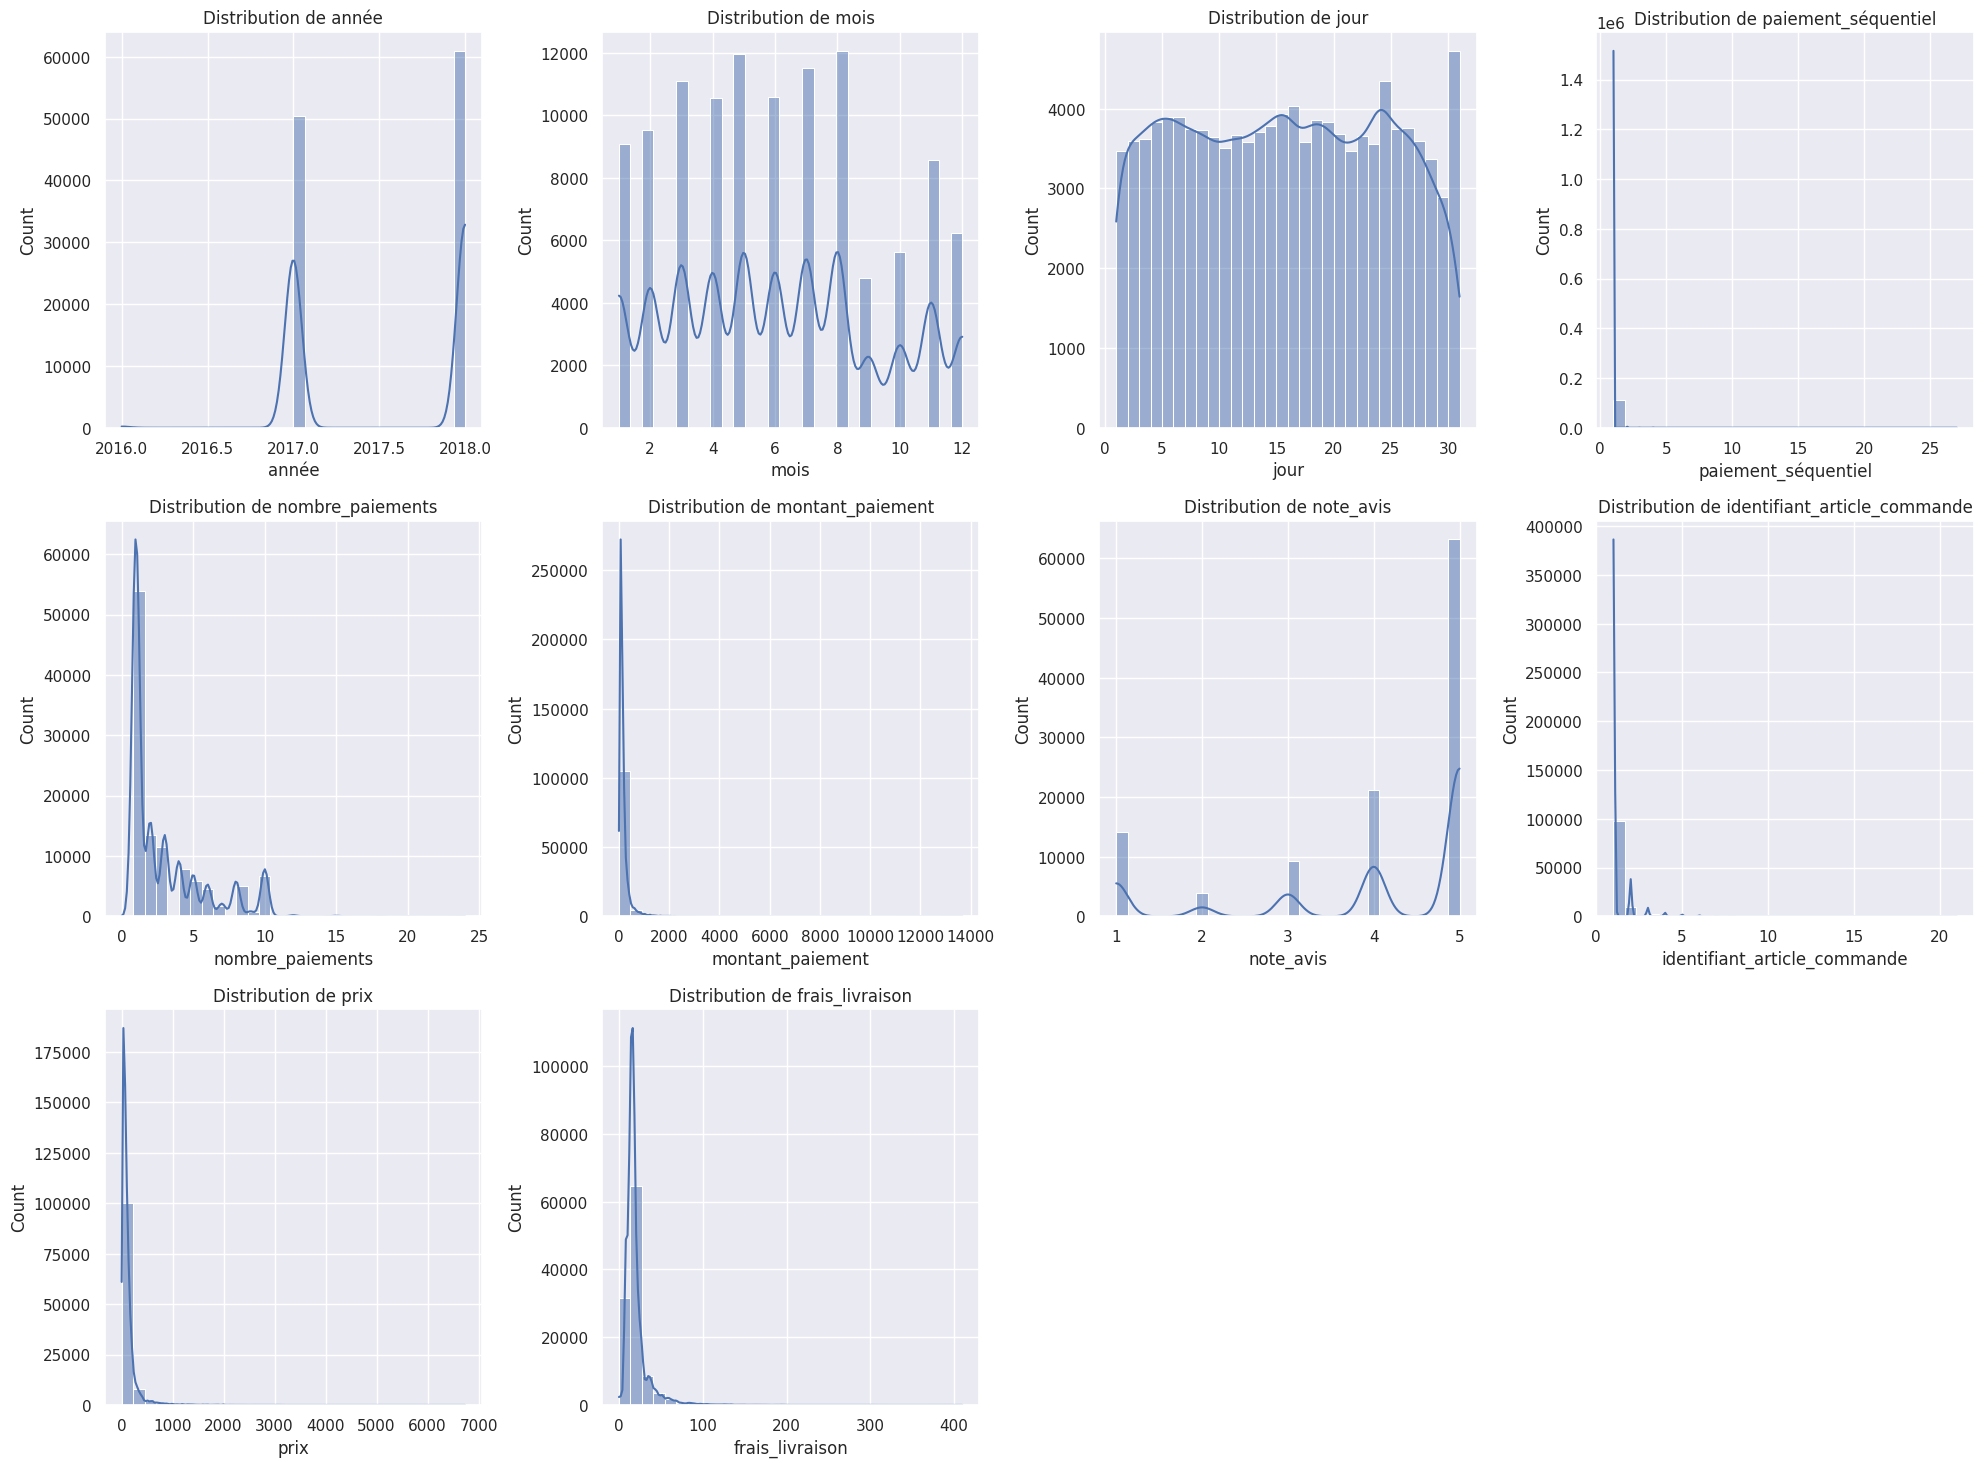

In [146]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# Sélection des colonnes numériques
numeric_columns = df.select_dtypes(['int32', 'float64', 'int64']).columns

# Paramètres pour l'affichage
n_cols = 4
n_rows = (len(numeric_columns) + n_cols - 1) // n_cols  # Arrondi vers le haut

fig, axes = plt.subplots(n_rows, n_cols, figsize=(20, 5 * n_rows))
axes = axes.flatten()  # Pour un accès plus simple

for i, column in enumerate(numeric_columns):
    sns.histplot(df[column].dropna(), bins=30, ax=axes[i], kde=True)
    axes[i].set_title('Distribution de ' + column)

# Supprimer les axes inutilisés
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()


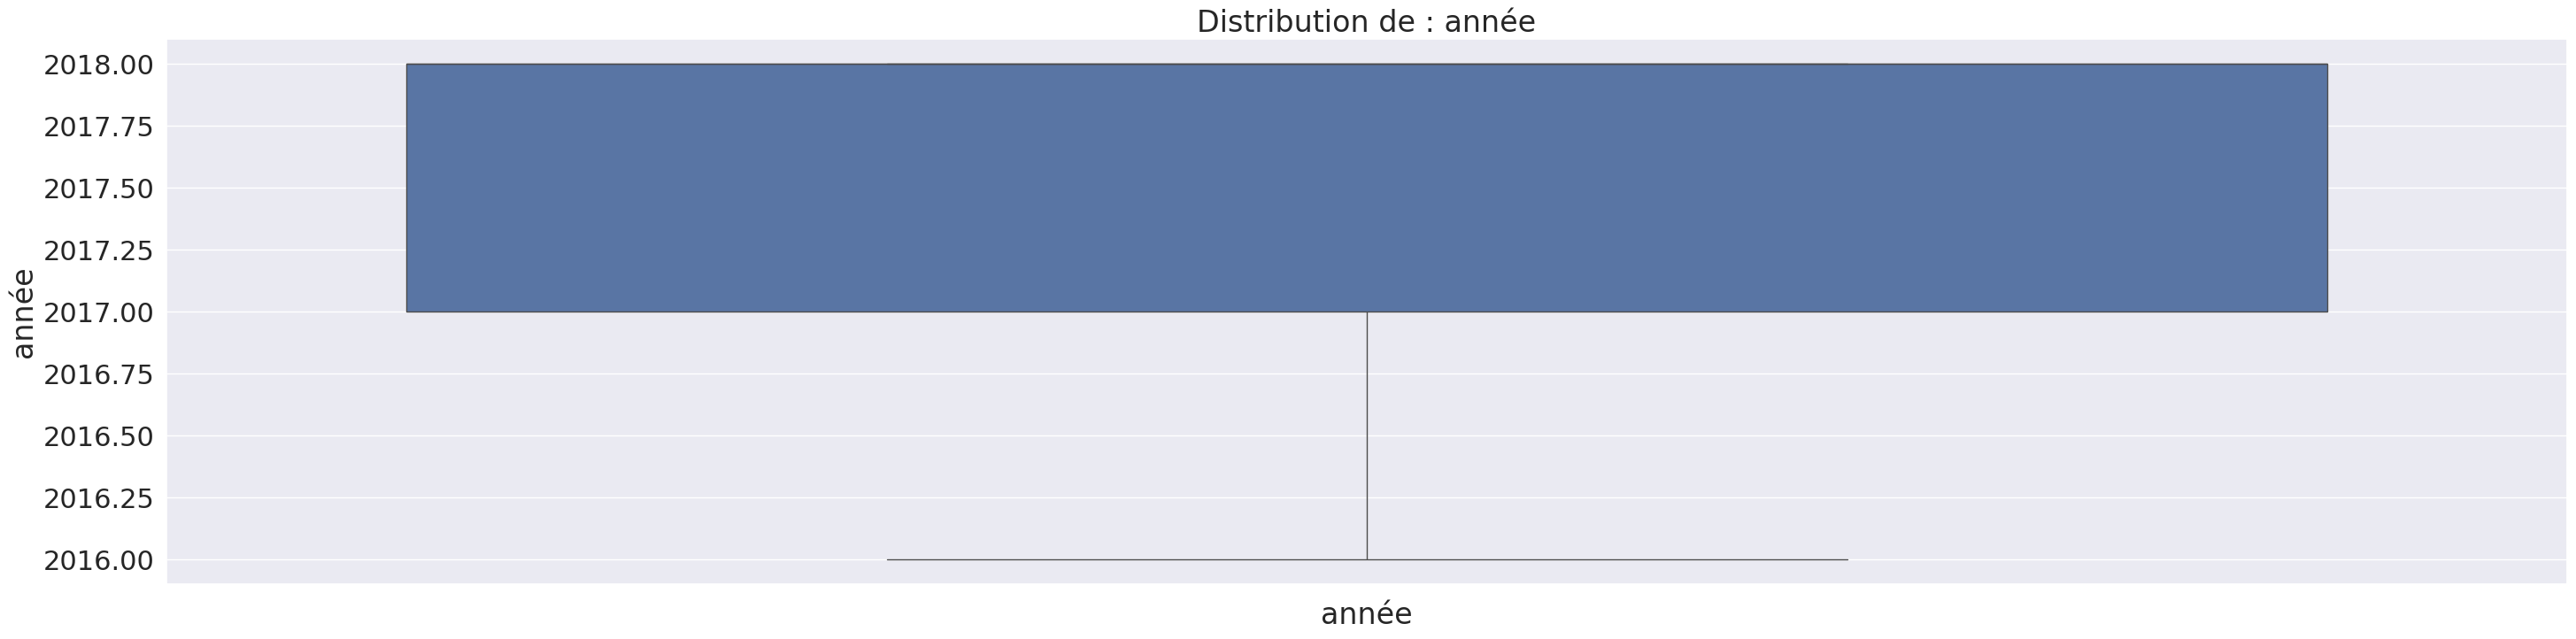

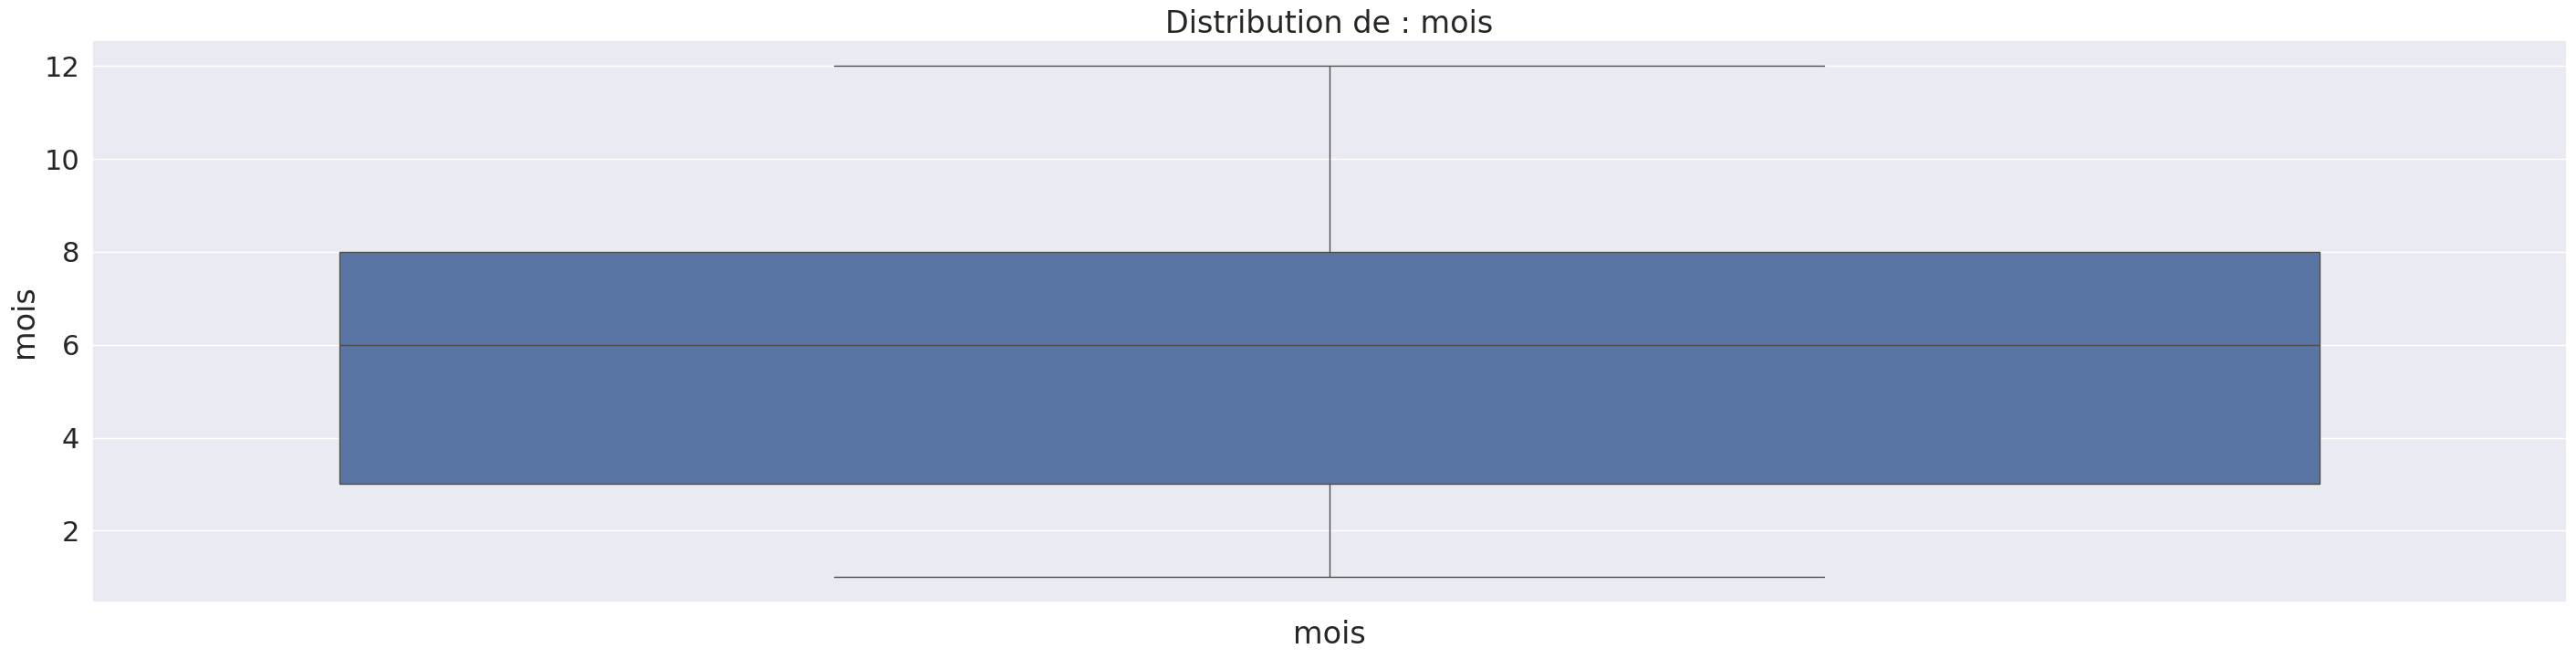

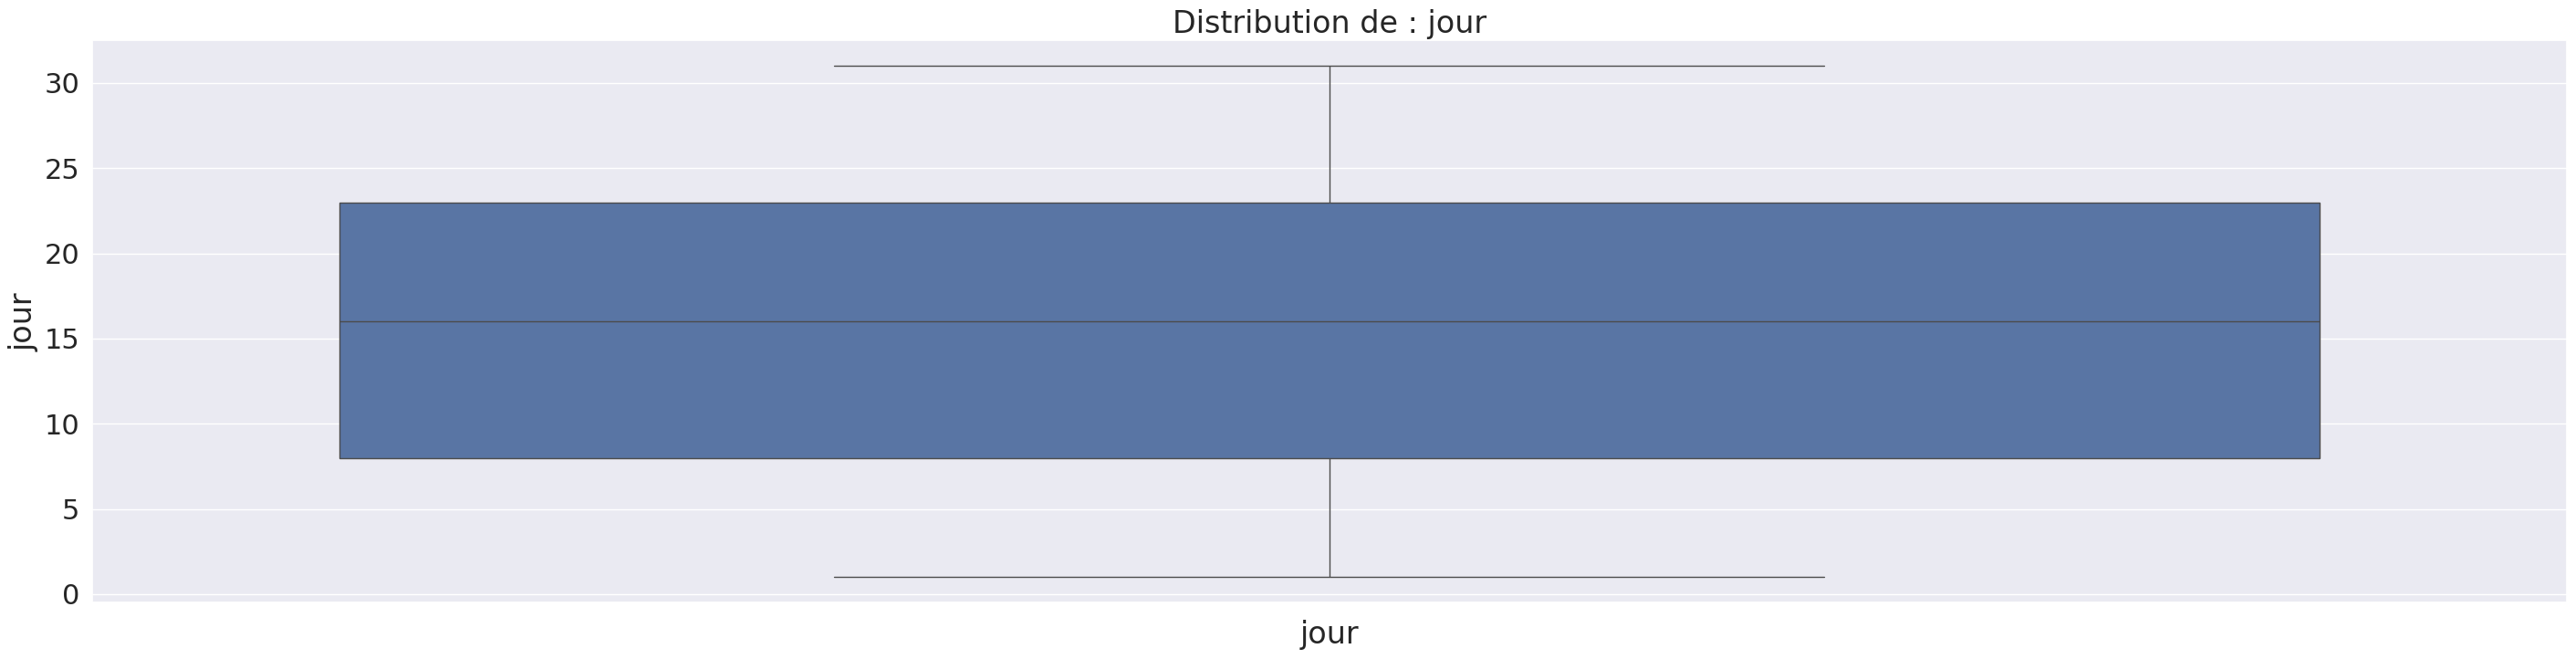

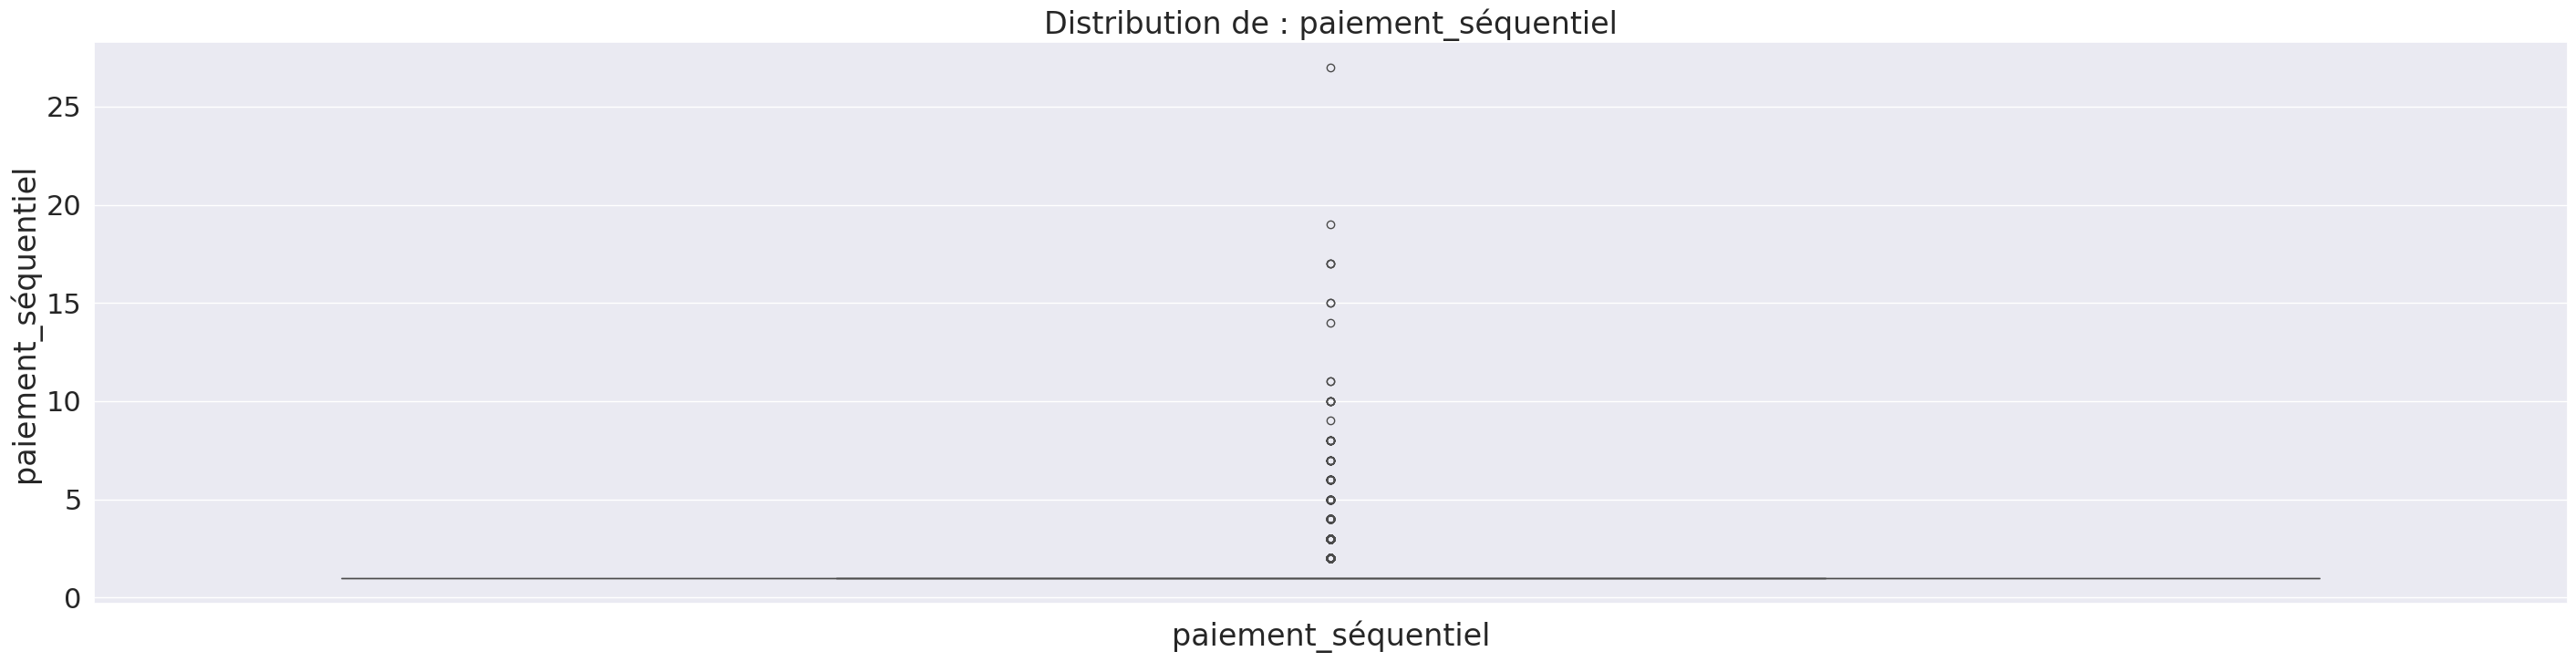

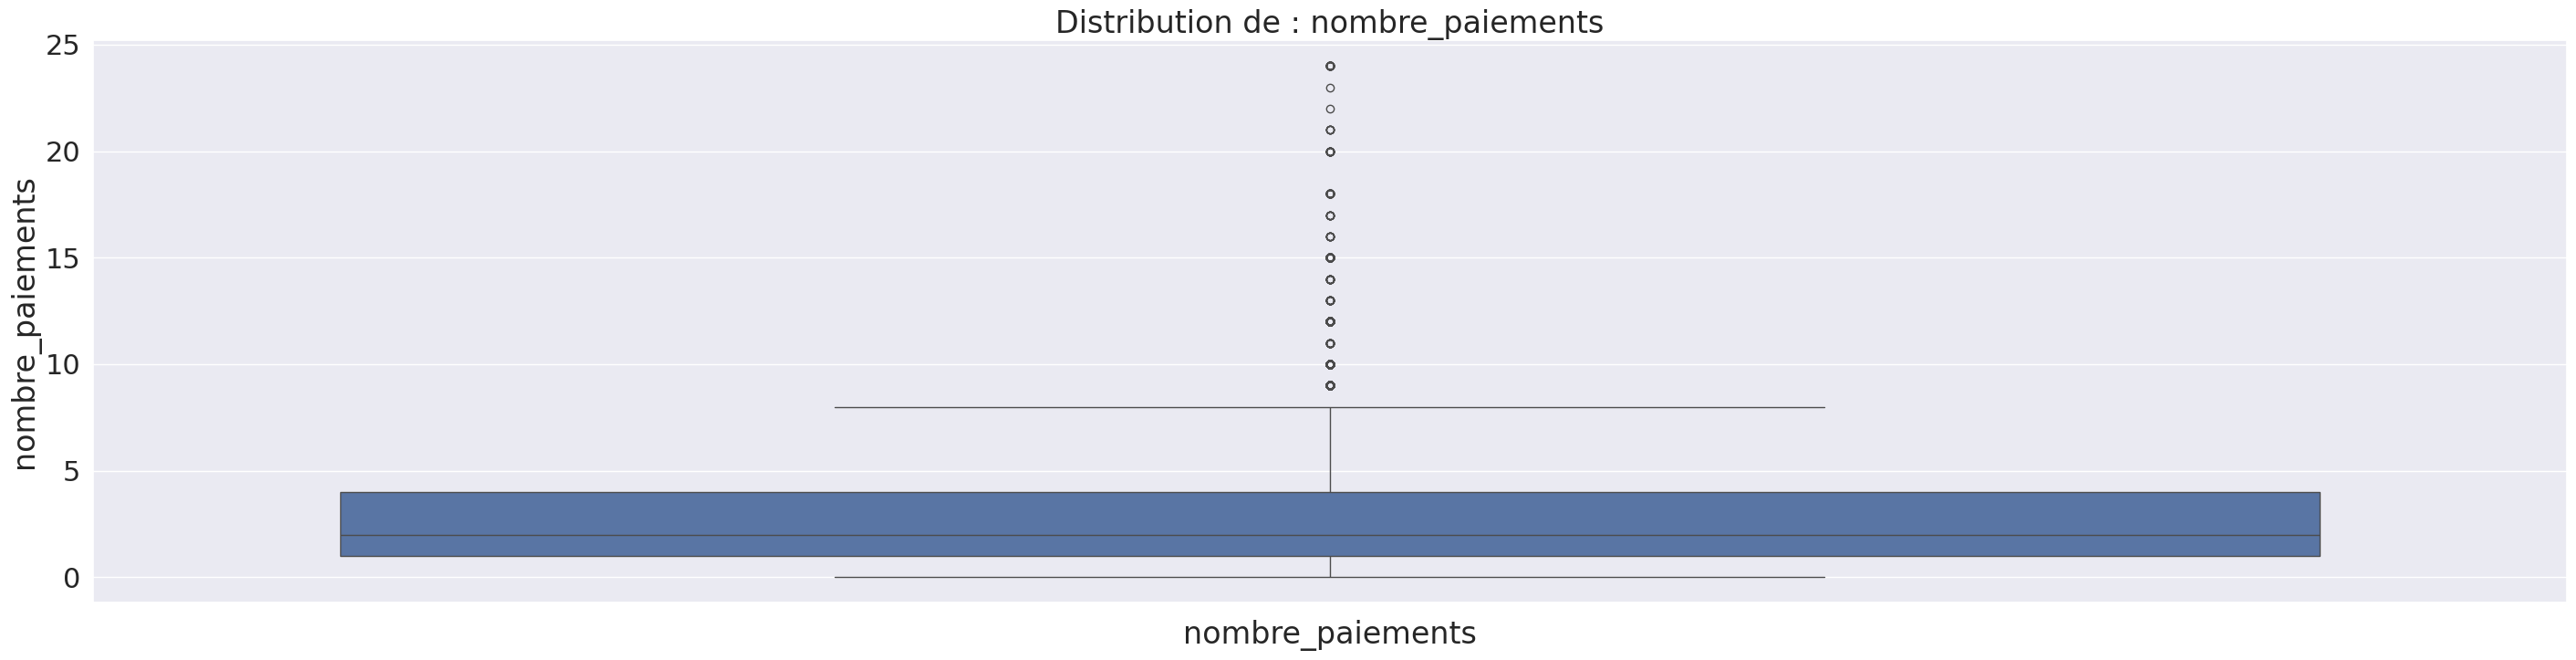

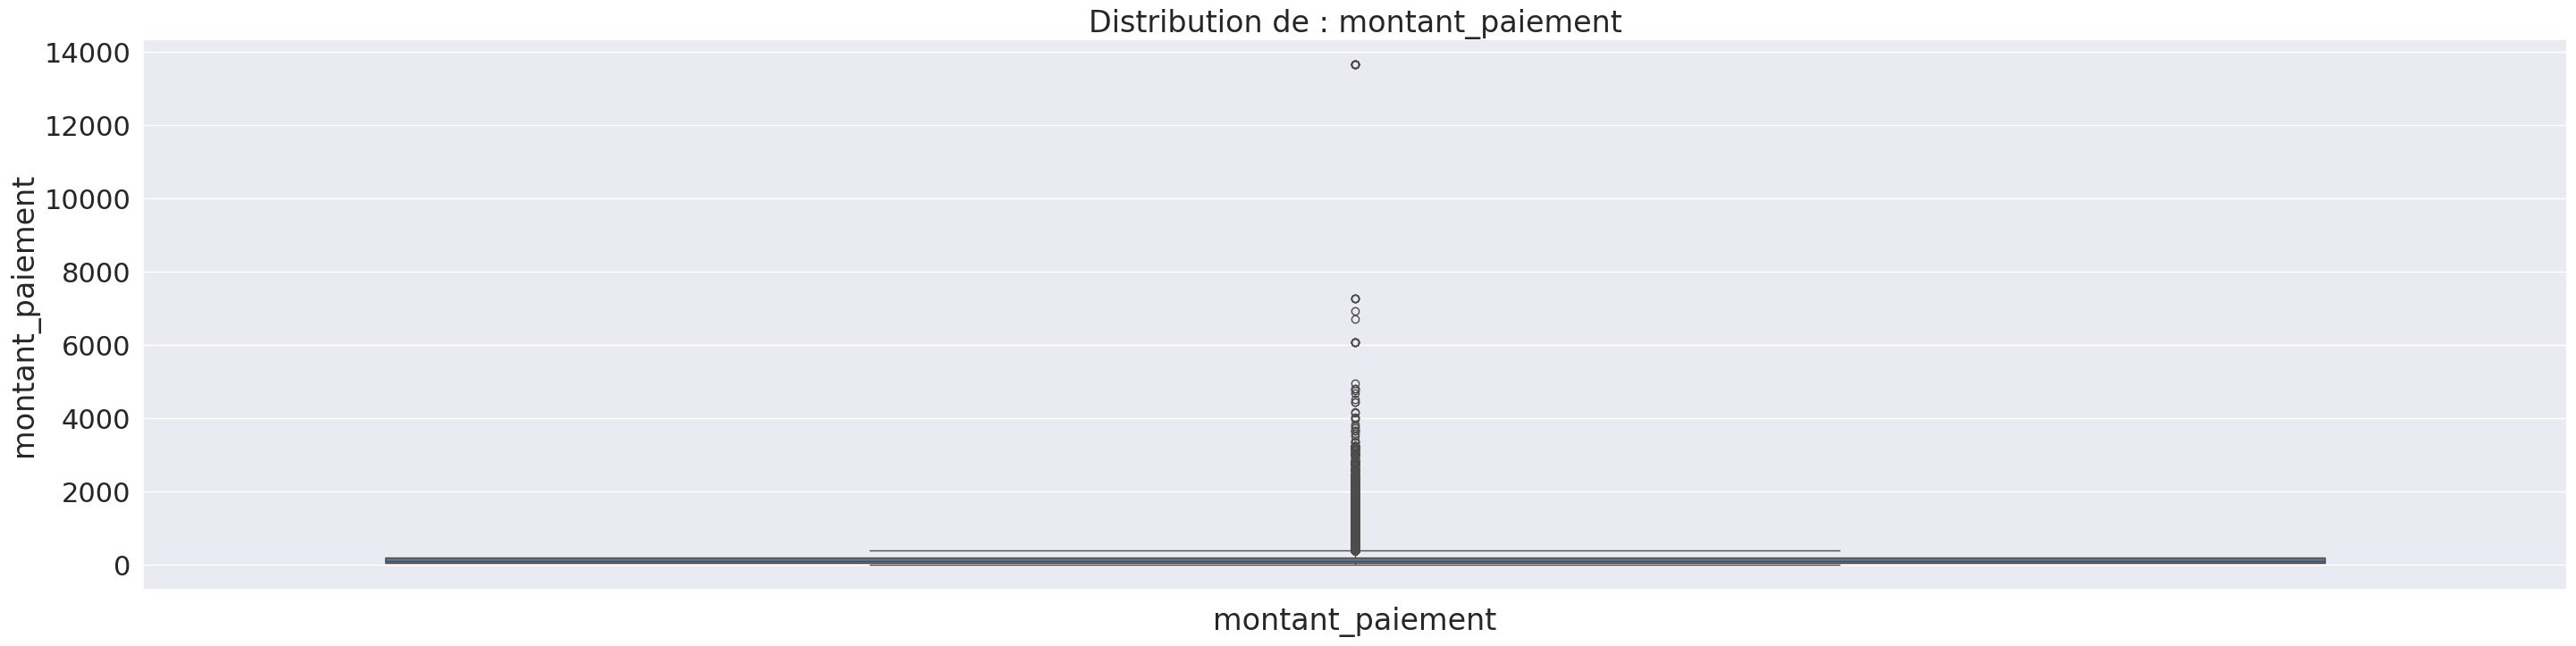

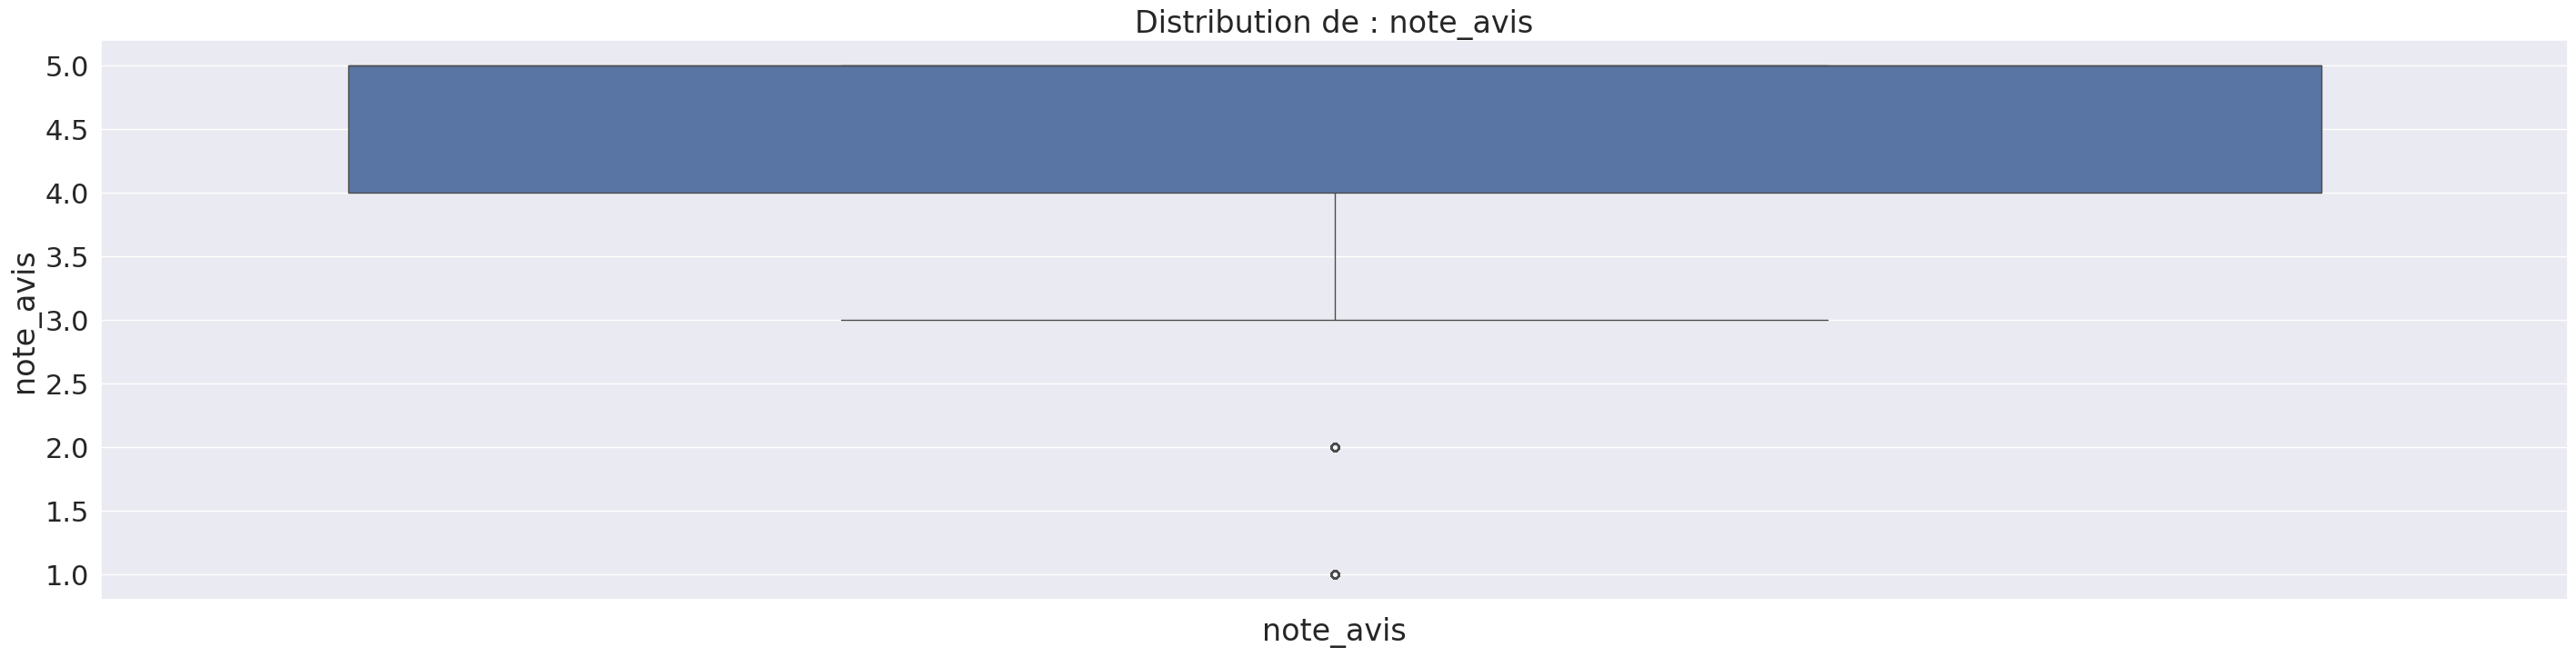

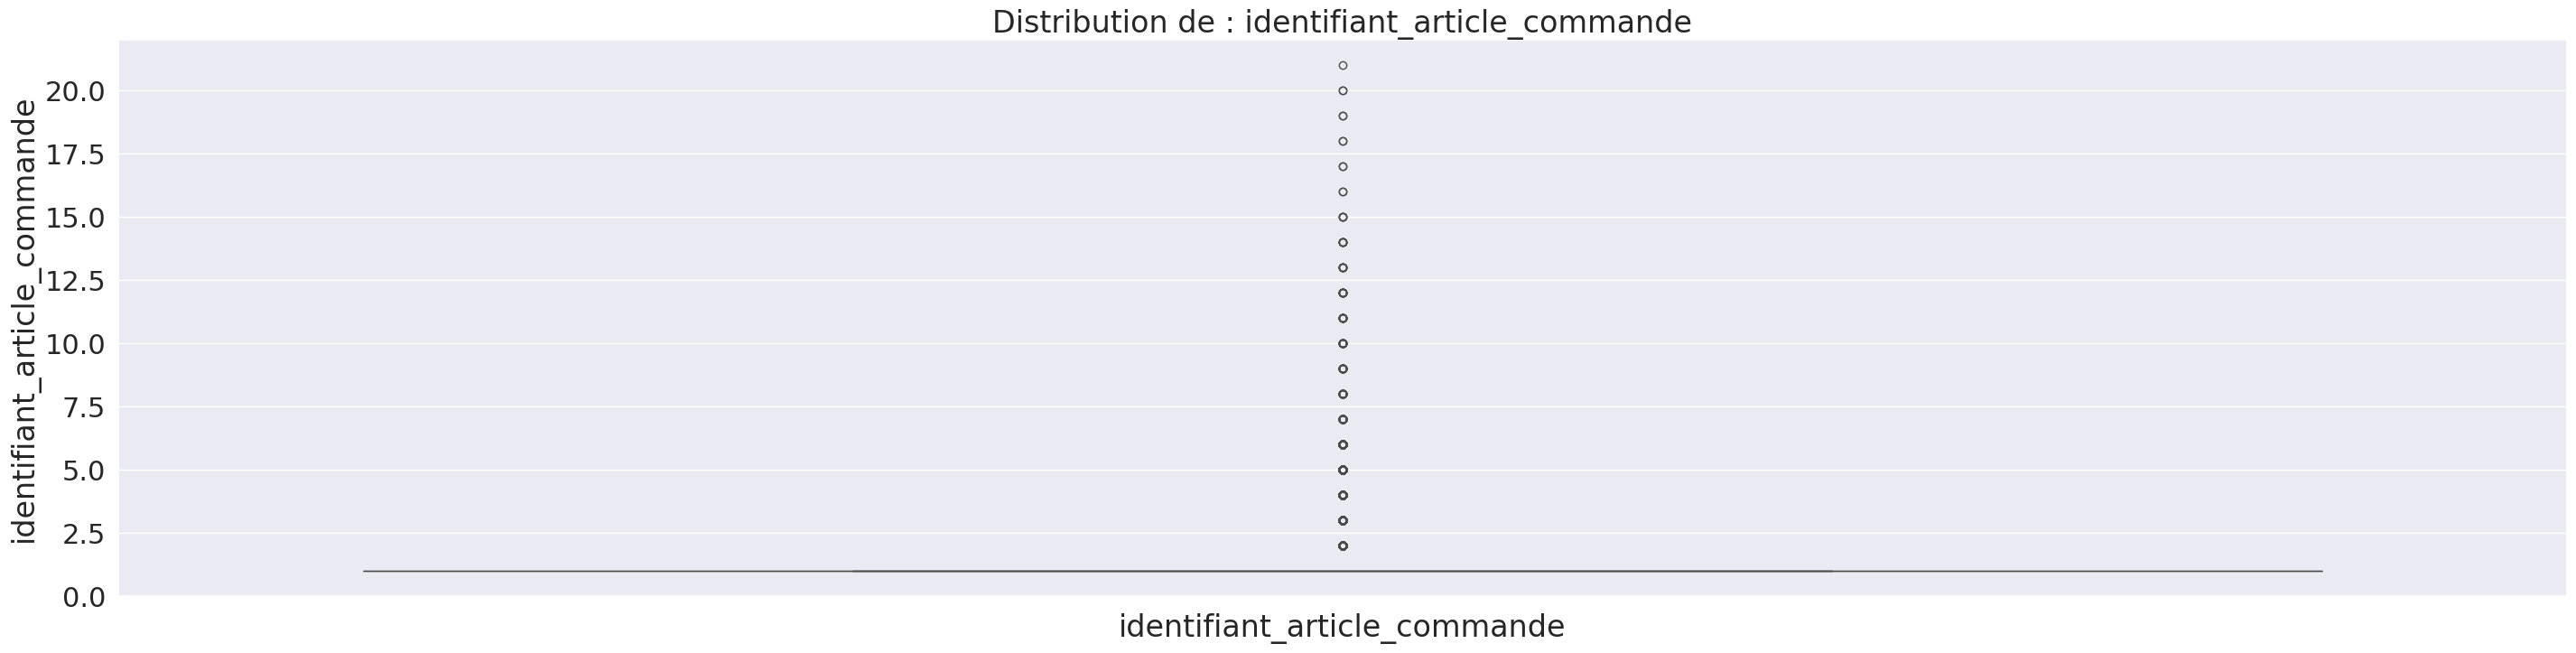

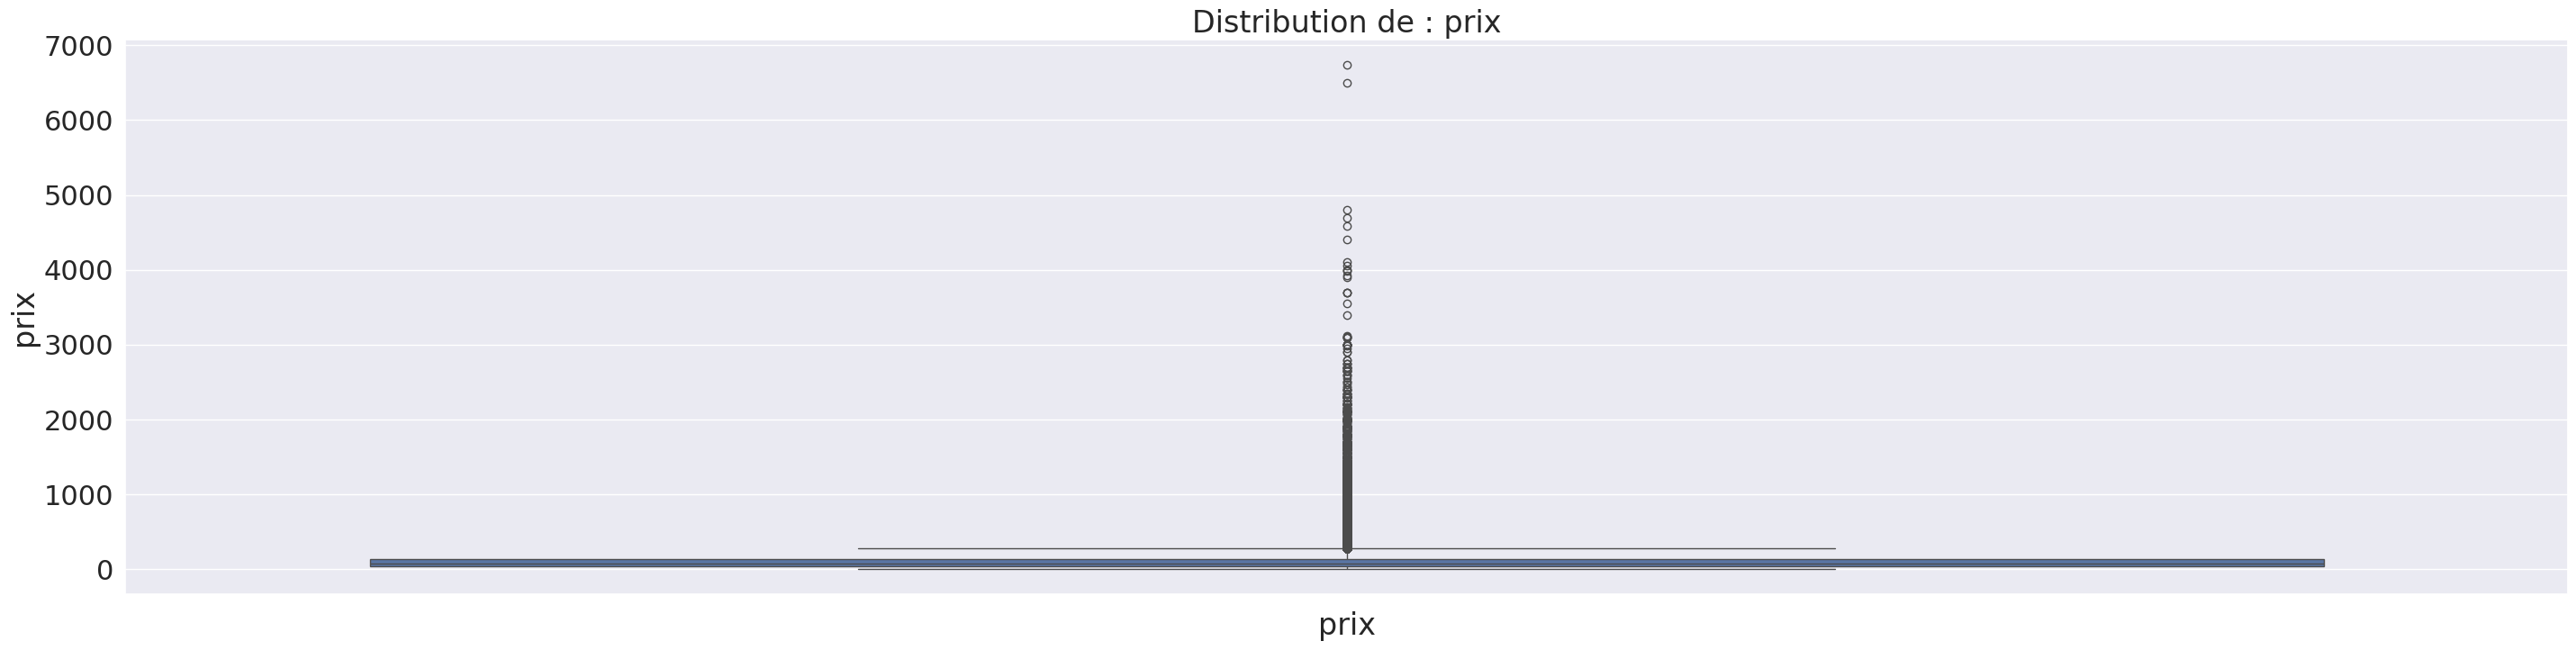

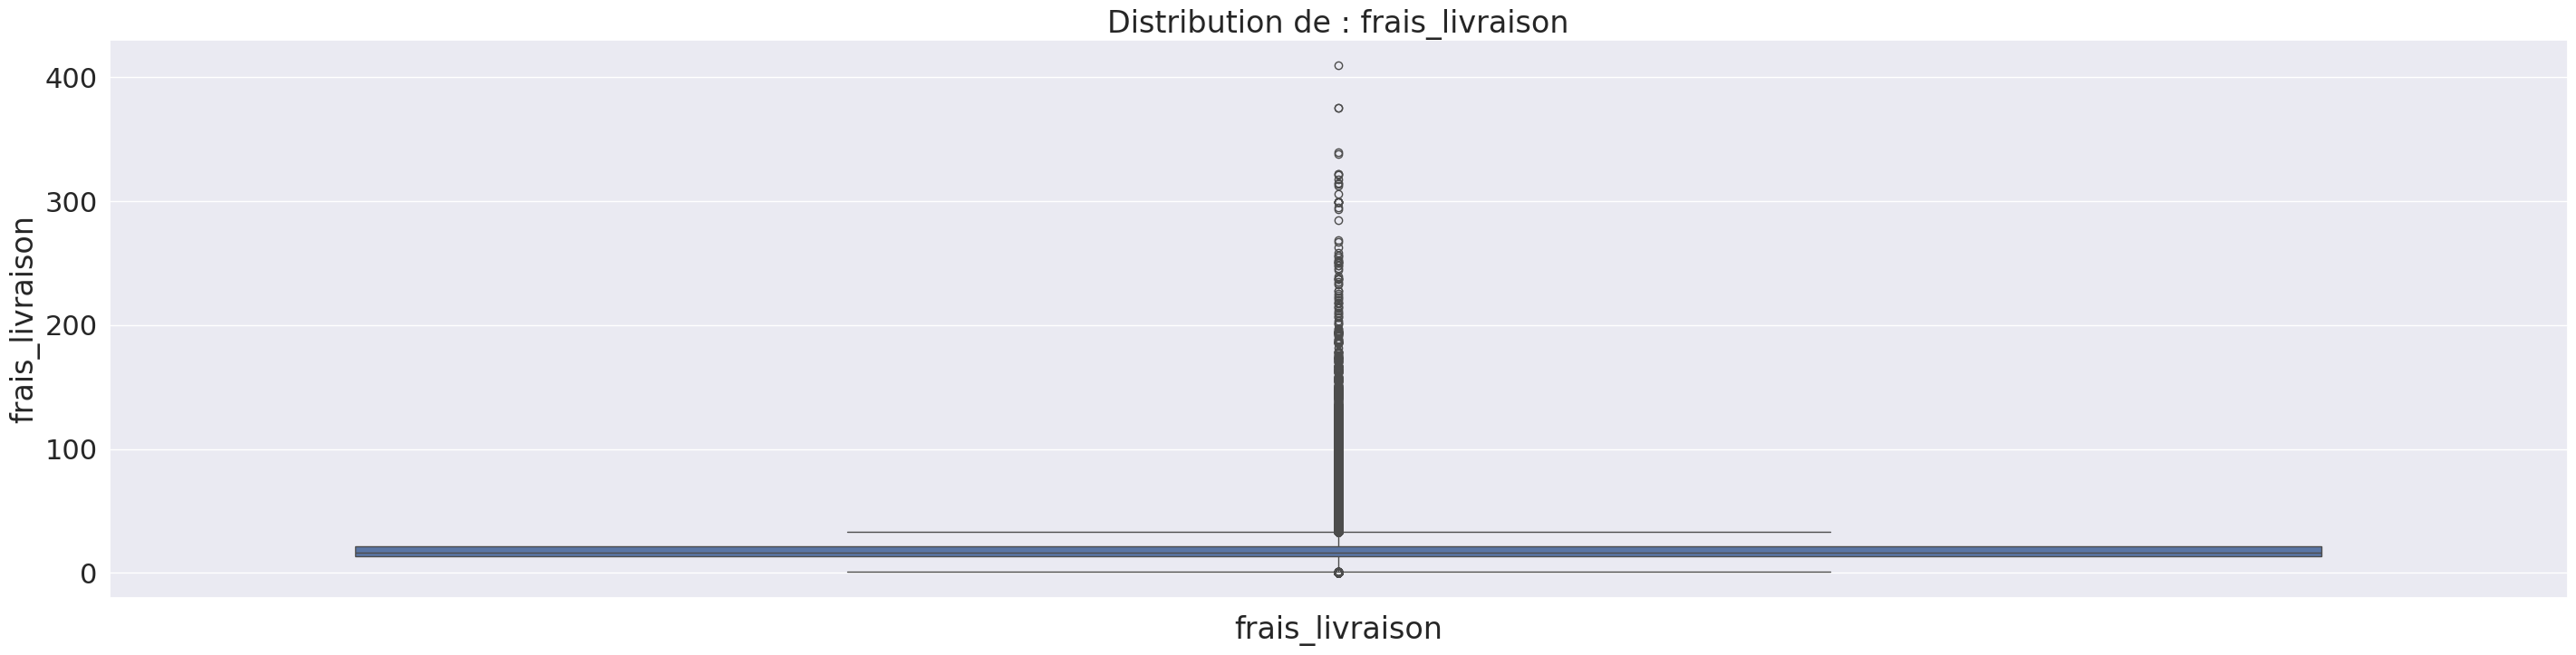

In [ ]:
numeric_columns = df.select_dtypes(include = ['int32','float64']).columns
sns.set(font_scale=2)
for column in numeric_columns:
    plt.figure(figsize = (35,8))

    sns.boxplot(df[column])
    chaine = 'Distribution de : ' + column
    plt.title(chaine)
    plt.xlabel(column)
    plt.show()
sns.set(font_scale=1)

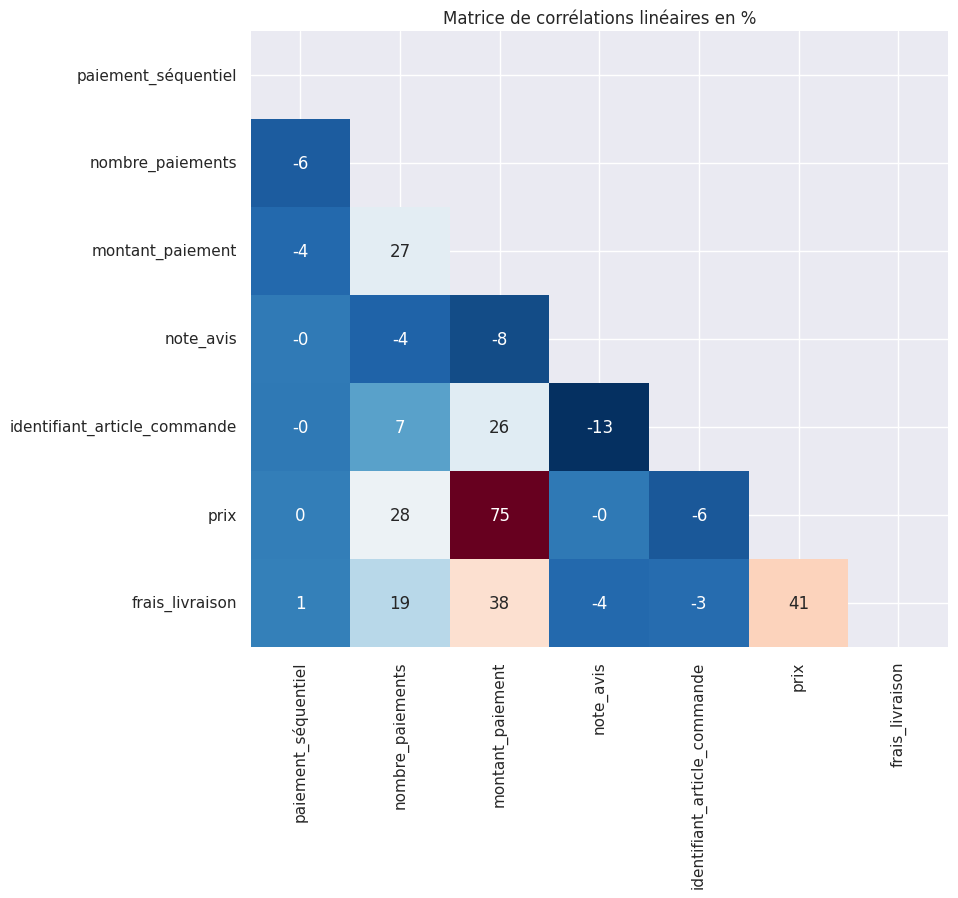

In [ ]:
pearson_correlations = df.select_dtypes(include='float64').corr() * 100
cleanning_mask = np.zeros_like(pearson_correlations)
upper_triangle = np.triu_indices_from(pearson_correlations)
cleanning_mask[upper_triangle] = 1

plt.figure(figsize=(9,8))

sns.heatmap(pearson_correlations, cmap="RdBu_r", mask = cleanning_mask,
           annot = True, fmt=".0f", cbar=False)
plt.title("Matrice de corrélations linéaires en %")
plt.show()

In [ ]:
df.columns

Index(['identifiant_client', 'identifiant_unique_client', 'code_postal_client',
       'ville_client', 'état_client', 'identifiant_commande',
       'statut_commande', 'horodatage_achat_commande', 'date_commande',
       'heure_commande', 'année', 'mois', 'mois_année', 'jour',
       'paiement_séquentiel', 'type_paiement', 'nombre_paiements',
       'montant_paiement', 'identifiant_avis', 'note_avis',
       'identifiant_article_commande', 'identifiant_produit',
       'identifiant_vendeur', 'prix', 'frais_livraison', 'code_postal_vendeur',
       'ville_vendeur', 'état_vendeur', 'categorie_produit'],
      dtype='object')

###Distribution des variables catégorielles

In [ ]:
def visualisation(variable,df):

    the_mean=df["montant_paiement"].mean()
    fig=plt.figure(figsize=[18,7])
    fig.patch.set_facecolor('#E0E0E0')
    fig.patch.set_alpha(0.7)
    plt.title("Payment by {}".format(variable),size=16)
    sns.boxplot(x=variable, y="montant_paiement", data=df,color="#cbd1db",width=0.5,showfliers=False,showmeans=True)
    plt.hlines(y=the_mean,xmin=-0.5,xmax=len(df[variable].unique())-0.5,color="#6d788b",ls="--",label="Global mean")

    plt.ylabel("montant_paiement",size=14)
    plt.xticks(range(0,len(df[variable].unique()))
               ,df[variable].unique(),rotation=90)
    plt.legend()
    plt.grid()
    plt.show()

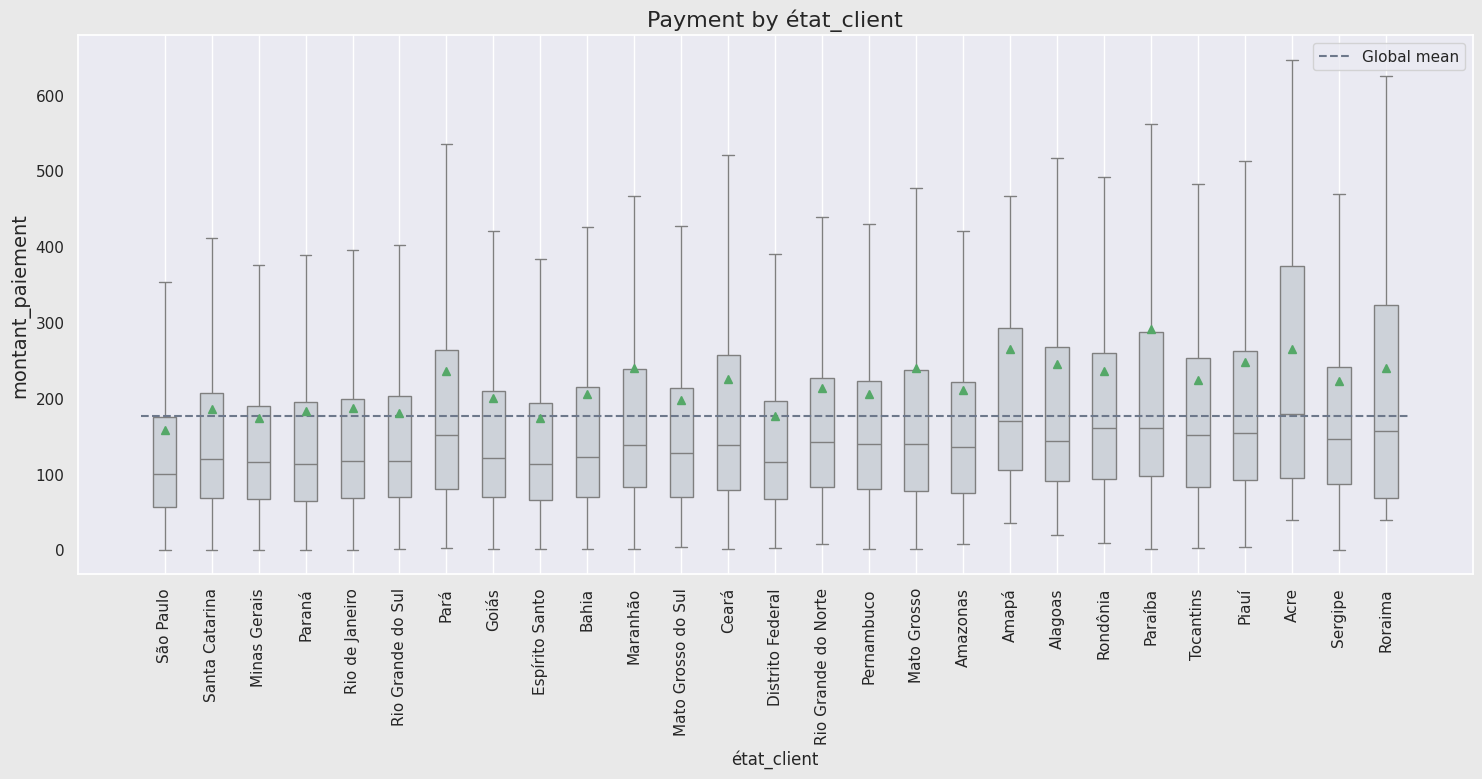

In [ ]:
visualisation('état_client',df)

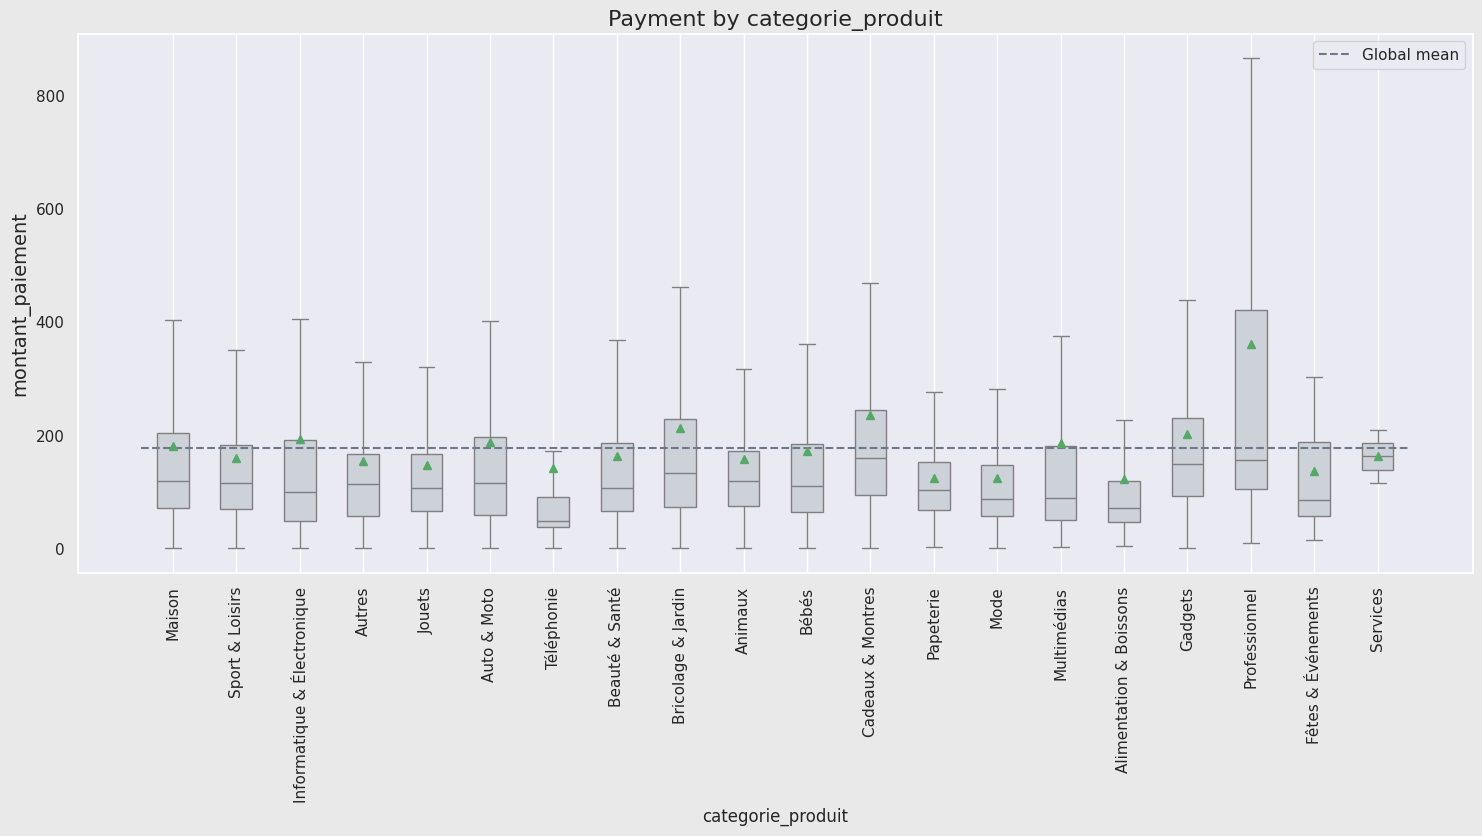

In [ ]:
visualisation('categorie_produit',df)

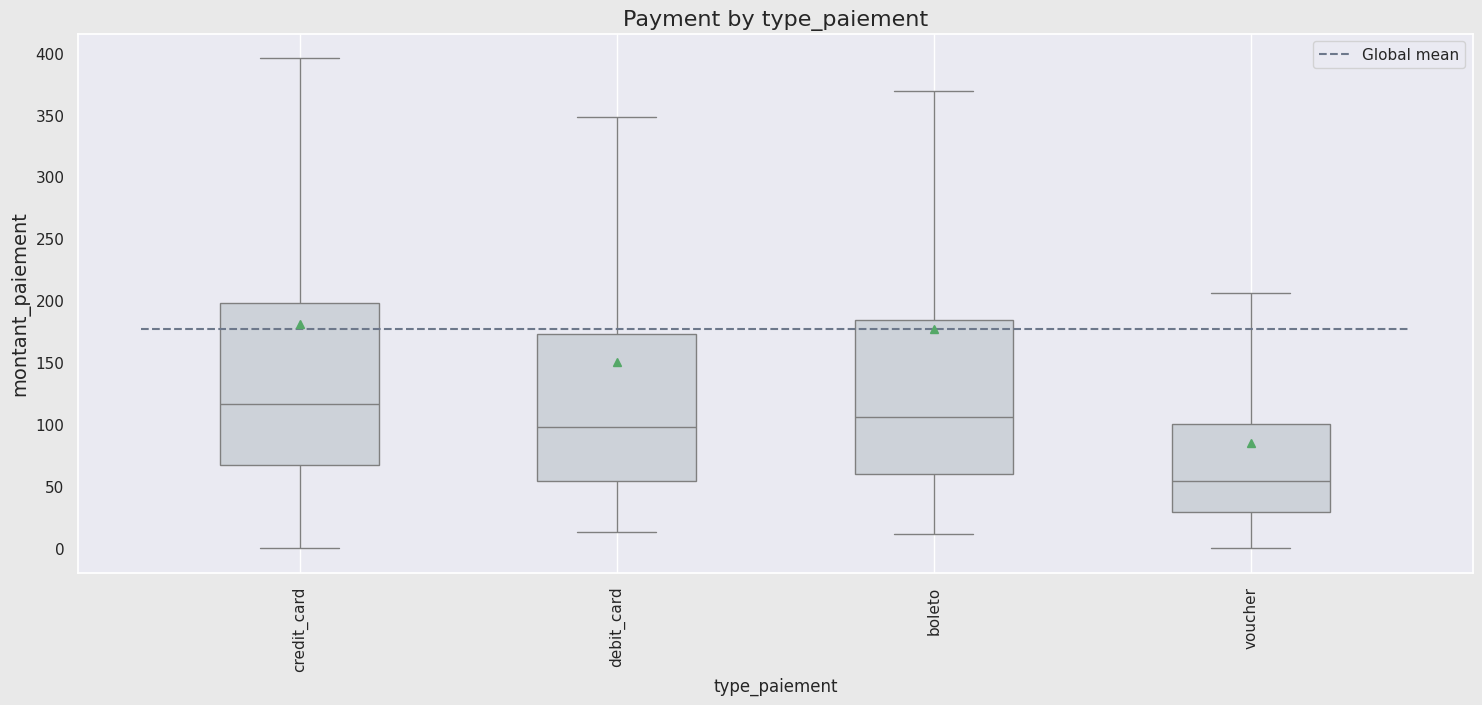

In [ ]:
visualisation('type_paiement', df)

In [ ]:
spv=df.groupby(['état_client','categorie_produit'])["montant_paiement"].sum()
output_path = "/content/drive/MyDrive/Colab Notebooks/P5_V2_andrea_nebot/spv_grouped.csv"
spv.to_csv(output_path)
spv

état_client  categorie_produit 
Acre         Auto & Moto            617.90
             Autres                 215.61
             Beauté & Santé        2448.18
             Bricolage & Jardin     707.20
             Bébés                  871.97
                                    ...   
Tocantins    Multimédias            994.39
             Papeterie              350.60
             Professionnel          128.63
             Sport & Loisirs       6788.71
             Téléphonie            3460.09
Name: montant_paiement, Length: 483, dtype: float64

In [ ]:
#!pip install --upgrade plotly


In [ ]:
#!pip install -U plotly


In [ ]:
!pip install plotly==5.15.0 --force-reinstall


  Using cached plotly-5.15.0-py2.py3-none-any.whl.metadata (7.0 kB)
  Using cached tenacity-9.1.2-py3-none-any.whl.metadata (1.2 kB)
  Using cached packaging-25.0-py3-none-any.whl.metadata (3.3 kB)
Using cached plotly-5.15.0-py2.py3-none-any.whl (15.5 MB)
Using cached tenacity-9.1.2-py3-none-any.whl (28 kB)
Using cached packaging-25.0-py3-none-any.whl (66 kB)
  Attempting uninstall: tenacity
    Found existing installation: tenacity 9.1.2
    Uninstalling tenacity-9.1.2:
      Successfully uninstalled tenacity-9.1.2
  Attempting uninstall: packaging
    Found existing installation: packaging 25.0
    Uninstalling packaging-25.0:
      Successfully uninstalled packaging-25.0
  Attempting uninstall: plotly
    Found existing installation: plotly 5.15.0
    Uninstalling plotly-5.15.0:
      Successfully uninstalled plotly-5.15.0
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependenc

In [ ]:
# Imports
import pandas as pd
import json
from shapely.geometry import shape
import plotly.graph_objects as go
import plotly.express as px
import ipywidgets as widgets
from IPython.display import display

# Chargement des données (adapte les chemins si besoin)
spv = pd.read_csv("/content/drive/MyDrive/Colab Notebooks/P5_V2_andrea_nebot/spv_grouped.csv")
with open("/content/drive/MyDrive/Colab Notebooks/P5_V2_andrea_nebot/brazil-states.geojson.txt", "r") as f:
    br_geojson = json.load(f)

# 1) Calcul des centres géographiques des états pour afficher les noms
state_centers = {}
for feature in br_geojson['features']:
    geom = shape(feature['geometry'])
    center = geom.centroid
    state_centers[feature['properties']['name']] = (center.y, center.x)  # lat, lon

centers_df = pd.DataFrame.from_dict(state_centers, orient='index', columns=['lat', 'lon'])
centers_df.index.name = 'état_client'
centers_df.reset_index(inplace=True)

# 2) Fusion des centres géographiques avec le dataframe principal
spv_merged = spv.merge(centers_df, on='état_client', how='left')

# 3) Fonction pour afficher la carte avec filtres
def plot_map(selected_states, selected_categories):
    dff = spv_merged[
        (spv_merged['état_client'].isin(selected_states)) &
        (spv_merged['categorie_produit'].isin(selected_categories))
    ]

    # Carte choropleth
    fig = px.choropleth(
        dff,
        geojson=br_geojson,
        locations='état_client',
        featureidkey='properties.name',
        color='montant_paiement',
        color_continuous_scale='YlGnBu',
        scope='south america',
        labels={'montant_paiement': 'Montant (R$)'},
        title="Montants des achats par État et catégorie"
    )

    # Ajouter les noms des états (centrés)
    scatter = go.Scattergeo(
        lat=dff.groupby('état_client')['lat'].first(),
        lon=dff.groupby('état_client')['lon'].first(),
        text=dff.groupby('état_client')['état_client'].first(),
        mode='text',
        textfont=dict(color='black', size=10),
        showlegend=False
    )
    fig.add_trace(scatter)

    fig.update_geos(fitbounds="locations", visible=False)
    fig.update_layout(margin={"r":0,"t":40,"l":0,"b":0})
    fig.show()

# 4) Création des widgets de filtrage
state_options = sorted(spv_merged['état_client'].dropna().unique())
category_options = sorted(spv_merged['categorie_produit'].dropna().unique())

state_selector = widgets.SelectMultiple(
    options=state_options,
    value=state_options,
    description='États',
    disabled=False,
    layout=widgets.Layout(width='40%')
)

category_selector = widgets.SelectMultiple(
    options=category_options,
    value=category_options,
    description='Catégories',
    disabled=False,
    layout=widgets.Layout(width='40%')
)

ui = widgets.HBox([state_selector, category_selector])

out = widgets.interactive_output(
    plot_map,
    {'selected_states': state_selector, 'selected_categories': category_selector}
)

display(ui, out)


Output()

In [ ]:
df.head()

,identifiant_client,identifiant_unique_client,code_postal_client,ville_client,état_client,identifiant_commande,statut_commande,horodatage_achat_commande,date_commande,heure_commande,année,mois,mois_année,jour,paiement_séquentiel,type_paiement,nombre_paiements,montant_paiement,identifiant_avis,note_avis,identifiant_article_commande,identifiant_produit,identifiant_vendeur,prix,frais_livraison,code_postal_vendeur,ville_vendeur,état_vendeur,categorie_produit
0,06b8999e2fba1a1fbc88172c00ba8bc7,861eff4711a542e4b93843c6dd7febb0,14409,franca,São Paulo,00e7ee1b050b8499577073aeb2a297a1,delivered,2017-05-16 15:05:35,2017-05-16,15:05:35,2017,5,05-2017,16,1.0,credit_card,2.0,146.87,88b8b52d46df026a9d1ad2136a59b30b,4.0,1.0,a9516a079e37a9c9c36b9b78b10169e8,7c67e1448b00f6e969d365cea6b010ab,124.99,21.88,8577,itaquaquecetuba,SP,Maison
1,18955e83d337fd6b2def6b18a428ac77,290c77bc529b7ac935b93aa66c333dc3,9790,sao bernardo do campo,São Paulo,29150127e6685892b6eab3eec79f59c7,delivered,2018-01-12 20:48:24,2018-01-12,20:48:24,2018,1,01-2018,12,1.0,credit_card,8.0,335.48,02fc48a9efa3e3d0f1a8ea26507eeec3,5.0,1.0,4aa6014eceb682077f9dc4bffebc05b0,b8bc237ba3788b23da09c0f1f3a3288c,289.00,46.48,88303,itajai,SC,Maison
2,4e7b3e00288586ebd08712fdd0374a03,060e732b5b29e8181a18229c7b0b2b5e,1151,sao paulo,São Paulo,b2059ed67ce144a36e2aa97d2c9e9ad2,delivered,2018-05-19 16:07:45,2018-05-19,16:07:45,2018,5,05-2018,19,1.0,credit_card,7.0,157.73,5ad6695d76ee186dc473c42706984d87,5.0,1.0,bd07b66896d6f1494f5b86251848ced7,7c67e1448b00f6e969d365cea6b010ab,139.94,17.79,8577,itaquaquecetuba,SP,Maison
3,b2b6027bc5c5109e529d4dc6358b12c3,259dac757896d24d7702b9acbbff3f3c,8775,mogi das cruzes,São Paulo,951670f92359f4fe4a63112aa7306eba,delivered,2018-03-13 16:06:38,2018-03-13,16:06:38,2018,3,03-2018,13,1.0,credit_card,1.0,173.30,059a801bb31f6aab2266e672cab87bc5,5.0,1.0,a5647c44af977b148e0a3a4751a09e2e,7c67e1448b00f6e969d365cea6b010ab,149.94,23.36,8577,itaquaquecetuba,SP,Maison
4,4f2d8ab171c80ec8364f7c12e35b23ad,345ecd01c38d18a9036ed96c73b8d066,13056,campinas,São Paulo,6b7d50bd145f6fc7f33cebabd7e49d0f,delivered,2018-07-29 09:51:30,2018-07-29,09:51:30,2018,7,07-2018,29,1.0,credit_card,8.0,252.25,8490879d58d6c5d7773f2739a03f089a,5.0,1.0,9391a573abe00141c56e38d84d7d5b3b,4a3ca9315b744ce9f8e9374361493884,230.00,22.25,14940,ibitinga,SP,Maison


In [ ]:
df.select_dtypes(['object']).nunique()

,0
identifiant_client,97916
identifiant_unique_client,94720
code_postal_client,14955
ville_client,4108
état_client,27
identifiant_commande,97916
statut_commande,7
horodatage_achat_commande,97370
date_commande,615
heure_commande,50469


In [ ]:
grouped_df = df.groupby('identifiant_unique_client')['montant_paiement'].sum()
grouped_df.head()

,montant_paiement
identifiant_unique_client,
0000366f3b9a7992bf8c76cfdf3221e2,141.90
0000b849f77a49e4a4ce2b2a4ca5be3f,27.19
0000f46a3911fa3c0805444483337064,86.22
0000f6ccb0745a6a4b88665a16c9f078,43.62
0004aac84e0df4da2b147fca70cf8255,196.89
